# Notebook Overview: Visual Polarization in Political News Imagery

This notebook presents the complete empirical pipeline for **measuring and validating visual political polarization in news media** across 20 major U.S. and international outlets. Using a trained **multimodal outlet-prediction model** applied to politician images, we construct image-based measures of visual slant and polarization and study how news organizations systematically differ in the visual framing of Republican and Democratic politicians.

The analysis proceeds in **seven stages**, implemented across **15 code cells**:

1. **Visual Slant Distributions (Figure 9)**  
   We compare kernel density distributions of visual slant for Republican and Democratic politicians across partisan outlets. These distributions show how politicians from each party are visually portrayed in ideologically aligned versus opposing media.

2. **Radar Plots of Smile Effects (Figure A.7)**  
   We visualize the average smile-induced shift in outlet prediction probabilities across all 20 outlets, separately for Republican and Democratic politicians. The radar plots highlight outlet-level asymmetries in how added smiles alter visual framing by party.

3. **Conservative Visual Slant (CVS) (Figures 10–11)**  
   We define **Conservative Visual Slant (CVS)** as the difference in average visual slant toward Republican versus Democratic politicians at the outlet level. Bar charts rank outlets from most liberal to most conservative visual framing, while side-by-side panels decompose the effect by party.

4. **External Validation of CVS (Figures 11, A.7–A.9, 12)**  
   We validate outlet-level CVS against three independent benchmarks of media ideology: **Faris et al. (Harvard)**, **AllSides**, and **Flaxman et al.** The analysis reports Spearman and Pearson correlations and includes **permutation-based placebo tests** (1,000 iterations) that shuffle politician party labels to generate a null distribution. We additionally benchmark CVS against the visual slant estimates of **Boxell et al. (2021)**.

5. **Overall Visual Polarization (OVP) (Figures 15–16)**  
   We construct a politician-level measure of polarization using **cross-fitted predictions** from two independently trained outlet-prediction models. **OVP** is defined as the square root of the cross-model covariance in outlet likelihoods across counterfactual images and is then aggregated at the politician level.

6. **Validation Using Verbal Polarization (Figures 17–18)**  
   We validate OVP against speech-based ideology scores (**CFscores** from the DIME dataset, 2012–2022 cycles). This analysis tests whether politicians who are visually polarizing are also ideologically extreme in their verbal positioning.

7. **Time Trends and Supplementary Analyses (Figures 16, A.6, A.13–A.15, Table A.5)**  
   We examine annual trends in visual slant from 2011–2021, with and without Trump-era coverage, present per-outlet KDE distributions by party, show politician-level bar plots of outlet-specific slant, and conduct statistical tests (KS tests and t-tests) for distributional differences.

**Data inputs**:  
- `Final_CSV_For_Analysis.csv` (main analysis file)  
- `Final_CSV_For_Analysis_Model_1.csv` / `Final_CSV_For_Analysis_Model_2.csv` (cross-fitted predictions)  
- `dime_recipients_1979_2024.csv` (verbal ideology benchmarks)

**Key column conventions**:  
- `Final_Ratio_{outlet}`: outlet-level visual slant  
- `Top1_Person`: identified politician  
- `Real Person Side`: party affiliation  
- `Ratio_{k}_{outlet}`: counterfactual image ratios used to construct OVP  

## Figure 9. Visual Slant Distributions Across Partisan Outlets  

Figure 10 compares the distribution of visual slant for Republican and Democratic politicians across partisan outlets.  
The left panel shows how Republican politicians are represented in Democratic versus Republican outlets, while the right panel shows the reverse for Democratic politicians. Kernel density estimates illustrate systematic polarization: politicians tend to appear more visually favorable in aligned outlets, with means and interquartile ranges shifting across party lines.

/home/jupyter-hoc_project/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-hoc_project/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-hoc_project/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-hoc_project/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be

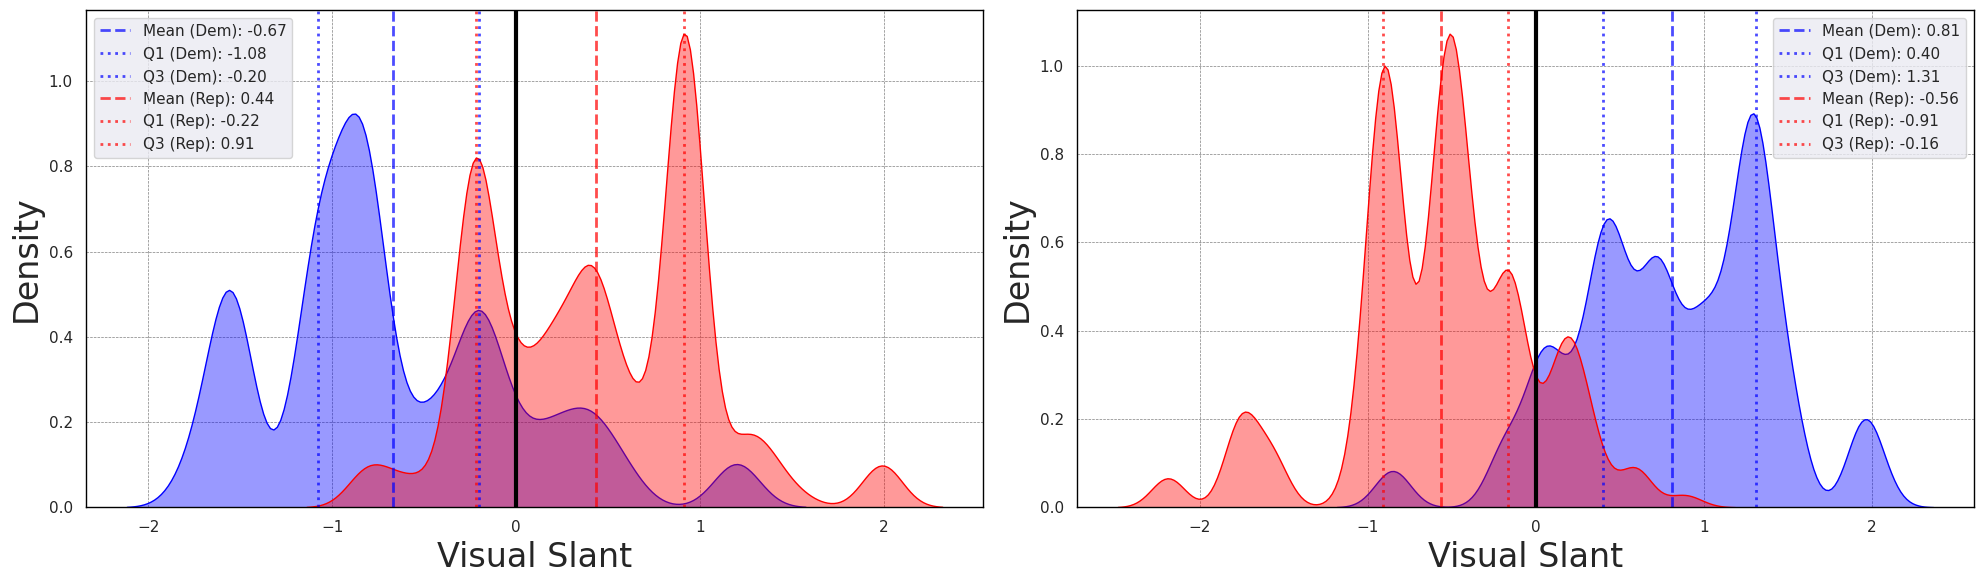

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('data/Final_CSV_For_Analysis.csv')

plt.style.use('default')
sns.set_style("white")

news_center_affiliations = {
    'www.nytimes.com': 'Democratic', 'www.washingtonpost.com': 'Democratic',
    'www.cnn.com': 'Democratic', 'www.dailymail.co.uk': 'Republican',
    'www.foxnews.com': 'Republican', 'www.newsmax.com': 'Republican'
}

selected_news_centers = [news for news, affiliation in news_center_affiliations.items() if affiliation in ['Democratic', 'Republican']]
df = df[df['News Center'].isin(selected_news_centers)]
binsss = 20

democratic_news_centers = [news for news, affiliation in news_center_affiliations.items() if affiliation == 'Democratic']
republican_news_centers = [news for news, affiliation in news_center_affiliations.items() if affiliation == 'Republican']

republican_politicians_in_democratic_outlets = pd.Series(dtype='float64')
republican_politicians_in_republican_outlets = pd.Series(dtype='float64')

for news_center in democratic_news_centers:
    column_name = f"Final_Ratio_{news_center}"
    if column_name in df.columns:
        republican_data = df[(df['Real Person Side'] == 'Republican')][column_name]
        republican_politicians_in_democratic_outlets = pd.concat([republican_politicians_in_democratic_outlets, republican_data])

for news_center in republican_news_centers:
    column_name = f"Final_Ratio_{news_center}"
    if column_name in df.columns:
        republican_data = df[(df['Real Person Side'] == 'Republican')][column_name]
        republican_politicians_in_republican_outlets = pd.concat([republican_politicians_in_republican_outlets, republican_data])

democratic_politicians_in_democratic_outlets = pd.Series(dtype='float64')
democratic_politicians_in_republican_outlets = pd.Series(dtype='float64')

for news_center in democratic_news_centers:
    column_name = f"Final_Ratio_{news_center}"
    if column_name in df.columns:
        democratic_data = df[(df['Real Person Side'] == 'Democratic')][column_name]
        democratic_politicians_in_democratic_outlets = pd.concat([democratic_politicians_in_democratic_outlets, democratic_data])

for news_center in republican_news_centers:
    column_name = f"Final_Ratio_{news_center}"
    if column_name in df.columns:
        democratic_data = df[(df['Real Person Side'] == 'Democratic')][column_name]
        democratic_politicians_in_republican_outlets = pd.concat([democratic_politicians_in_republican_outlets, democratic_data])

sns.set_theme(style="darkgrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
ax1.set_facecolor('white')
ax2.set_facecolor('white')

for spine in ax1.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1)

for spine in ax2.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1)

sns.kdeplot(republican_politicians_in_democratic_outlets, ax=ax1, fill=True, color='blue', alpha=0.4)
sns.kdeplot(republican_politicians_in_republican_outlets, ax=ax1, fill=True, color='red', alpha=0.4)

mean_rep_in_dem = republican_politicians_in_democratic_outlets.mean()
q1_rep_in_dem = republican_politicians_in_democratic_outlets.quantile(0.25)
q3_rep_in_dem = republican_politicians_in_democratic_outlets.quantile(0.75)
mean_rep_in_rep = republican_politicians_in_republican_outlets.mean()
q1_rep_in_rep = republican_politicians_in_republican_outlets.quantile(0.25)
q3_rep_in_rep = republican_politicians_in_republican_outlets.quantile(0.75)

ax1.axvline(mean_rep_in_dem, color='blue', linestyle='dashed', linewidth=2, alpha=0.7, label=f'Mean (Dem): {mean_rep_in_dem:.2f}')
ax1.axvline(q1_rep_in_dem, color='blue', linestyle='dotted', linewidth=2, alpha=0.7, label=f'Q1 (Dem): {q1_rep_in_dem:.2f}')
ax1.axvline(q3_rep_in_dem, color='blue', linestyle='dotted', linewidth=2, alpha=0.7, label=f'Q3 (Dem): {q3_rep_in_dem:.2f}')
ax1.axvline(mean_rep_in_rep, color='red', linestyle='dashed', linewidth=2, alpha=0.7, label=f'Mean (Rep): {mean_rep_in_rep:.2f}')
ax1.axvline(q1_rep_in_rep, color='red', linestyle='dotted', linewidth=2, alpha=0.7, label=f'Q1 (Rep): {q1_rep_in_rep:.2f}')
ax1.axvline(q3_rep_in_rep, color='red', linestyle='dotted', linewidth=2, alpha=0.7, label=f'Q3 (Rep): {q3_rep_in_rep:.2f}')

ax1.axvline(0, color='black', linestyle='-', linewidth=3)
ax1.set_xlabel('Visual Slant', fontsize=24)
ax1.set_ylabel('Density', fontsize=24)
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', linewidth=0.5, color='gray')

sns.kdeplot(democratic_politicians_in_democratic_outlets, ax=ax2, fill=True, color='blue', alpha=0.4)
sns.kdeplot(democratic_politicians_in_republican_outlets, ax=ax2, fill=True, color='red', alpha=0.4)

mean_dem_in_dem = democratic_politicians_in_democratic_outlets.mean()
q1_dem_in_dem = democratic_politicians_in_democratic_outlets.quantile(0.25)
q3_dem_in_dem = democratic_politicians_in_democratic_outlets.quantile(0.75)
mean_dem_in_rep = democratic_politicians_in_republican_outlets.mean()
q1_dem_in_rep = democratic_politicians_in_republican_outlets.quantile(0.25)
q3_dem_in_rep = democratic_politicians_in_republican_outlets.quantile(0.75)

ax2.axvline(mean_dem_in_dem, color='blue', linestyle='dashed', linewidth=2, alpha=0.7, label=f'Mean (Dem): {mean_dem_in_dem:.2f}')
ax2.axvline(q1_dem_in_dem, color='blue', linestyle='dotted', linewidth=2, alpha=0.7, label=f'Q1 (Dem): {q1_dem_in_dem:.2f}')
ax2.axvline(q3_dem_in_dem, color='blue', linestyle='dotted', linewidth=2, alpha=0.7, label=f'Q3 (Dem): {q3_dem_in_dem:.2f}')
ax2.axvline(mean_dem_in_rep, color='red', linestyle='dashed', linewidth=2, alpha=0.7, label=f'Mean (Rep): {mean_dem_in_rep:.2f}')
ax2.axvline(q1_dem_in_rep, color='red', linestyle='dotted', linewidth=2, alpha=0.7, label=f'Q1 (Rep): {q1_dem_in_rep:.2f}')
ax2.axvline(q3_dem_in_rep, color='red', linestyle='dotted', linewidth=2, alpha=0.7, label=f'Q3 (Rep): {q3_dem_in_rep:.2f}')

ax2.axvline(0, color='black', linestyle='-', linewidth=3)
ax2.set_xlabel('Visual Slant', fontsize=24)
ax2.set_ylabel('Density', fontsize=24)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', linewidth=0.5, color='gray')

plt.tight_layout()
plt.show()


**Figure A.7** presents radar plots of the average *smile effect* across news outlets, separated by Republican (left) and Democratic (right) politicians. Each axis corresponds to a news center, with points colored green (positive smile effect) or red (negative). This visualization highlights outlet-level differences in how added smiles shift visual slant.  


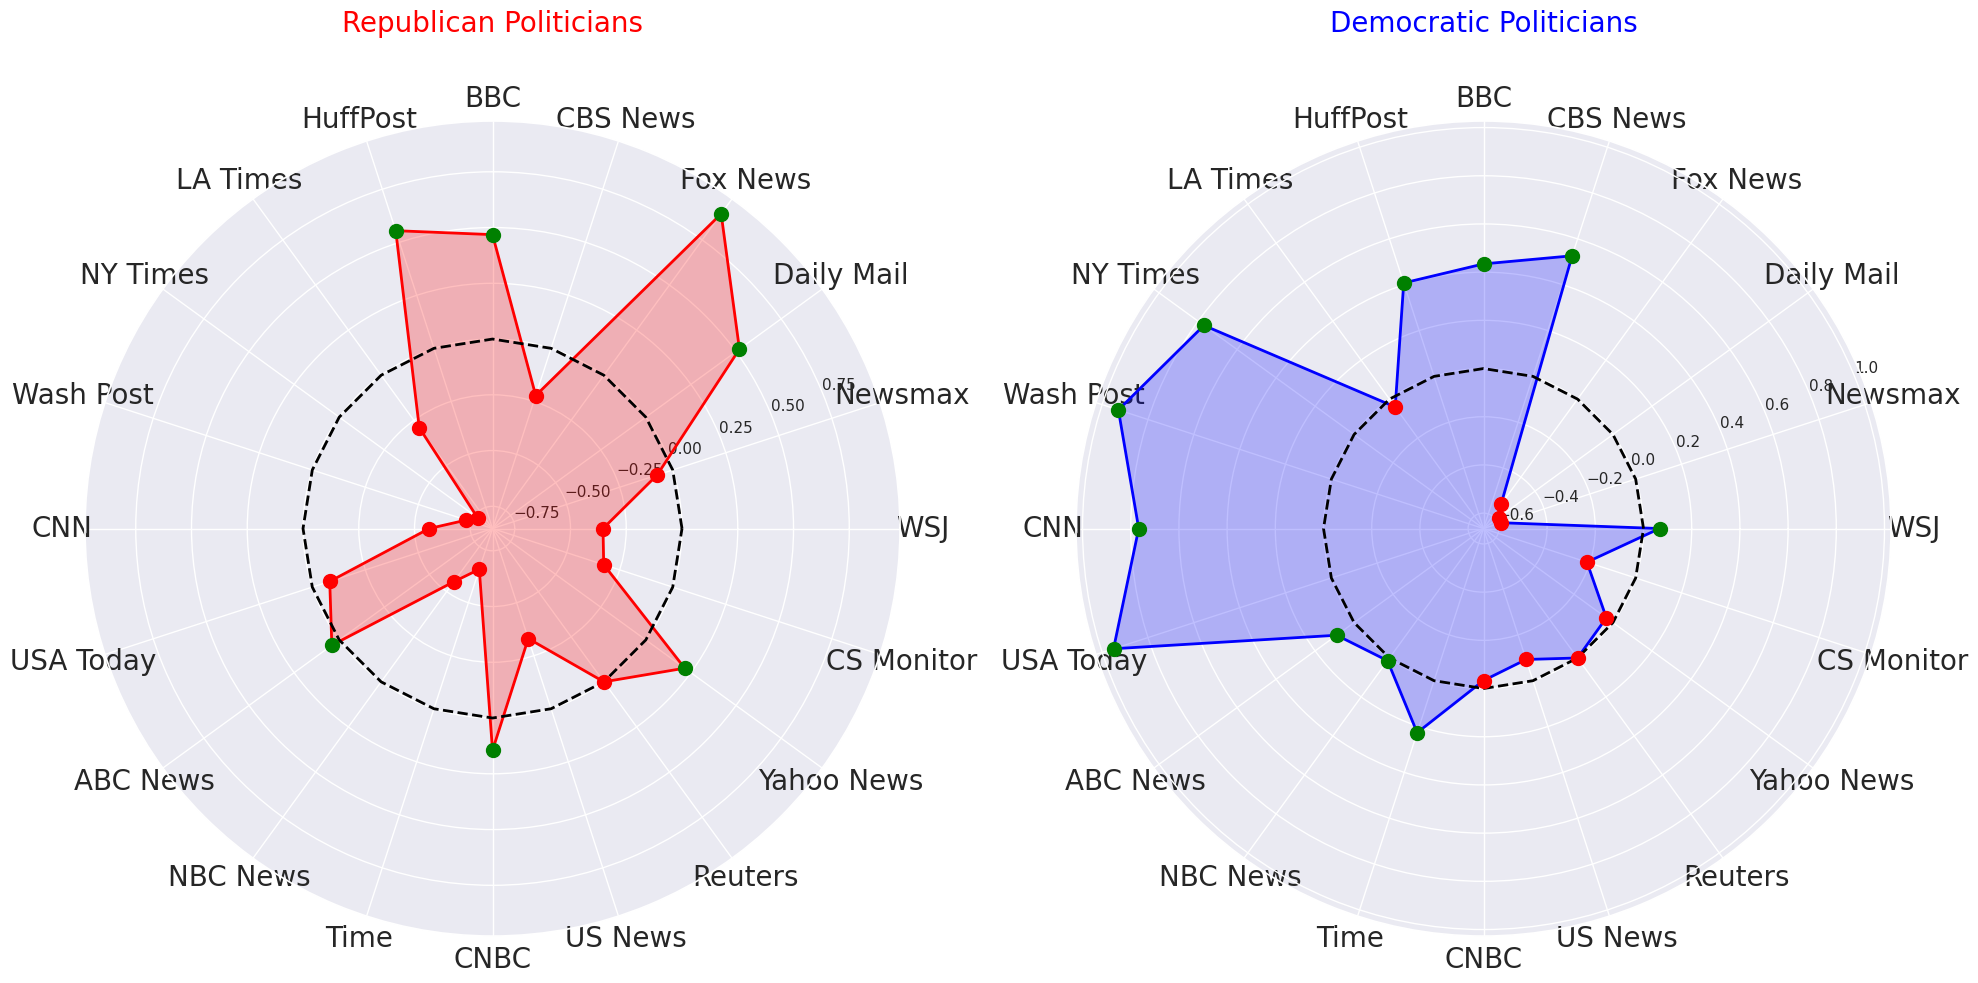

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('Final_CSV_For_Analysis.csv')

news_center_affiliations = {
    'www.wsj.com': 'Republican', 'www.newsmax.com': 'Republican', 'www.dailymail.co.uk': 'Republican', 'www.foxnews.com': 'Republican', 
    'www.cbsnews.com': 'Democratic', 'www.bbc.com': 'Democratic', 'www.huffpost.com': 'Democratic','www.latimes.com': 'Neutral', 
    'www.nytimes.com': 'Democratic', 'www.washingtonpost.com': 'Democratic', 'www.cnn.com': 'Democratic', 
    'www.usatoday.com': 'Neutral', 'abcnews.go.com': 'Democratic', 'www.nbcnews.com': 'Democratic', 'time.com': 'Democratic', 
    'www.cnbc.com': 'Democratic', 'www.usnews.com': 'Neutral', 'www.reuters.com': 'Neutral', 'news.yahoo.com': 'Neutral',
    'www.csmonitor.com': 'Neutral'
}

short_names = {
    'www.bbc.com': 'BBC', 'www.nytimes.com': 'NY Times', 'www.huffpost.com': 'HuffPost', 
    'www.washingtonpost.com': 'Wash Post', 'www.wsj.com': 'WSJ', 'www.cnn.com': 'CNN', 
    'www.cbsnews.com': 'CBS News', 'www.latimes.com': 'LA Times', 'www.dailymail.co.uk': 'Daily Mail', 
    'abcnews.go.com': 'ABC News', 'www.nbcnews.com': 'NBC News', 'www.foxnews.com': 'Fox News', 
    'www.newsmax.com': 'Newsmax', 'www.usnews.com': 'US News', 'time.com': 'Time', 
    'www.reuters.com': 'Reuters', 'news.yahoo.com': 'Yahoo News', 'www.usatoday.com': 'USA Today', 
    'www.cnbc.com': 'CNBC', 'www.csmonitor.com': 'CS Monitor'
}

person_affiliations = {
    'Joe Biden': 'Democratic', 'Donald Trump': 'Republican', 'Kamala Harris': 'Democratic', 
    'Mitch Mcconnell': 'Republican', 'Nancy Pelosi': 'Democratic', 'Mike Pence': 'Republican', 
    'Barack Obama': 'Democratic', 'Hillary Clinton': 'Democratic', 'Kevin McCarthy': 'Republican', 
    'Liz Cheney': 'Republican', 'Chuck Schumer': 'Democratic', 'Hal Rogers': 'Republican', 
    'Mitt Romney': 'Republican', 'Elizabeth Warren': 'Democratic', 'John Roberts': 'Republican', 
    'Bernie Sanders': 'Democratic', 'Joe Manchin': 'Democratic', 'Cory Booker': 'Democratic', 
    'Ted Cruz': 'Republican', 'Gavin Newsom': 'Democratic', 'Rand Paul': 'Republican', 
    'Marco Rubio': 'Republican', 'Amy Klobuchar': 'Democratic', 'Susan Collins': 'Republican', 
    'Bill de Blasio': 'Democratic', 'Janet Yellen': 'Democratic', 'Steny Hoyer': 'Democratic', 
    'James Clyburn': 'Democratic', 'Randy Biggs': 'Republican', 'Greg Abbott': 'Republican'
}

selected_news_centers = list(news_center_affiliations.keys())

mean_smile_effect = {
    'News Center': [],
    'Republican Politicians': [],
    'Democratic Politicians': []
}

for news_center in selected_news_centers:
    smile_column = f"Final_Ratio_{news_center}"
    if smile_column in df.columns:
        republican_mean_effect = df[(df['Real Person Side'] == 'Republican')][smile_column].mean()
        democratic_mean_effect = df[(df['Real Person Side'] == 'Democratic')][smile_column].mean()
        mean_smile_effect['News Center'].append(news_center)
        mean_smile_effect['Republican Politicians'].append(republican_mean_effect if not np.isnan(republican_mean_effect) else 0)
        mean_smile_effect['Democratic Politicians'].append(democratic_mean_effect if not np.isnan(democratic_mean_effect) else 0)

mean_smile_effect_df = pd.DataFrame(mean_smile_effect)

labels = mean_smile_effect_df['News Center'].map(short_names)
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10), subplot_kw=dict(polar=True))

republican_values = mean_smile_effect_df['Republican Politicians'].tolist()
republican_values += republican_values[:1]
ax1.plot(angles, republican_values, color='red', linewidth=2, linestyle='solid', label='Republican Politicians')
ax1.fill(angles, republican_values, color='red', alpha=0.25)

zero_circle = [0] * len(angles)
ax1.plot(angles, zero_circle, color='black', linewidth=2, linestyle='dashed', label='Zero Line')

for i, val in enumerate(mean_smile_effect_df['Republican Politicians']):
    color = 'green' if val > 0 else 'red'
    ax1.plot(angles[i], val, 'o', color=color, markersize=10)

ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(labels, size=20)
ax1.set_title('Republican Politicians', size=20, color='red', y=1.1)

democratic_values = mean_smile_effect_df['Democratic Politicians'].tolist()
democratic_values += democratic_values[:1]
ax2.plot(angles, democratic_values, color='blue', linewidth=2, linestyle='solid', label='Democratic Politicians')
ax2.fill(angles, democratic_values, color='blue', alpha=0.25)

ax2.plot(angles, zero_circle, color='black', linewidth=2, linestyle='dashed', label='Zero Line')

for i, val in enumerate(mean_smile_effect_df['Democratic Politicians']):
    color = 'green' if val > 0 else 'red'
    ax2.plot(angles[i], val, 'o', color=color, markersize=10)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(labels, size=20)
ax2.set_title('Democratic Politicians', size=20, color='blue', y=1.1)

plt.tight_layout()
#plt.savefig('Fig_smile_effect_Radar_NewsOutlet.png', dpi=70)
plt.show()


### Figures 10 and 11: Conservative Visual Slant (CSV)

Figures 10 and 11 report **Conservative Visual Slant (CSV)** by news outlet, defined as the difference between average visual slant toward Republican versus Democratic politicians. We first compute outlet-specific visual effects separately for Democratic and Republican politicians and then aggregate these differences to obtain an outlet-level measure of conservative versus liberal visual emphasis. Positive values indicate a more conservative visual slant, while negative values indicate a more liberal visual slant.

    Republican Politicians  Democratic Politicians
3                -0.726396                0.929181
1                -0.766602                0.770167
5                -0.565540                0.766854
17               -0.082196                0.950342
14               -0.657549                0.226741
6                -0.222683                0.526125
10               -0.555041                0.013789
4                -0.354185                0.066387
7                -0.291001               -0.040531
13               -0.330987               -0.092591
19               -0.325437               -0.212625
9                 0.040801                0.089288
15                0.000000                0.000000
0                 0.468155                0.434267
2                 0.554629                0.407558
18                0.145041               -0.033158
16                0.215544               -0.033785
12               -0.073871               -0.585926
8                 0.518853     

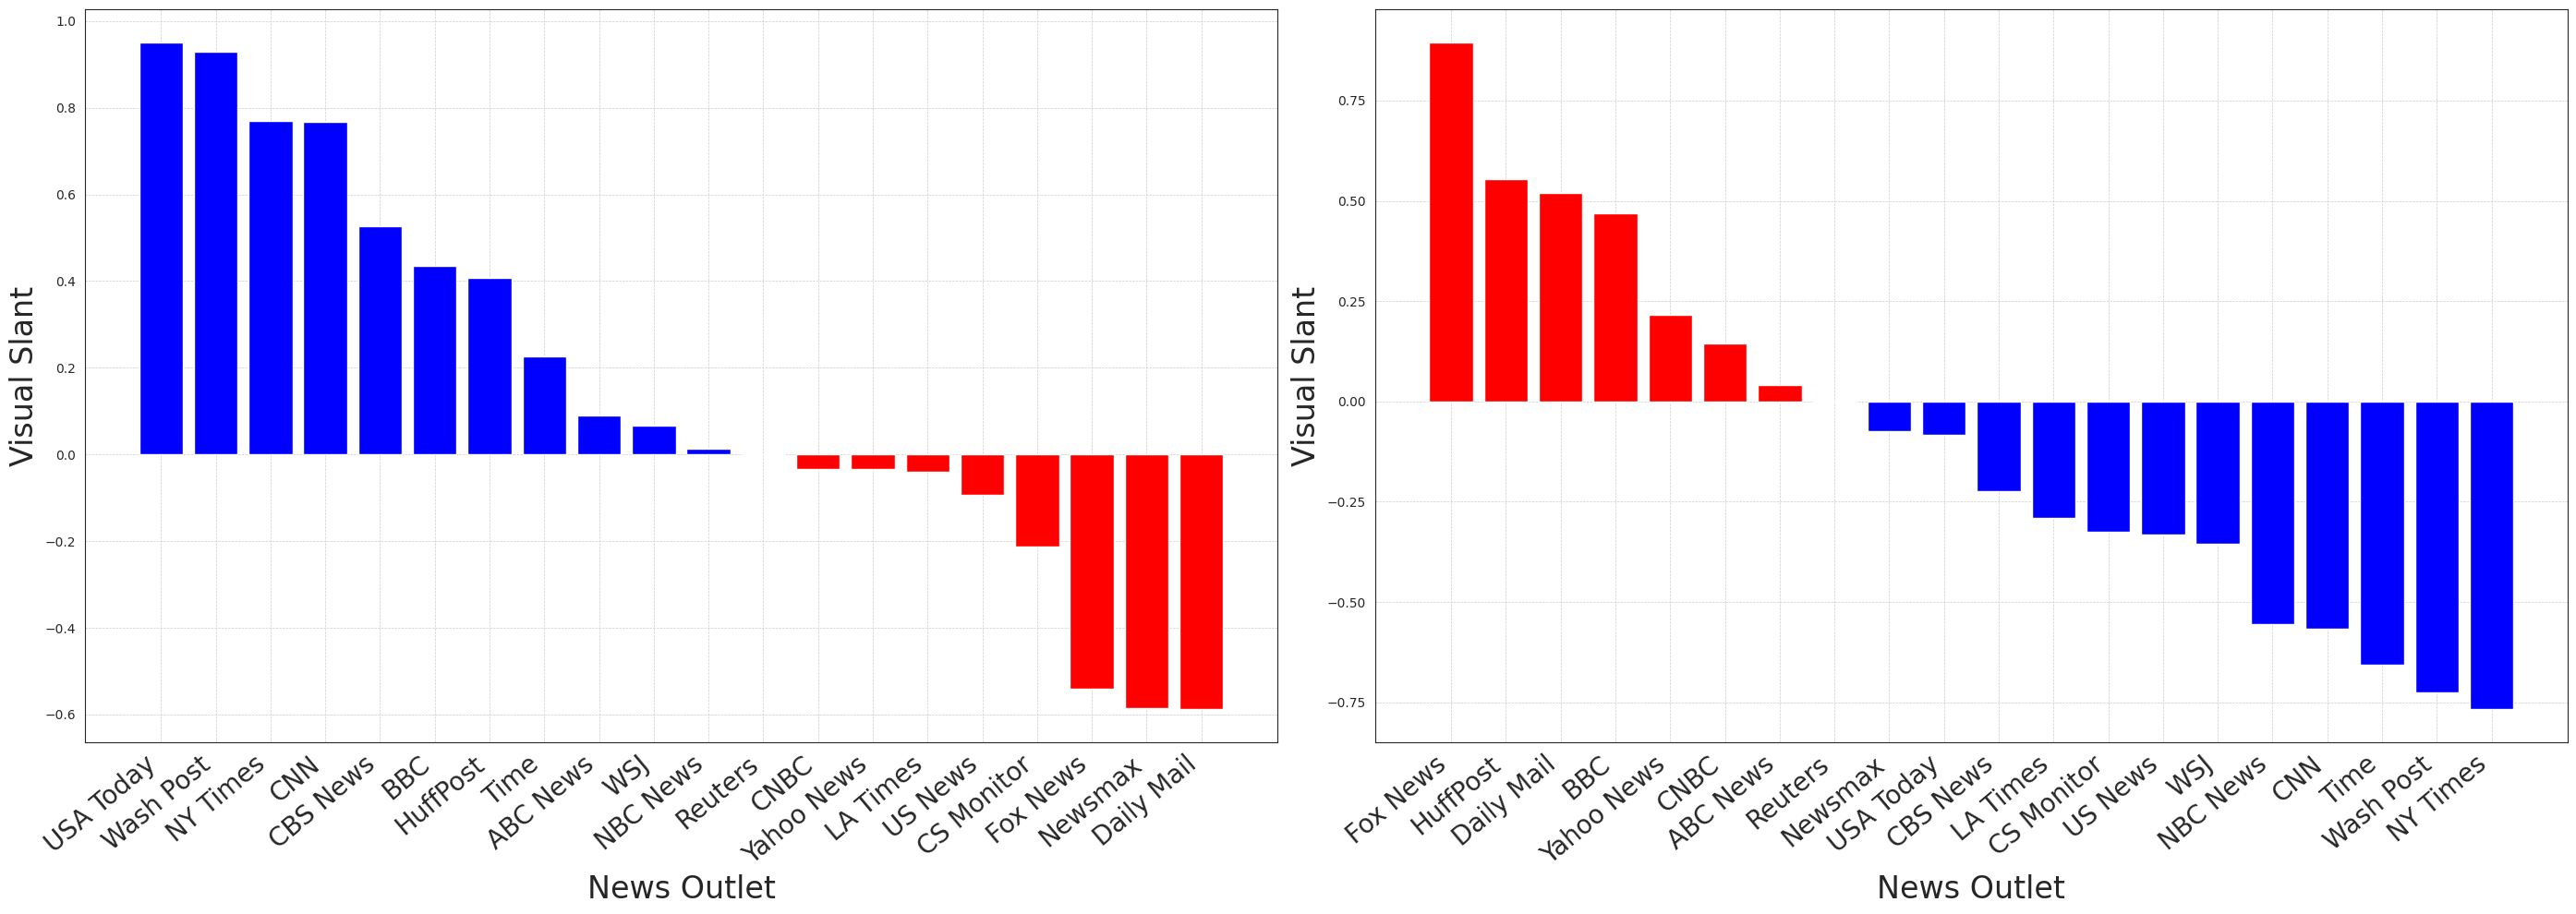

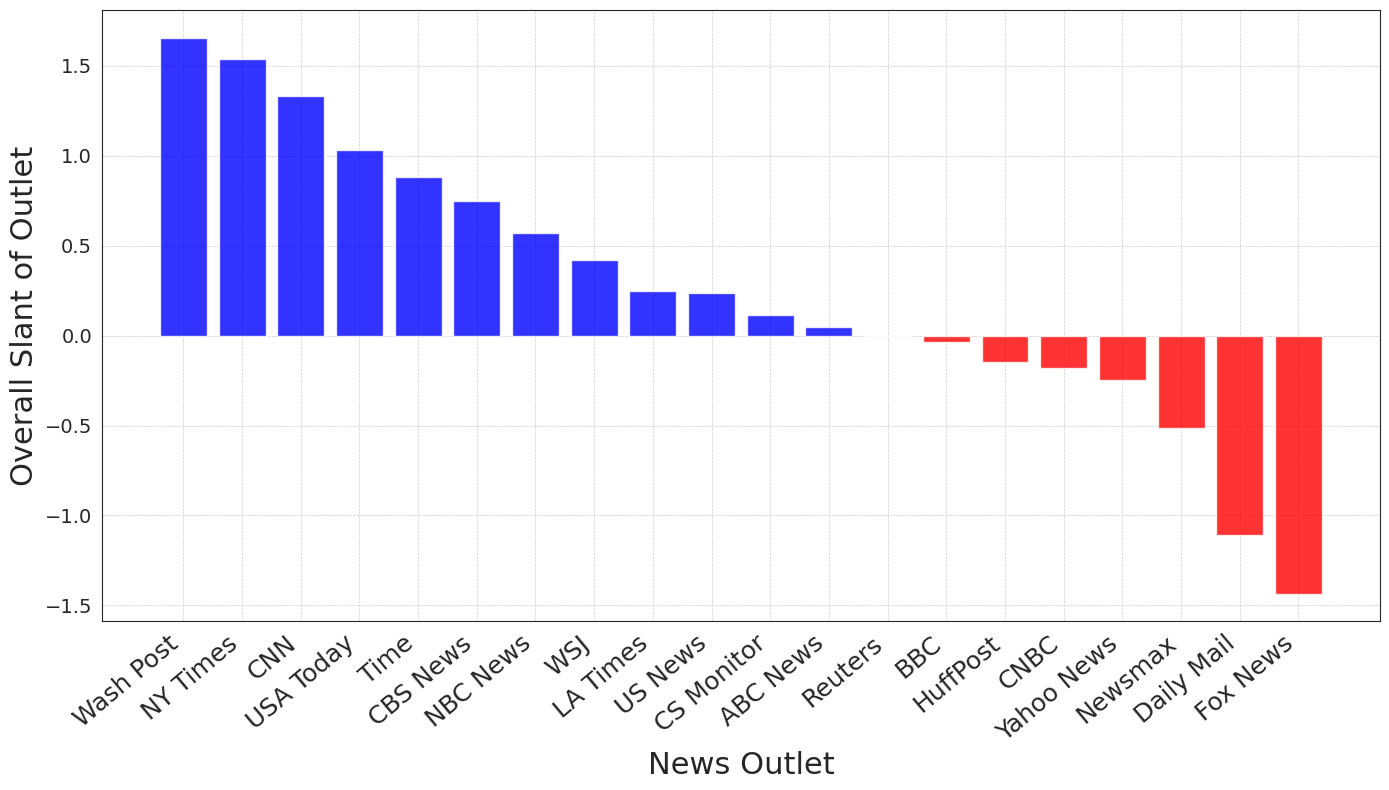

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
import seaborn as sns

df = pd.read_csv('Final_CSV_For_Analysis.csv').copy()

plt.style.use('default')
sns.set_style("white")

news_center_affiliations = {
    'www.bbc.com': 'Democratic', 'www.nytimes.com': 'Democratic', 'www.huffpost.com': 'Democratic', 
    'www.washingtonpost.com': 'Democratic', 'www.wsj.com': 'Republican', 'www.cnn.com': 'Democratic', 
    'www.cbsnews.com': 'Democratic', 'www.latimes.com': 'Neutral', 'www.dailymail.co.uk': 'Republican', 
    'abcnews.go.com': 'Democratic', 'www.nbcnews.com': 'Democratic', 'www.foxnews.com': 'Republican', 
    'www.newsmax.com': 'Republican', 'www.usnews.com': 'Neutral', 'time.com': 'Democratic', 
    'www.reuters.com': 'Neutral', 'news.yahoo.com': 'Neutral', 'www.usatoday.com': 'Neutral', 
    'www.cnbc.com': 'Democratic', 'www.csmonitor.com': 'Neutral'
}

short_names = {
    'www.bbc.com': 'BBC', 'www.nytimes.com': 'NY Times', 'www.huffpost.com': 'HuffPost', 
    'www.washingtonpost.com': 'Wash Post', 'www.wsj.com': 'WSJ', 'www.cnn.com': 'CNN', 
    'www.cbsnews.com': 'CBS News', 'www.latimes.com': 'LA Times', 'www.dailymail.co.uk': 'Daily Mail', 
    'abcnews.go.com': 'ABC News', 'www.nbcnews.com': 'NBC News', 'www.foxnews.com': 'Fox News', 
    'www.newsmax.com': 'Newsmax', 'www.usnews.com': 'US News', 'time.com': 'Time', 
    'www.reuters.com': 'Reuters', 'news.yahoo.com': 'Yahoo News', 'www.usatoday.com': 'USA Today', 
    'www.cnbc.com': 'CNBC', 'www.csmonitor.com': 'CS Monitor'
}

selected_news_centers = list(news_center_affiliations.keys())

mean_smile_effect = {
    'News Center': [],
    'Republican Politicians': [],
    'Democratic Politicians': []
}

for news_center in selected_news_centers:
    smile_column = f"Final_Ratio_{news_center}"
    if smile_column in df.columns:
        republican_mean_effect = df[(df['Real Person Side'] == 'Republican')][smile_column].mean()
        democratic_mean_effect = df[(df['Real Person Side'] == 'Democratic')][smile_column].mean()
        mean_smile_effect['News Center'].append(news_center)
        mean_smile_effect['Republican Politicians'].append(republican_mean_effect if not np.isnan(republican_mean_effect) else 0)
        mean_smile_effect['Democratic Politicians'].append(democratic_mean_effect if not np.isnan(democratic_mean_effect) else 0)

mean_smile_effect_df = pd.DataFrame(mean_smile_effect)

democratic_sorted_df = mean_smile_effect_df.sort_values(by='Democratic Politicians', ascending=False)
republican_sorted_df = mean_smile_effect_df.sort_values(by='Republican Politicians', ascending=False)

fig_side_by_side, (ax1, ax2) = plt.subplots(1, 2, figsize=(28, 10))

democratic_values = democratic_sorted_df['Democratic Politicians']
democratic_colors = ['blue' if val > 0 else 'red' for val in democratic_values]
ax1.bar(democratic_sorted_df['News Center'], democratic_values, color=democratic_colors)
ax1.set_title('Polarization for Democratic Politicians', fontsize=24)
ax1.set_title('', fontsize=24)
ax1.set_xlabel('News Outlet', fontsize=24)
ax1.set_ylabel('Visual Slant', fontsize=24)
ax1.set_xticks(range(len(democratic_sorted_df['News Center'])))
ax1.set_xticklabels([short_names[nc] for nc in democratic_sorted_df['News Center']], ha='right', rotation=40, fontsize=20)
ax1.grid(True, linestyle='--', linewidth=0.5)

republican_values = republican_sorted_df['Republican Politicians']
republican_colors = ['red' if val > 0 else 'blue' for val in republican_values]
ax2.bar(republican_sorted_df['News Center'], republican_values, color=republican_colors)
ax2.set_title('Polarization for Republican Politicians', fontsize=24)
ax2.set_title('', fontsize=24)
ax2.set_xlabel('News Outlet', fontsize=24)
ax2.set_ylabel('Visual Slant', fontsize=24)
ax2.set_xticks(range(len(republican_sorted_df['News Center'])))
ax2.set_xticklabels([short_names[nc] for nc in republican_sorted_df['News Center']], ha='right', rotation=40, fontsize=20)
ax2.grid(True, linestyle='--', linewidth=0.5)

fig_side_by_side.tight_layout()
#fig_side_by_side.savefig('Fig_side_by_side_smile_effect.png', dpi=100)

mean_smile_effect_df['Overall Polarization'] = (mean_smile_effect_df['Democratic Politicians'] - mean_smile_effect_df['Republican Politicians'])

mean_smile_effect_df = mean_smile_effect_df.sort_values(by='Overall Polarization', ascending=False)

print(mean_smile_effect_df[['Republican Politicians', 'Democratic Politicians']])
mean_smile_effect_df['Difference'] = mean_smile_effect_df['Republican Politicians'] - mean_smile_effect_df['Democratic Politicians']
print(mean_smile_effect_df[['Difference', 'Overall Polarization']])

fig3, ax3 = plt.subplots(figsize=(14, 8))

bar_colors = ['blue' if value > 0 else 'red' for value in mean_smile_effect_df['Overall Polarization']]
bars = ax3.bar(mean_smile_effect_df['News Center'], mean_smile_effect_df['Overall Polarization'], color=bar_colors, alpha=0.8)

ax3.set_xlabel('News Outlet', fontsize=22)
ax3.set_ylabel('Overall Slant of Outlet', fontsize=22)
ax3.set_xticks(range(len(mean_smile_effect_df['News Center'])))
ax3.set_xticklabels([short_names[nc] for nc in mean_smile_effect_df['News Center']], ha='right', rotation=40, fontsize=18)
ax3.tick_params(axis='y', labelsize=14)
ax3.grid(True, which='both', linestyle='--', linewidth=0.5)

fig3.tight_layout()
#fig3.savefig('Fig_overall_polarization.png', dpi=70)

plt.show()


### Figures 11, A7, A8, A9


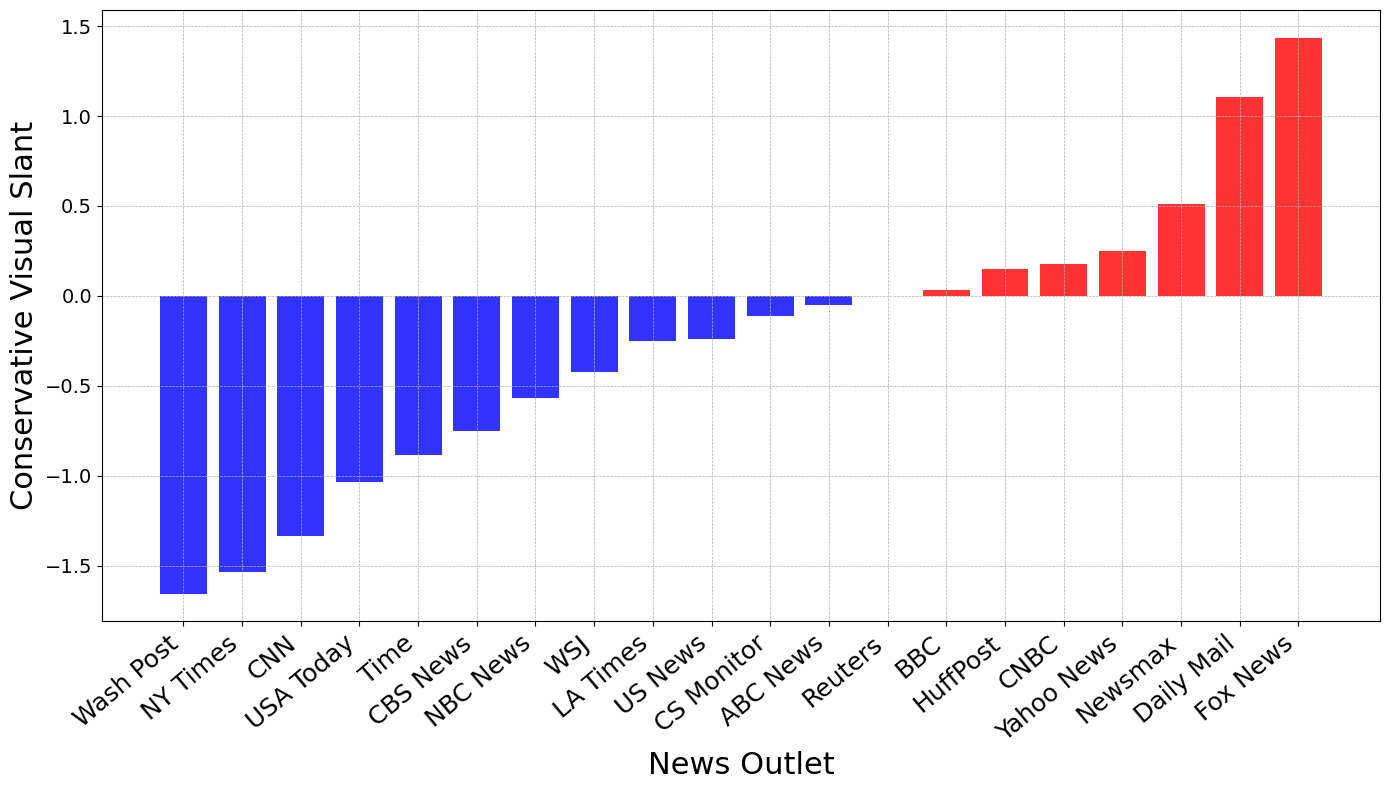

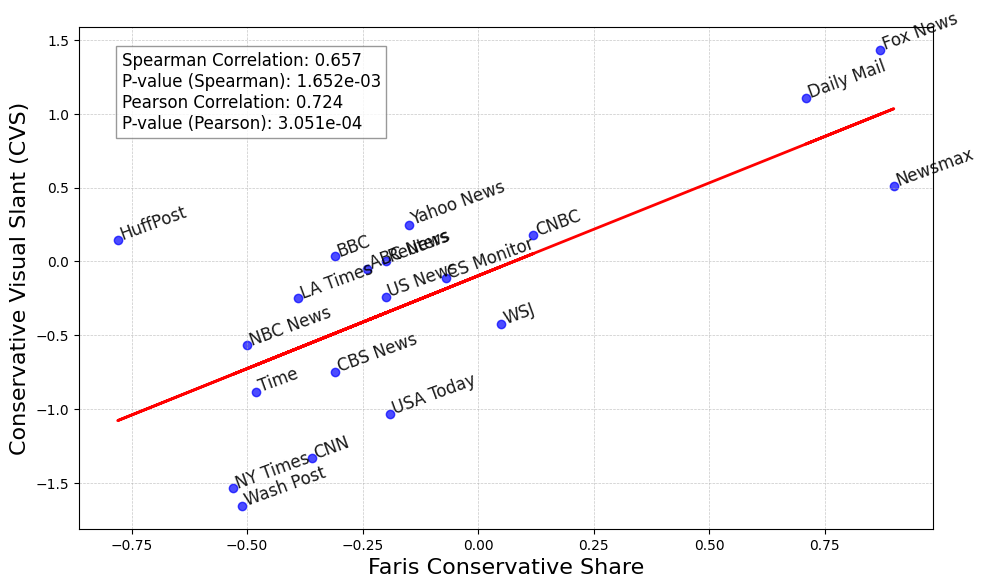

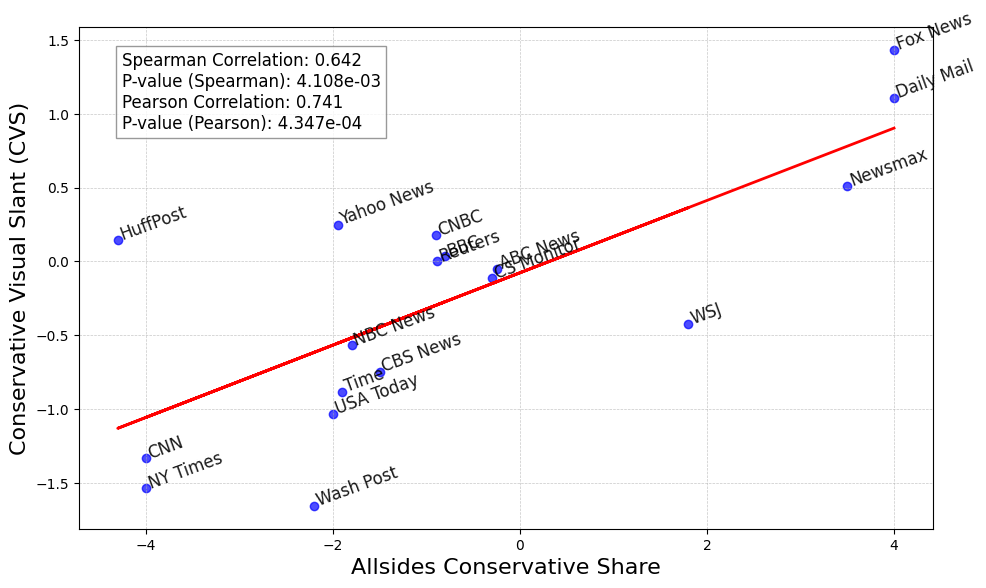

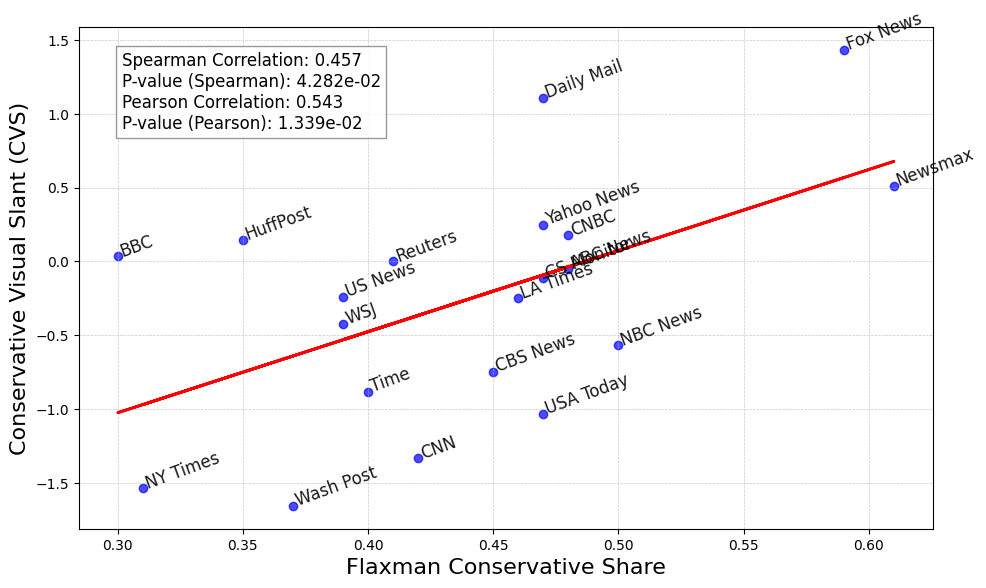

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
import statsmodels.api as sm
from scipy.stats import spearmanr, pearsonr

df = pd.read_csv('Final_CSV_For_Analysis.csv').copy()

plt.style.use('default')

news_center_affiliations = {
    'www.bbc.com': 'Democratic', 'www.nytimes.com': 'Democratic', 'www.huffpost.com': 'Democratic',
    'www.washingtonpost.com': 'Democratic', 'www.wsj.com': 'Republican', 'www.cnn.com': 'Democratic',
    'www.cbsnews.com': 'Democratic', 'www.latimes.com': 'Neutral', 'www.dailymail.co.uk': 'Republican',
    'abcnews.go.com': 'Democratic', 'www.nbcnews.com': 'Democratic', 'www.foxnews.com': 'Republican',
    'www.newsmax.com': 'Republican', 'www.usnews.com': 'Neutral', 'time.com': 'Democratic',
    'www.reuters.com': 'Neutral', 'news.yahoo.com': 'Neutral', 'www.usatoday.com': 'Neutral',
    'www.cnbc.com': 'Democratic', 'www.csmonitor.com': 'Neutral'
}

short_names = {
    'www.bbc.com': 'BBC', 'www.nytimes.com': 'NY Times', 'www.huffpost.com': 'HuffPost',
    'www.washingtonpost.com': 'Wash Post', 'www.wsj.com': 'WSJ', 'www.cnn.com': 'CNN',
    'www.cbsnews.com': 'CBS News', 'www.latimes.com': 'LA Times', 'www.dailymail.co.uk': 'Daily Mail',
    'abcnews.go.com': 'ABC News', 'www.nbcnews.com': 'NBC News', 'www.foxnews.com': 'Fox News',
    'www.newsmax.com': 'Newsmax', 'www.usnews.com': 'US News', 'time.com': 'Time',
    'www.reuters.com': 'Reuters', 'news.yahoo.com': 'Yahoo News', 'www.usatoday.com': 'USA Today',
    'www.cnbc.com': 'CNBC', 'www.csmonitor.com': 'CS Monitor'
}

selected_news_centers = list(news_center_affiliations.keys())

mean_smile_effect = {
    'News Center': [],
    'Republican Politicians': [],
    'Democratic Politicians': []
}

for news_center in selected_news_centers:
    smile_column = f"Final_Ratio_{news_center}"
    if smile_column in df.columns:
        republican_mean_effect = df[(df['Real Person Side'] == 'Republican')][smile_column].mean()
        democratic_mean_effect = df[(df['Real Person Side'] == 'Democratic')][smile_column].mean()
        mean_smile_effect['News Center'].append(news_center)
        mean_smile_effect['Republican Politicians'].append(republican_mean_effect if not np.isnan(republican_mean_effect) else 0)
        mean_smile_effect['Democratic Politicians'].append(democratic_mean_effect if not np.isnan(democratic_mean_effect) else 0)

mean_smile_effect_df = pd.DataFrame(mean_smile_effect)
mean_smile_effect_df['Overall Polarization'] = (mean_smile_effect_df['Republican Politicians'] - mean_smile_effect_df['Democratic Politicians'])
mean_smile_effect_df = mean_smile_effect_df.sort_values(by='Overall Polarization', ascending=True)

fig3, ax3 = plt.subplots(figsize=(14, 8))
bar_colors = ['red' if value > 0 else 'blue' for value in mean_smile_effect_df['Overall Polarization']]
ax3.bar(mean_smile_effect_df['News Center'], mean_smile_effect_df['Overall Polarization'], color=bar_colors, alpha=0.8)
ax3.set_xlabel('News Outlet', fontsize=22)
ax3.set_ylabel('Conservative Visual Slant', fontsize=22)
ax3.set_xticks(range(len(mean_smile_effect_df['News Center'])))
ax3.set_xticklabels([short_names[nc] for nc in mean_smile_effect_df['News Center']], ha='right', rotation=40, fontsize=18)
ax3.tick_params(axis='y', labelsize=14)
ax3.grid(True, which='both', linestyle='--', linewidth=0.5)
fig3.tight_layout()
fig3.savefig('Fig_overall_polarization.png', dpi=70)
plt.show()

harvard = {'www.bbc.com': -0.31, 'www.nytimes.com': -0.53, 'www.huffpost.com': -0.78, 'www.washingtonpost.com': -0.51,
           'www.wsj.com': 0.05, 'www.usnews.com': -0.20, 'time.com': -0.48, 'www.reuters.com': -0.20, 'www.cnn.com': -0.36,
           'www.cbsnews.com': -0.31, 'www.latimes.com': -0.39, 'news.yahoo.com': -0.15, 'www.usatoday.com': -0.19,
           'www.dailymail.co.uk': 0.71, 'www.cnbc.com': 0.12, 'www.csmonitor.com': -0.07, 'abcnews.go.com': -0.24,
           'www.nbcnews.com': -0.50, 'www.foxnews.com': 0.87, 'www.newsmax.com': 0.9}

allsides = {'www.bbc.com': -0.8, 'www.nytimes.com': -4, 'www.huffpost.com': -4.3, 'www.washingtonpost.com': -2.2,
            'www.wsj.com': 1.8, 'time.com': -1.9, 'www.reuters.com': -0.89, 'www.cnn.com': -4, 'www.cbsnews.com': -1.5,
            'news.yahoo.com': -1.95, 'www.usatoday.com': -2, 'www.dailymail.co.uk': 4, 'www.cnbc.com': -0.9,
            'www.csmonitor.com': -0.3, 'abcnews.go.com': -0.24, 'www.nbcnews.com': -1.8, 'www.foxnews.com': 4,
            'www.newsmax.com': 3.5}

other_paper = {'www.bbc.com': 0.30, 'www.nytimes.com': 0.31, 'www.huffpost.com': 0.35, 'www.washingtonpost.com': 0.37,
               'www.wsj.com': 0.39, 'www.usnews.com': 0.39, 'time.com': 0.40, 'www.reuters.com': 0.41, 'www.cnn.com': 0.42,
               'www.cbsnews.com': 0.45, 'www.latimes.com': 0.46, 'news.yahoo.com': 0.47, 'www.usatoday.com': 0.47,
               'www.dailymail.co.uk': 0.47, 'www.cnbc.com': 0.48, 'www.csmonitor.com': 0.47, 'abcnews.go.com': 0.48,
               'www.nbcnews.com': 0.50, 'www.foxnews.com': 0.59, 'www.newsmax.com': 0.61}

def plot_and_save_regression_with_correlation(conservative_share, conservative_label, filename):
    valid_outlets = [nc for nc in mean_smile_effect_df['News Center'] if nc in conservative_share]
    x = [conservative_share[nc] for nc in valid_outlets]
    y = mean_smile_effect_df.loc[mean_smile_effect_df['News Center'].isin(valid_outlets), 'Overall Polarization']
    spearman_corr, spearman_p_value = spearmanr(x, y)
    pearson_corr, pearson_p_value = pearsonr(x, y)
    x_with_constant = sm.add_constant(x)
    model = sm.OLS(y, x_with_constant).fit()
    intercept = model.params.iloc[0]
    slope = model.params.iloc[1]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(x, y, color='blue', alpha=0.7)
    ax.plot(x, intercept + slope * np.array(x), color='red', linestyle='-', linewidth=2)
    valid_short_names = [short_names[nc] for nc in valid_outlets]
    for i, short_name in enumerate(valid_short_names):
        ax.annotate(short_name, (x[i], y.iloc[i]), fontsize=12, alpha=0.9, rotation=20)
    stats_text = (
        f"Spearman Correlation: {spearman_corr:.3f}\n"
        f"P-value (Spearman): {spearman_p_value:.3e}\n"
        f"Pearson Correlation: {pearson_corr:.3f}\n"
        f"P-value (Pearson): {pearson_p_value:.3e}"
    )
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=12, verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
    ax.set_xlabel(conservative_label, fontsize=16)
    ax.set_ylabel("Conservative Visual Slant (CVS)", fontsize=16)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.savefig(filename, dpi=100)
    plt.show()
    plt.close(fig)

plot_and_save_regression_with_correlation(harvard, "Faris Conservative Share", "Harvard_Correlation_vs_Polarization.png")
plot_and_save_regression_with_correlation(allsides, "Allsides Conservative Share", "Allsides_Correlation_vs_Polarization.png")
plot_and_save_regression_with_correlation(other_paper, "Flaxman Conservative Share", "OtherPaper_Correlation_vs_Polarization.png")


## Permutation-Based Validation of Visual Slant Correlations (Figure 12)

This script computes outlet-level Conservative Visual Slant (CVS) from image-based smile effects, correlates it with external conservative-share measures, and validates the relationship using a permutation test that randomizes politician party labels. The figure contrasts the observed regression line with the mean placebo trend from the null distribution.

Running 100 permutations for Fig_OtherPaper_with_Placebo_PMCIG.png...


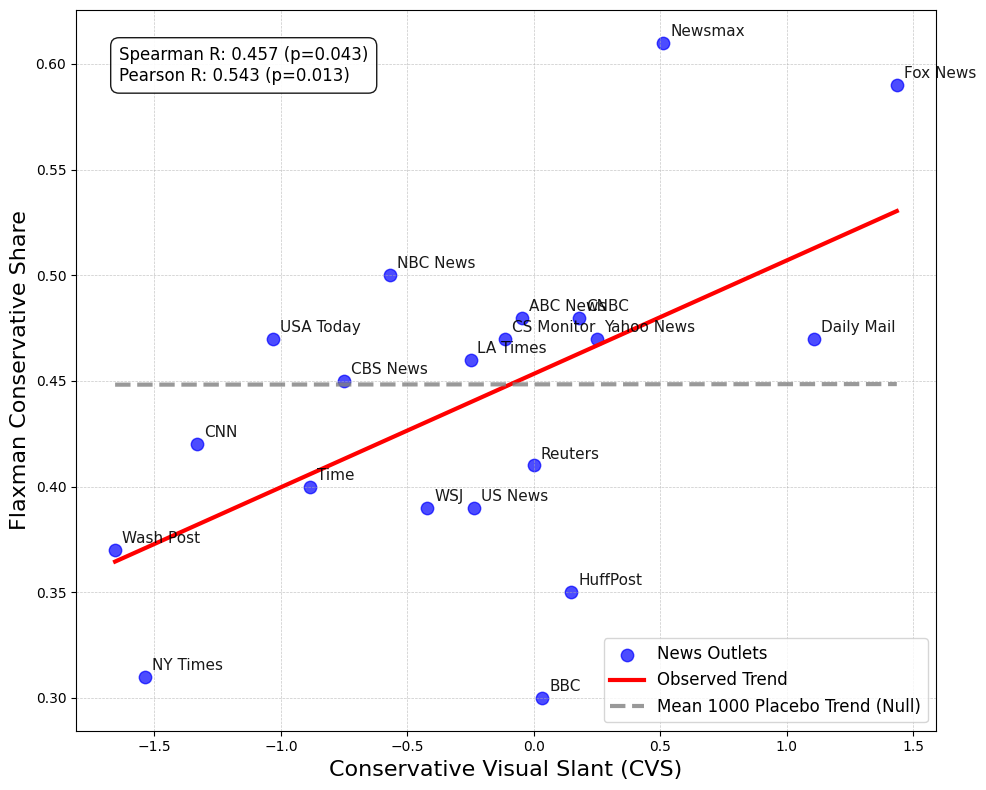

Running 100 permutations for Fig_Harvard_with_Placebo_PMCIG.png...


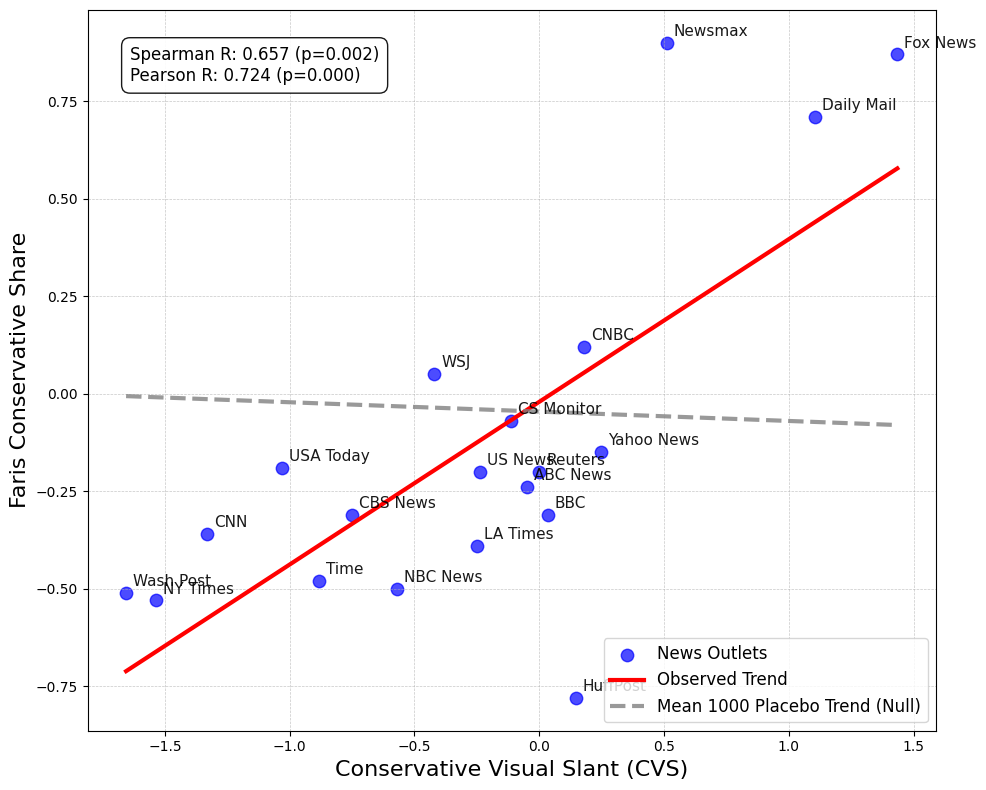

Running 100 permutations for Fig_Allsides_with_Placebo_PMCIG.png...


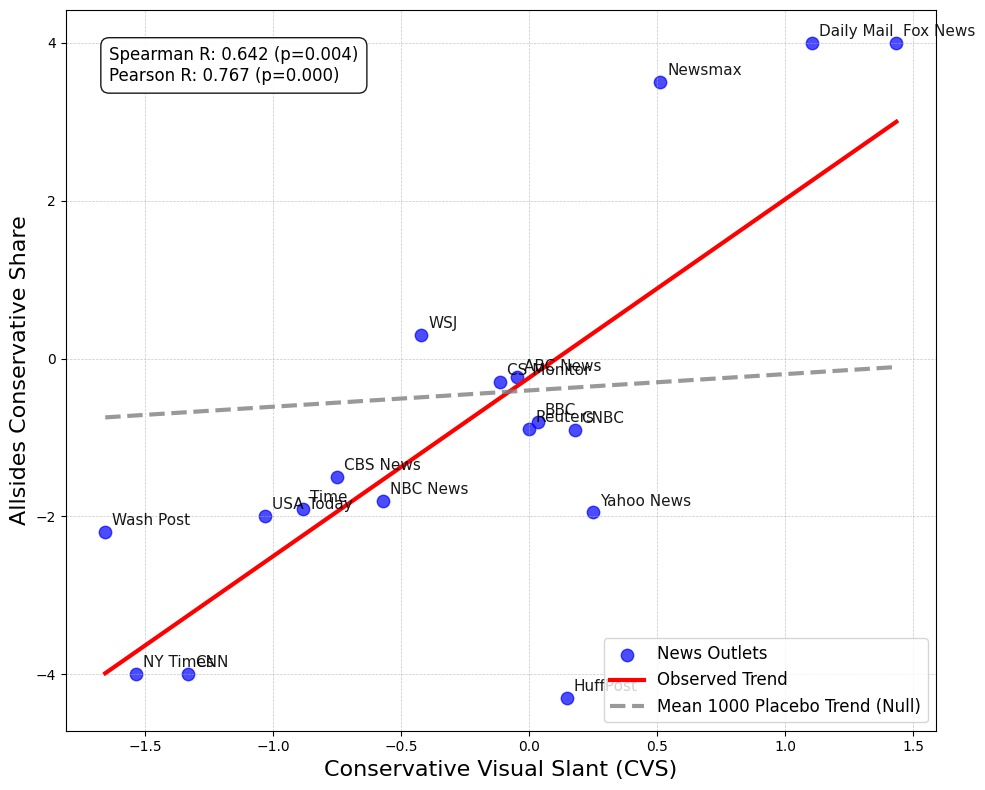

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from scipy.stats import spearmanr, pearsonr
from matplotlib.gridspec import GridSpec

np.random.seed(42)
N_PERMUTATIONS = 1000

df = pd.read_csv('Final_CSV_For_Analysis.csv').copy()

plt.style.use('default')

news_center_affiliations = {
    'www.bbc.com': 'Democratic', 'www.nytimes.com': 'Democratic', 'www.huffpost.com': 'Democratic',
    'www.washingtonpost.com': 'Democratic', 'www.wsj.com': 'Republican', 'www.cnn.com': 'Democratic',
    'www.cbsnews.com': 'Democratic', 'www.latimes.com': 'Neutral', 'www.dailymail.co.uk': 'Republican',
    'abcnews.go.com': 'Democratic', 'www.nbcnews.com': 'Democratic', 'www.foxnews.com': 'Republican',
    'www.newsmax.com': 'Republican', 'www.usnews.com': 'Neutral', 'time.com': 'Democratic',
    'www.reuters.com': 'Neutral', 'news.yahoo.com': 'Neutral', 'www.usatoday.com': 'Neutral',
    'www.cnbc.com': 'Democratic', 'www.csmonitor.com': 'Neutral'
}

short_names = {
    'www.bbc.com': 'BBC', 'www.nytimes.com': 'NY Times', 'www.huffpost.com': 'HuffPost',
    'www.washingtonpost.com': 'Wash Post', 'www.wsj.com': 'WSJ', 'www.cnn.com': 'CNN',
    'www.cbsnews.com': 'CBS News', 'www.latimes.com': 'LA Times', 'www.dailymail.co.uk': 'Daily Mail',
    'abcnews.go.com': 'ABC News', 'www.nbcnews.com': 'NBC News', 'www.foxnews.com': 'Fox News',
    'www.newsmax.com': 'Newsmax', 'www.usnews.com': 'US News', 'time.com': 'Time',
    'www.reuters.com': 'Reuters', 'news.yahoo.com': 'Yahoo News', 'www.usatoday.com': 'USA Today',
    'www.cnbc.com': 'CNBC', 'www.csmonitor.com': 'CS Monitor'
}

harvard = {
    'www.bbc.com': -0.31, 'www.nytimes.com': -0.53, 'www.huffpost.com': -0.78,
    'www.washingtonpost.com': -0.51, 'www.wsj.com': 0.05, 'www.usnews.com': -0.20,
    'time.com': -0.48, 'www.reuters.com': -0.20, 'www.cnn.com': -0.36,
    'www.cbsnews.com': -0.31, 'www.latimes.com': -0.39, 'news.yahoo.com': -0.15,
    'www.usatoday.com': -0.19, 'www.dailymail.co.uk': 0.71, 'www.cnbc.com': 0.12,
    'www.csmonitor.com': -0.07, 'abcnews.go.com': -0.24, 'www.nbcnews.com': -0.50,
    'www.foxnews.com': 0.87, 'www.newsmax.com': 0.9
}

allsides = {
    'www.bbc.com': -0.8, 'www.nytimes.com': -4, 'www.huffpost.com': -4.3,
    'www.washingtonpost.com': -2.2, 'www.wsj.com': 0.3, 'time.com': -1.9,
    'www.reuters.com': -0.89, 'www.cnn.com': -4, 'www.cbsnews.com': -1.5,
    'news.yahoo.com': -1.95, 'www.usatoday.com': -2,
    'www.dailymail.co.uk': 4, 'www.cnbc.com': -0.9,
    'www.csmonitor.com': -0.3, 'abcnews.go.com': -0.24,
    'www.nbcnews.com': -1.8, 'www.foxnews.com': 4,
    'www.newsmax.com': 3.5
}

other_paper = {
    'www.bbc.com': 0.30, 'www.nytimes.com': 0.31, 'www.huffpost.com': 0.35,
    'www.washingtonpost.com': 0.37, 'www.wsj.com': 0.39, 'www.usnews.com': 0.39,
    'time.com': 0.40, 'www.reuters.com': 0.41, 'www.cnn.com': 0.42,
    'www.cbsnews.com': 0.45, 'www.latimes.com': 0.46, 'news.yahoo.com': 0.47,
    'www.usatoday.com': 0.47, 'www.dailymail.co.uk': 0.47,
    'www.cnbc.com': 0.48, 'www.csmonitor.com': 0.47,
    'abcnews.go.com': 0.48, 'www.nbcnews.com': 0.50,
    'www.foxnews.com': 0.59, 'www.newsmax.com': 0.61
}

selected_news_centers = list(news_center_affiliations.keys())

mean_smile_effect = {
    'News Center': [],
    'Republican Politicians': [],
    'Democratic Politicians': []
}

for news_center in selected_news_centers:
    smile_column = f"Final_Ratio_{news_center}"
    if smile_column in df.columns:
        republican_mean_effect = df[df['Real Person Side'] == 'Republican'][smile_column].mean()
        democratic_mean_effect = df[df['Real Person Side'] == 'Democratic'][smile_column].mean()
        mean_smile_effect['News Center'].append(news_center)
        mean_smile_effect['Republican Politicians'].append(republican_mean_effect if not np.isnan(republican_mean_effect) else 0)
        mean_smile_effect['Democratic Politicians'].append(democratic_mean_effect if not np.isnan(democratic_mean_effect) else 0)

mean_smile_effect_df = pd.DataFrame(mean_smile_effect)
mean_smile_effect_df['Overall Polarization'] = (
    mean_smile_effect_df['Republican Politicians'] -
    mean_smile_effect_df['Democratic Politicians']
)
mean_smile_effect_df = mean_smile_effect_df.sort_values(by='Overall Polarization', ascending=True)

def run_permutation_slopes(external_scores_dict):
    valid_outlets = [nc for nc in mean_smile_effect_df['News Center'] if nc in external_scores_dict]
    y_fixed = np.array([external_scores_dict[nc] for nc in valid_outlets], dtype=float)
    x_observed = mean_smile_effect_df.loc[
        mean_smile_effect_df['News Center'].isin(valid_outlets),
        'Overall Polarization'
    ].values
    r_observed, _ = spearmanr(x_observed, y_fixed)
    politician_affiliations = df[['Top1_Person', 'Real Person Side']].drop_duplicates()
    null_slopes = []
    null_intercepts = []
    null_correlations = []
    for _ in range(N_PERMUTATIONS):
        shuffled_labels = politician_affiliations['Real Person Side'].sample(frac=1, replace=False).values
        politician_map = dict(zip(politician_affiliations['Top1_Person'], shuffled_labels))
        df_permuted = df.copy()
        df_permuted['Permuted Affiliation'] = df_permuted['Top1_Person'].map(politician_map)
        permuted_slants = []
        for news_center in valid_outlets:
            smile_column = f"Final_Ratio_{news_center}"
            r_perm_mean = df_permuted[df_permuted['Permuted Affiliation'] == 'Republican'][smile_column].mean()
            d_perm_mean = df_permuted[df_permuted['Permuted Affiliation'] == 'Democratic'][smile_column].mean()
            val_r = r_perm_mean if not np.isnan(r_perm_mean) else 0
            val_d = d_perm_mean if not np.isnan(d_perm_mean) else 0
            permuted_slants.append(val_r - val_d)
        x_perm = np.array(permuted_slants, dtype=float)
        r_perm, _ = spearmanr(x_perm, y_fixed)
        null_correlations.append(r_perm)
        x_perm_const = sm.add_constant(x_perm)
        model = sm.OLS(y_fixed, x_perm_const).fit()
        null_intercepts.append(model.params[0])
        null_slopes.append(model.params[1])
    null_correlations = np.array(null_correlations)
    p_value = (np.sum(np.abs(null_correlations) >= np.abs(r_observed)) + 1) / (N_PERMUTATIONS + 1)
    return p_value, np.mean(null_slopes), np.mean(null_intercepts)

def plot_regression_with_placebo_line(conservative_share, conservative_label, filename):
    valid_outlets = [nc for nc in mean_smile_effect_df['News Center'] if nc in conservative_share]
    y = np.array([conservative_share[nc] for nc in valid_outlets])
    x = mean_smile_effect_df.loc[
        mean_smile_effect_df['News Center'].isin(valid_outlets),
        'Overall Polarization'
    ].values
    valid_short_names = [short_names[nc] for nc in valid_outlets]
    x_with_const = sm.add_constant(x)
    model = sm.OLS(y, x_with_const).fit()
    true_intercept = model.params[0]
    true_slope = model.params[1]
    spearman_corr, spearman_p_val_true = spearmanr(x, y)
    pearson_corr, pearson_p_val_true = pearsonr(x, y)
    p_val_perm, mean_placebo_slope, mean_placebo_intercept = run_permutation_slopes(conservative_share)
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(x, y, color='blue', alpha=0.7, s=80, label='News Outlets')
    x_range = np.linspace(min(x), max(x), 100)
    y_true_line = true_intercept + true_slope * x_range
    ax.plot(x_range, y_true_line, color='red', linestyle='-', linewidth=3, label='Observed Trend')
    y_placebo_line = mean_placebo_intercept + mean_placebo_slope * x_range
    ax.plot(x_range, y_placebo_line, color='gray', linestyle='--', linewidth=3, alpha=0.8,
            label='Mean 1000 Placebo Trend (Null)')
    for i, short_name in enumerate(valid_short_names):
        ax.annotate(short_name, (x[i], y[i]), fontsize=11, alpha=0.9,
                    xytext=(5, 5), textcoords='offset points')
    stats_text = (
        f"Spearman R: {spearman_corr:.3f} (p={spearman_p_val_true:.3f})\n"
        f"Pearson R: {pearson_corr:.3f} (p={pearson_p_val_true:.3f})"
    )
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
            verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.9,
                      edgecolor='black', boxstyle='round,pad=0.5'))
    ax.set_xlabel("Conservative Visual Slant (CVS)", fontsize=16)
    ax.set_ylabel(conservative_label, fontsize=16)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    ax.legend(loc='lower right', fontsize=12)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()
    plt.close(fig)

plot_regression_with_placebo_line(other_paper, "Flaxman Conservative Share", "Fig_OtherPaper_with_Placebo_PMCIG.png")
plot_regression_with_placebo_line(harvard, "Faris Conservative Share", "Fig_Harvard_with_Placebo_PMCIG.png")
plot_regression_with_placebo_line(allsides, "Allsides Conservative Share", "Fig_Allsides_with_Placebo_PMCIG.png")

## Comparison with Boxell et al. (2021)

This analysis compares our Conservative Visual Slant (CVS) measure to visual slant estimates reported in Boxell et al. (2021), using their published outlet-level data. We directly benchmark CVS against the Boxell measure across common outlets and evaluate alignment using correlation and regression analyses.

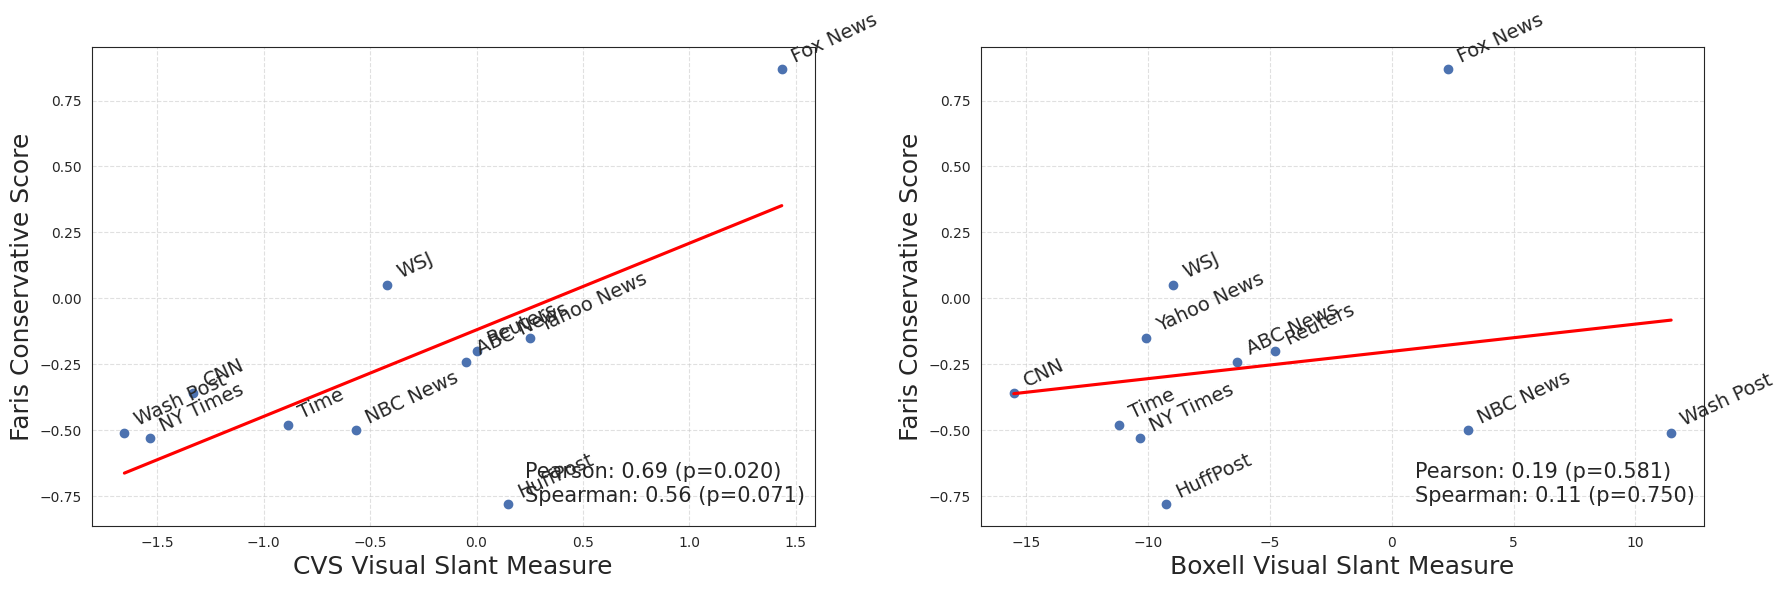

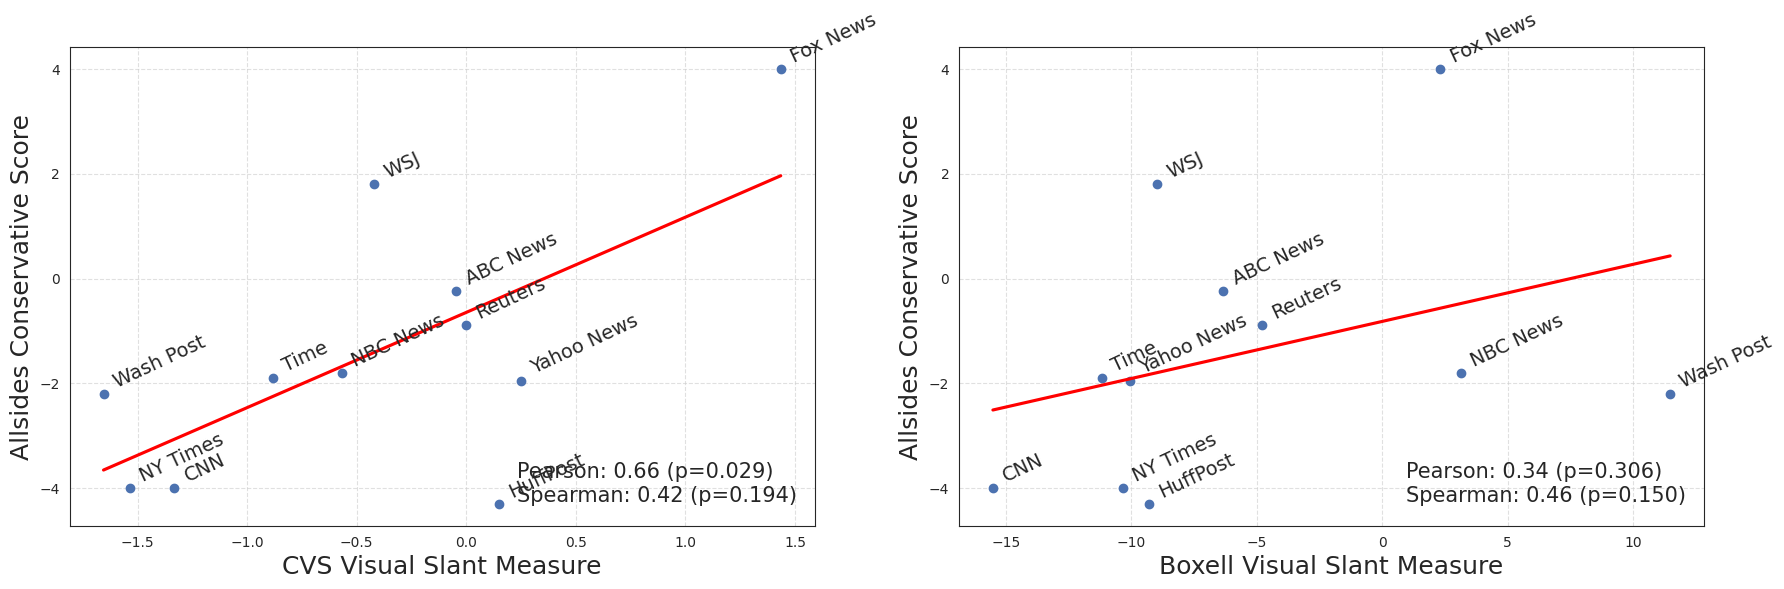

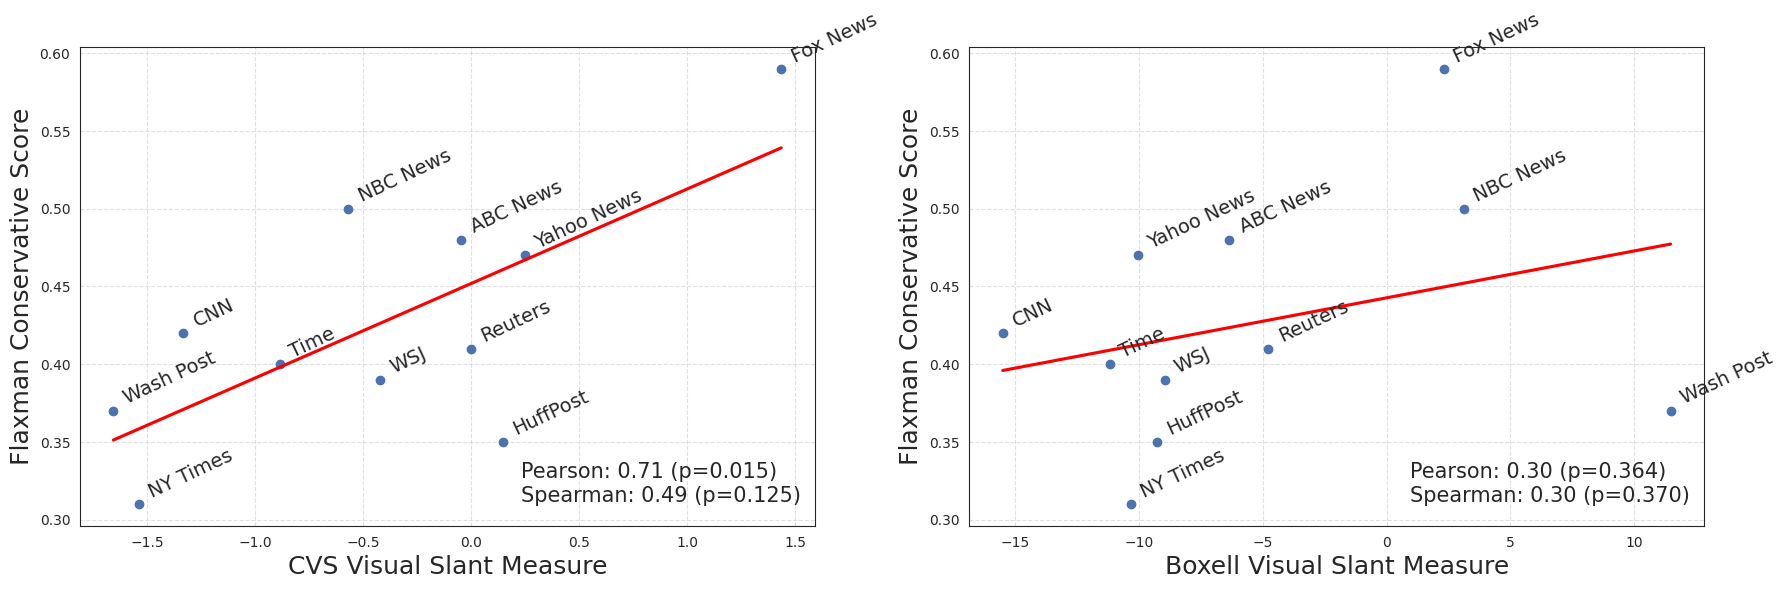

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from scipy.stats import spearmanr, pearsonr
import seaborn as sns
import os

df = pd.read_csv('Final_CSV_For_Analysis.csv').copy()

plt.style.use('default')
sns.set_style("white")

news_center_affiliations = {
    'www.bbc.com': 'Democratic', 'www.nytimes.com': 'Democratic', 'www.huffpost.com': 'Democratic',
    'www.washingtonpost.com': 'Democratic', 'www.wsj.com': 'Republican', 'www.cnn.com': 'Democratic',
    'www.cbsnews.com': 'Democratic', 'www.latimes.com': 'Neutral', 'www.dailymail.co.uk': 'Republican',
    'abcnews.go.com': 'Democratic', 'www.nbcnews.com': 'Democratic', 'www.foxnews.com': 'Republican',
    'www.newsmax.com': 'Republican', 'www.usnews.com': 'Neutral', 'time.com': 'Democratic',
    'www.reuters.com': 'Neutral', 'news.yahoo.com': 'Neutral', 'www.usatoday.com': 'Neutral',
    'www.cnbc.com': 'Democratic', 'www.csmonitor.com': 'Neutral'
}

short_names = {
    'www.bbc.com': 'BBC', 'www.nytimes.com': 'NY Times', 'www.huffpost.com': 'HuffPost',
    'www.washingtonpost.com': 'Wash Post', 'www.wsj.com': 'WSJ', 'www.cnn.com': 'CNN',
    'www.cbsnews.com': 'CBS News', 'www.latimes.com': 'LA Times', 'www.dailymail.co.uk': 'Daily Mail',
    'abcnews.go.com': 'ABC News', 'www.nbcnews.com': 'NBC News', 'www.foxnews.com': 'Fox News',
    'www.newsmax.com': 'Newsmax', 'www.usnews.com': 'US News', 'time.com': 'Time',
    'www.reuters.com': 'Reuters', 'news.yahoo.com': 'Yahoo News', 'www.usatoday.com': 'USA Today',
    'www.cnbc.com': 'CNBC', 'www.csmonitor.com': 'CS Monitor'
}

selected_news_centers = list(news_center_affiliations.keys())

mean_smile_effect = {
    'News Center': [],
    'Republican Politicians': [],
    'Democratic Politicians': []
}

for news_center in selected_news_centers:
    smile_column = f"Final_Ratio_{news_center}"
    if smile_column in df.columns:
        republican_mean_effect = df[(df['Real Person Side'] == 'Republican')][smile_column].mean()
        democratic_mean_effect = df[(df['Real Person Side'] == 'Democratic')][smile_column].mean()
        mean_smile_effect['News Center'].append(news_center)
        mean_smile_effect['Republican Politicians'].append(republican_mean_effect if not np.isnan(republican_mean_effect) else 0)
        mean_smile_effect['Democratic Politicians'].append(democratic_mean_effect if not np.isnan(democratic_mean_effect) else 0)

mean_smile_effect_df = pd.DataFrame(mean_smile_effect)
mean_smile_effect_df['Overall Polarization'] = (mean_smile_effect_df['Republican Politicians'] - mean_smile_effect_df['Democratic Politicians'])
mean_smile_effect_df = mean_smile_effect_df.sort_values(by='Overall Polarization', ascending=True)

Boxell = {'www.bbc.com': None, 'www.nytimes.com': -10.341, 'www.huffpost.com': -9.280, 'www.washingtonpost.com': 11.470,
          'www.wsj.com': -8.970, 'www.usnews.com': None, 'time.com': -11.174, 'www.reuters.com': -4.778,
          'www.cnn.com': -15.510, 'www.cbsnews.com': None, 'www.latimes.com': None, 'news.yahoo.com': -10.064,
          'www.usatoday.com': None, 'www.dailymail.co.uk': None, 'www.cnbc.com': None, 'www.csmonitor.com': None,
          'abcnews.go.com': -6.359, 'www.nbcnews.com': 3.126, 'www.foxnews.com': 2.320, 'www.newsmax.com': None}
valid_outlets = {k for k, v in Boxell.items() if v is not None}
mean_smile_effect_df = mean_smile_effect_df[mean_smile_effect_df['News Center'].isin(valid_outlets)]

harvard = {'www.bbc.com': -0.31, 'www.nytimes.com': -0.53, 'www.huffpost.com': -0.78, 'www.washingtonpost.com': -0.51,
           'www.wsj.com': 0.05, 'www.usnews.com': -0.20, 'time.com': -0.48, 'www.reuters.com': -0.20, 'www.cnn.com': -0.36,
           'www.cbsnews.com': -0.31, 'www.latimes.com': -0.39, 'news.yahoo.com': -0.15, 'www.usatoday.com': -0.19,
           'www.dailymail.co.uk': 0.71, 'www.cnbc.com': 0.12, 'www.csmonitor.com': -0.07, 'abcnews.go.com': -0.24,
           'www.nbcnews.com': -0.50, 'www.foxnews.com': 0.87, 'www.newsmax.com': 0.9}

allsides = {'www.bbc.com': -0.8, 'www.nytimes.com': -4, 'www.huffpost.com': -4.3, 'www.washingtonpost.com': -2.2,
            'www.wsj.com': 1.8, 'time.com': -1.9, 'www.reuters.com': -0.89, 'www.cnn.com': -4, 'www.cbsnews.com': -1.5,
            'news.yahoo.com': -1.95, 'www.usatoday.com': -2, 'www.dailymail.co.uk': 4, 'www.cnbc.com': -0.9,
            'www.csmonitor.com': -0.3, 'abcnews.go.com': -0.24, 'www.nbcnews.com': -1.8, 'www.foxnews.com': 4,
            'www.newsmax.com': 3.5}

other_paper = {'www.bbc.com': 0.30, 'www.nytimes.com': 0.31, 'www.huffpost.com': 0.35, 'www.washingtonpost.com': 0.37,
               'www.wsj.com': 0.39, 'www.usnews.com': 0.39, 'time.com': 0.40, 'www.reuters.com': 0.41, 'www.cnn.com': 0.42,
               'www.cbsnews.com': 0.45, 'www.latimes.com': 0.46, 'news.yahoo.com': 0.47, 'www.usatoday.com': 0.47,
               'www.dailymail.co.uk': 0.47, 'www.cnbc.com': 0.48, 'www.csmonitor.com': 0.47, 'abcnews.go.com': 0.48,
               'www.nbcnews.com': 0.50, 'www.foxnews.com': 0.59, 'www.newsmax.com': 0.61}

datasets = {
    'Faris Conservative Score': harvard,
    'Allsides Conservative Score': allsides,
    'Flaxman Conservative Score': other_paper
}

output_dir = "conservative_share_plots"
os.makedirs(output_dir, exist_ok=True)

x_datasets = ['Faris Conservative Score', 'Allsides Conservative Score', 'Flaxman Conservative Score']
y_datasets = ['CVS', 'Boxell']

for i, x_data in enumerate(x_datasets):
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    for j, y_data in enumerate(y_datasets):
        ax = axes[j]
        y_values = datasets[x_data]
        x_values = mean_smile_effect_df.set_index('News Center')['Overall Polarization'].to_dict() if y_data == 'CVS' else Boxell
        common_keys = valid_outlets & set(y_values.keys())
        x_vals = [x_values[k] for k in common_keys if x_values[k] is not None and y_values[k] is not None]
        y_vals = [y_values[k] for k in common_keys if x_values[k] is not None and y_values[k] is not None]
        labels = [short_names[k] for k in common_keys if x_values[k] is not None and y_values[k] is not None]
        ax.scatter(x_vals, y_vals, color='b')
        if len(x_vals) > 1:
            sns.regplot(x=x_vals, y=y_vals, scatter=False, ax=ax, color='red', ci=None)
        for label, x, y in zip(labels, x_vals, y_vals):
            ax.annotate(label, (x, y), fontsize=14, xytext=(5, 5), textcoords='offset points', rotation=25)
        if len(x_vals) > 1:
            pearson_corr, pearson_pval = pearsonr(x_vals, y_vals)
            spearman_corr, spearman_pval = spearmanr(x_vals, y_vals)
        else:
            pearson_corr, pearson_pval = (np.nan, np.nan)
            spearman_corr, spearman_pval = (np.nan, np.nan)
        ax.annotate(f'Pearson: {pearson_corr:.2f} (p={pearson_pval:.3f})', xy=(0.6, 0.1), xycoords='axes fraction', fontsize=15)
        ax.annotate(f'Spearman: {spearman_corr:.2f} (p={spearman_pval:.3f})', xy=(0.6, 0.05), xycoords='axes fraction', fontsize=15)
        ax.set_xlabel(f"{y_data} Visual Slant Measure", fontsize=18)
        ax.set_ylabel(f"{x_data}", fontsize=18)
        ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plot_filename = os.path.join(output_dir, f"{x_data}_comparison.png")
    plt.savefig(plot_filename)
    plt.show()
    plt.close()

### Figures 14


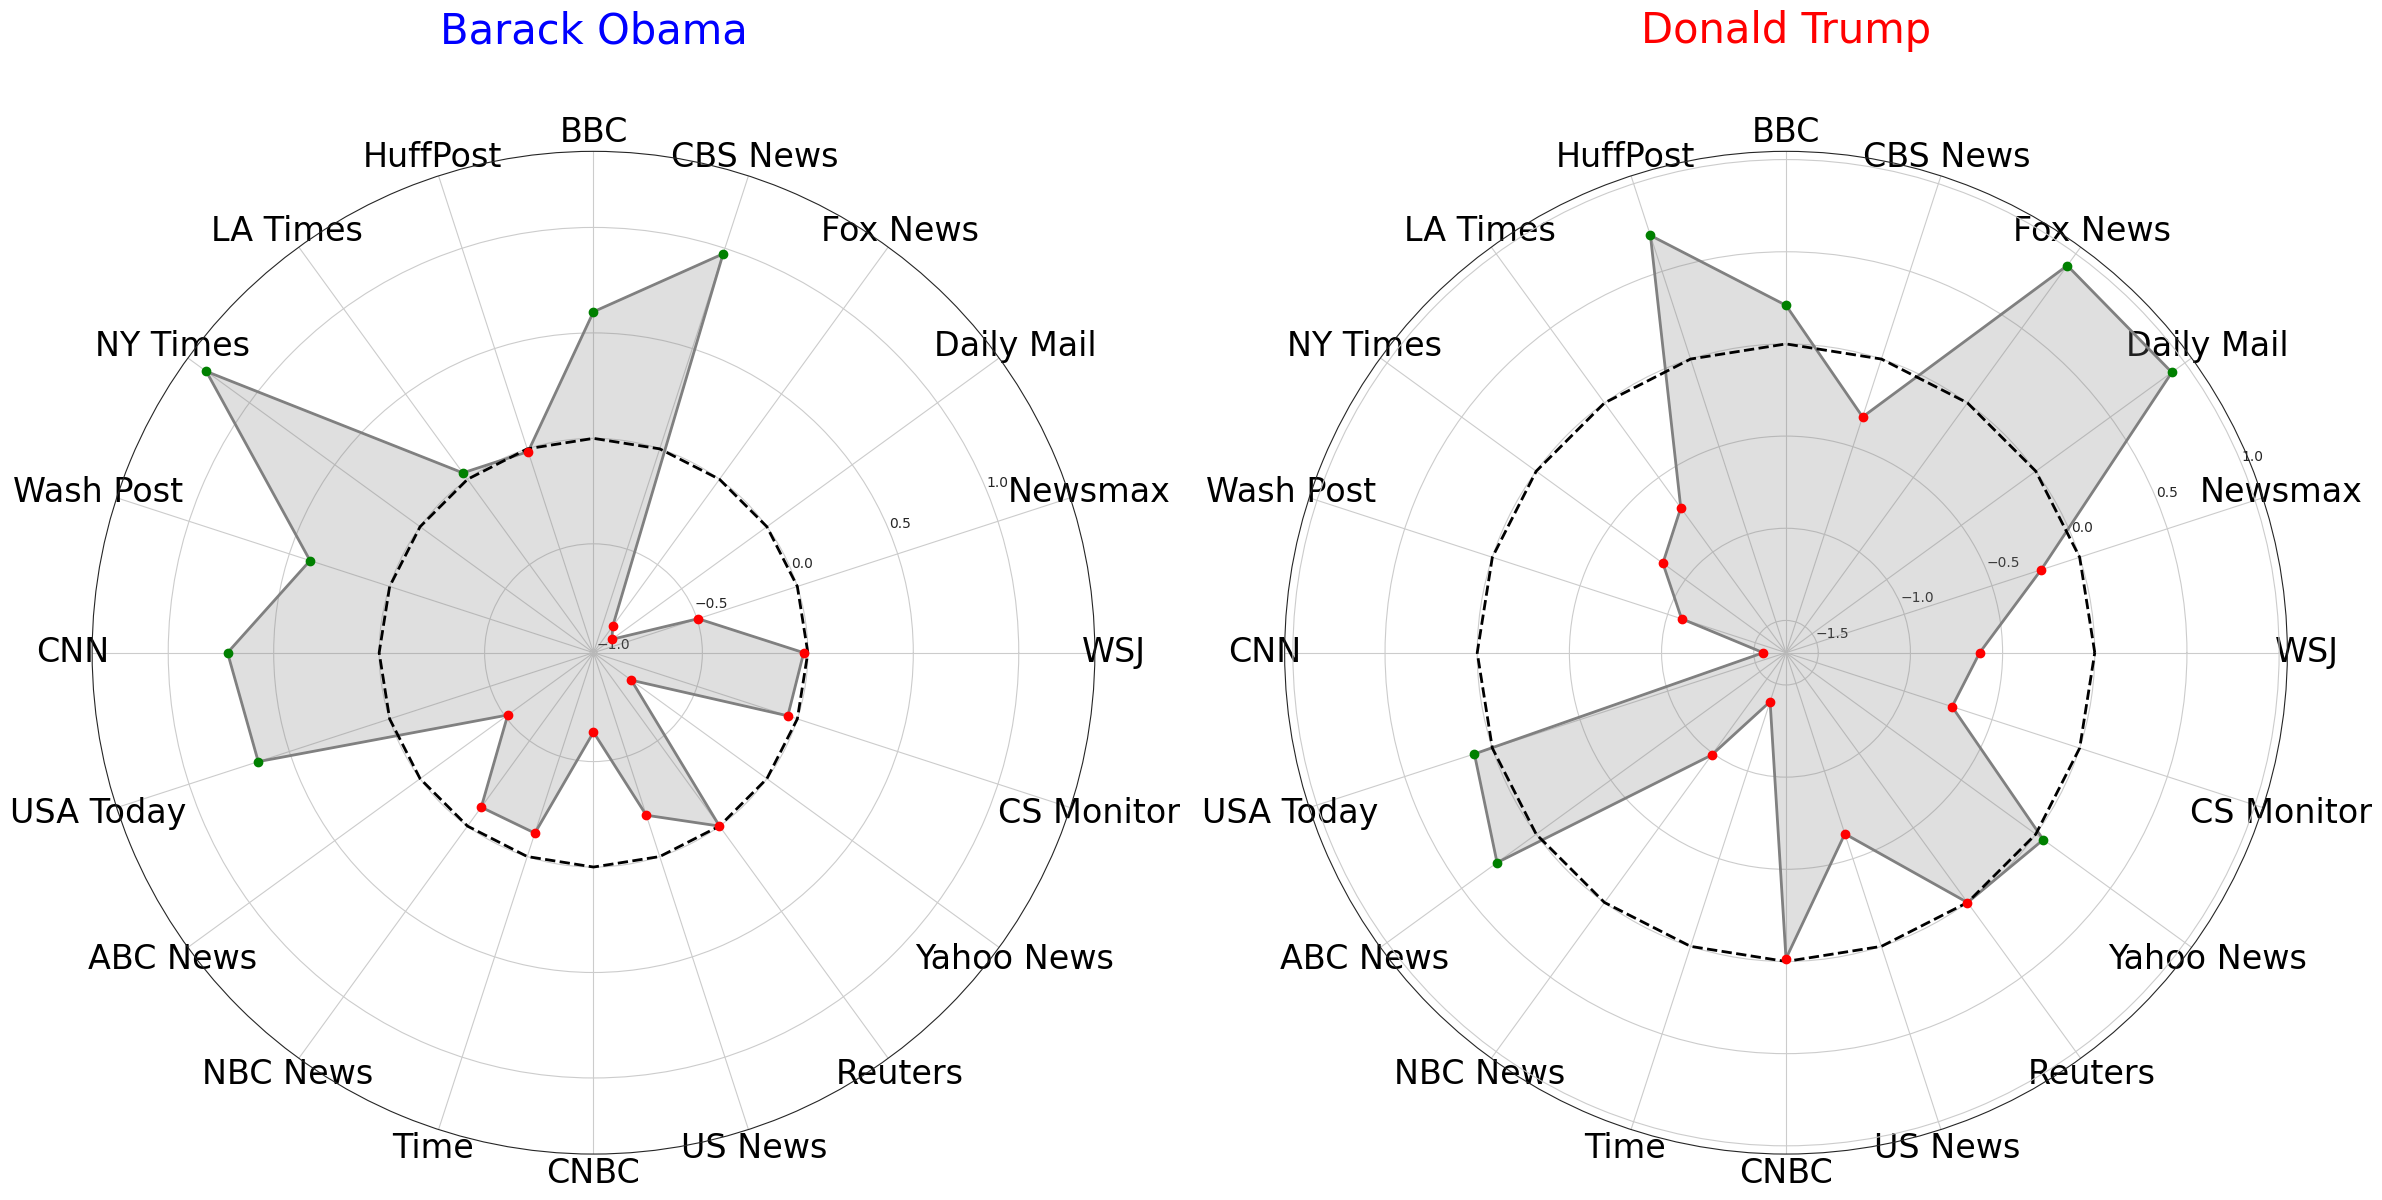

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('Final_CSV_For_Analysis.csv')

news_center_affiliations = {
    'www.wsj.com': 'Republican', 'www.newsmax.com': 'Republican', 'www.dailymail.co.uk': 'Republican', 'www.foxnews.com': 'Republican',
    'www.cbsnews.com': 'Democratic', 'www.bbc.com': 'Democratic', 'www.huffpost.com': 'Democratic','www.latimes.com': 'Neutral',
    'www.nytimes.com': 'Democratic', 'www.washingtonpost.com': 'Democratic', 'www.cnn.com': 'Democratic',
    'www.usatoday.com': 'Neutral', 'abcnews.go.com': 'Democratic', 'www.nbcnews.com': 'Democratic', 'time.com': 'Democratic',
    'www.cnbc.com': 'Democratic', 'www.usnews.com': 'Neutral',
    'www.reuters.com': 'Neutral', 'news.yahoo.com': 'Neutral',
    'www.csmonitor.com': 'Neutral'
}

short_names = {
    'www.bbc.com': 'BBC', 'www.nytimes.com': 'NY Times', 'www.huffpost.com': 'HuffPost',
    'www.washingtonpost.com': 'Wash Post', 'www.wsj.com': 'WSJ', 'www.cnn.com': 'CNN',
    'www.cbsnews.com': 'CBS News', 'www.latimes.com': 'LA Times', 'www.dailymail.co.uk': 'Daily Mail',
    'abcnews.go.com': 'ABC News', 'www.nbcnews.com': 'NBC News', 'www.foxnews.com': 'Fox News',
    'www.newsmax.com': 'Newsmax', 'www.usnews.com': 'US News', 'time.com': 'Time',
    'www.reuters.com': 'Reuters', 'news.yahoo.com': 'Yahoo News', 'www.usatoday.com': 'USA Today',
    'www.cnbc.com': 'CNBC', 'www.csmonitor.com': 'CS Monitor'
}

politician_affiliations = {
    'Joe Biden': 'Democratic', 'Donald Trump': 'Republican', 'Kamala Harris': 'Democratic',
    'Mitch Mcconnell': 'Republican', 'Nancy Pelosi': 'Democratic', 'Mike Pence': 'Republican',
    'Barack Obama': 'Democratic', 'Hillary Clinton': 'Democratic', 'Kevin McCarthy': 'Republican',
    'Liz Cheney': 'Republican', 'Chuck Schumer': 'Democratic', 'Hal Rogers': 'Republican',
    'Mitt Romney': 'Republican', 'Elizabeth Warren': 'Democratic', 'John Roberts': 'Republican',
    'Bernie Sanders': 'Democratic', 'Joe Manchin': 'Democratic', 'Cory Booker': 'Democratic',
    'Ted Cruz': 'Republican', 'Gavin Newsom': 'Democratic', 'Rand Paul': 'Republican',
    'Marco Rubio': 'Republican', 'Amy Klobuchar': 'Democratic', 'Susan Collins': 'Republican',
    'Bill de Blasio': 'Democratic', 'Janet Yellen': 'Democratic', 'Steny Hoyer': 'Democratic',
    'James Clyburn': 'Democratic', 'Randy Biggs': 'Republican', 'Greg Abbott': 'Republican'
}

selected_news_centers = list(news_center_affiliations.keys())
politicians = ['Barack Obama', 'Donald Trump']

fig, axs = plt.subplots(1, 2, figsize=(24, 14), subplot_kw=dict(polar=True))

for ax, politician in zip(axs.flat, politicians):
    mean_smile_effect = {'News Center': [], 'Smile Effect': []}
    person_column = 'Political Person' if politician == 'Mitt Romney' else 'Top1_Person'
    for news_center in selected_news_centers:
        smile_column = f"Final_Ratio_{news_center}"
        if smile_column in df.columns:
            df_news_center = df[(df[person_column] == politician)]
            mean_effect = df_news_center[smile_column].mean() if not df_news_center.empty else 0
            mean_smile_effect['News Center'].append(short_names[news_center])
            mean_smile_effect['Smile Effect'].append(mean_effect if not np.isnan(mean_effect) else 0)
    mean_smile_effect_df = pd.DataFrame(mean_smile_effect)
    labels = mean_smile_effect_df['News Center']
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]
    values = mean_smile_effect_df['Smile Effect'].tolist()
    values += values[:1]
    ax.plot(angles, values, color='gray', linewidth=2, linestyle='solid', label=politician)
    ax.fill(angles, values, color='gray', alpha=0.25)
    ax.plot(angles, [0] * len(angles), color='black', linewidth=2, linestyle='--')
    for i in range(len(values) - 1):
        color = 'green' if values[i] > 0 else 'red'
        ax.plot(angles[i], values[i], marker='o', color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=24)
    for label, angle in zip(ax.get_xticklabels(), angles):
        news_center = label.get_text()
        affiliation = news_center_affiliations.get(news_center, 'Neutral')
        color = 'blue' if affiliation == 'Democratic' else 'red' if affiliation == 'Republican' else 'black'
        label.set_color(color)
    title_color = 'red' if politician_affiliations[politician] == 'Republican' else 'blue'
    ax.set_title(f'{politician}', size=30, color=title_color, y=1.1)

plt.tight_layout()
#plt.savefig('Fig_Politicans_Radar2.png', dpi=70)
plt.show()

## Construction of Overall Visual Polarization (OVP)

We compute **Overall Visual Polarization (OVP)** using an outlet‐dispersion measure based on **cross-fitted predictions** from two independently trained outlet-prediction models. For each article and each counterfactual image, we measure outlet-level dispersion as the square root of the cross-covariance between predicted outlet likelihoods from the two models, thereby isolating systematic visual variation while mitigating overfitting. We then aggregate this dispersion across images within an article and average across articles associated with a given politician to obtain politician-level OVP.

The two outlet-prediction models are trained on disjoint samples, and their architectures, training procedures, and predictive performance are documented in `Git_Cross-Fitting.ipynb`. OVP is computed exclusively from out-of-sample predictions and does not reuse training data from either model.

Detected image indices: ['1', '2', '3']

POLARIZATION BY POLITICIAN (BASED ON IMAGES, THEN AVERAGED)

         Top1_Person  Overall_Polarization  n_articles
6       Donald Trump              0.490082        1932
1       Barack Obama              0.474185        1138
2     Bernie Sanders              0.457181         411
12         Joe Biden              0.410282         771
18       Marco Rubio              0.380723         276
10   Hillary Clinton              0.359065         903
20   Mitch Mcconnell              0.284385         373
4      Chuck Schumer              0.251213         221
16    Kevin McCarthy              0.238666          95
23         Rand Paul              0.191021         250
9        Greg Abbott              0.190953          54
14      John Roberts              0.185375          46
0      Amy Klobuchar              0.179449         102
21       Mitt Romney              0.176835         289
7   Elizabeth Warren              0.175189         378
8       Gavin News

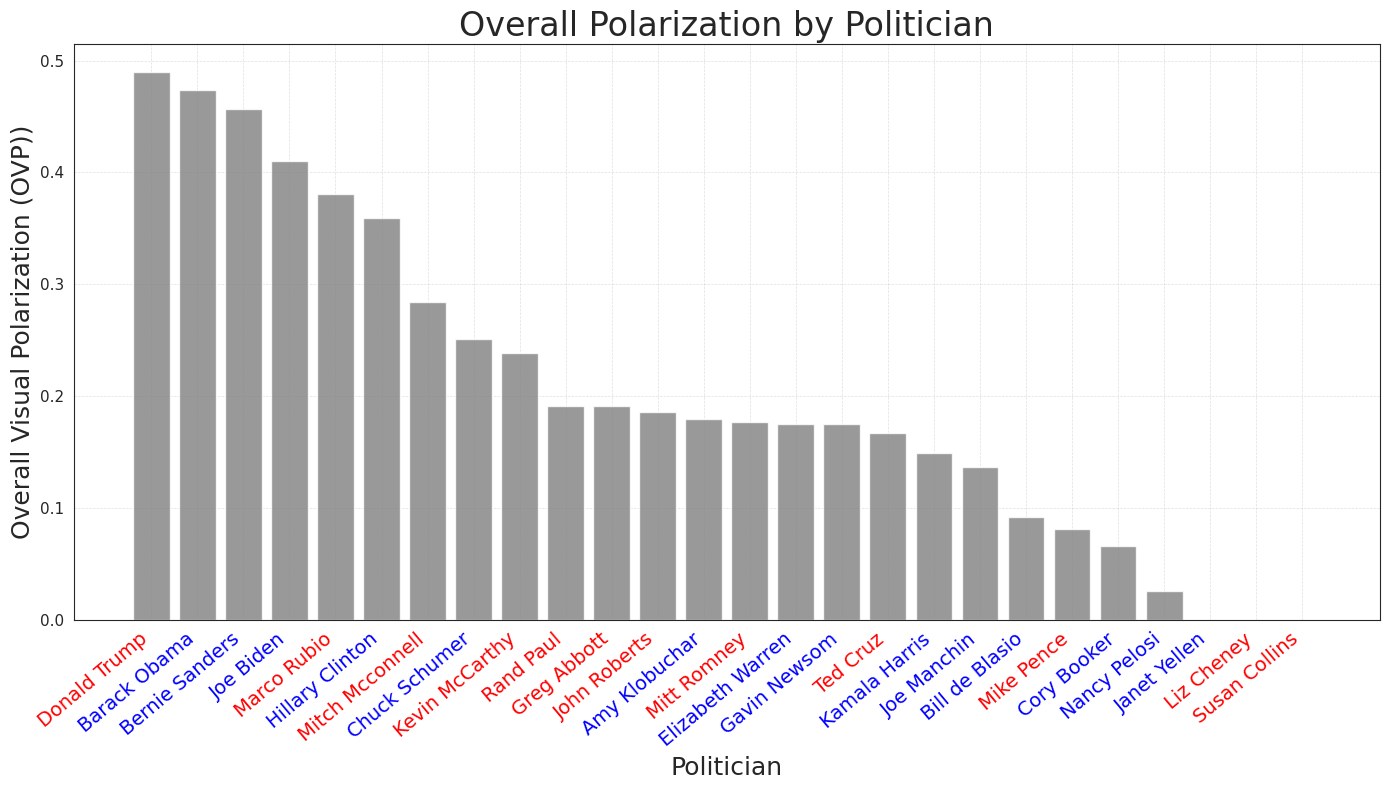

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)


CSV_MODEL1 = "Final_CSV_For_Analysis_Model_1.csv"
CSV_MODEL2 = "Final_CSV_For_Analysis_Model_2.csv"


df1 = pd.read_csv(CSV_MODEL1).copy()
df2 = pd.read_csv(CSV_MODEL2).copy()

if len(df1) != len(df2):
    raise ValueError(
        f"Row count mismatch: df1={len(df1)} vs df2={len(df2)}. "
        "If you have an ID column, align by merge instead of index."
    )

news_center_affiliations = {
    "www.bbc.com": "Democratic", "www.nytimes.com": "Democratic", "www.huffpost.com": "Democratic",
    "www.washingtonpost.com": "Democratic", "www.wsj.com": "Republican", "www.cnn.com": "Democratic",
    "www.cbsnews.com": "Democratic", "www.latimes.com": "Neutral", "www.dailymail.co.uk": "Republican",
    "abcnews.go.com": "Democratic", "www.nbcnews.com": "Democratic", "www.foxnews.com": "Republican",
    "www.newsmax.com": "Republican", "www.usnews.com": "Neutral", "time.com": "Democratic",
    "www.reuters.com": "Neutral", "news.yahoo.com": "Neutral", "www.usatoday.com": "Neutral",
    "www.cnbc.com": "Democratic", "www.csmonitor.com": "Neutral"
}

politician_affiliations = {
    "Joe Biden": "Democratic", "Donald Trump": "Republican", "Kamala Harris": "Democratic",
    "Mitch Mcconnell": "Republican", "Nancy Pelosi": "Democratic", "Mike Pence": "Republican",
    "Barack Obama": "Democratic", "Hillary Clinton": "Democratic", "Kevin McCarthy": "Republican",
    "Liz Cheney": "Republican", "Chuck Schumer": "Democratic", "Mitt Romney": "Republican",
    "Elizabeth Warren": "Democratic", "John Roberts": "Republican", "Bernie Sanders": "Democratic",
    "Joe Manchin": "Democratic", "Cory Booker": "Democratic", "Ted Cruz": "Republican",
    "Gavin Newsom": "Democratic", "Rand Paul": "Republican", "Marco Rubio": "Republican",
    "Amy Klobuchar": "Democratic", "Susan Collins": "Republican", "Bill de Blasio": "Democratic",
    "Janet Yellen": "Democratic", "Steny Hoyer": "Democratic", "Greg Abbott": "Republican"
}

selected_news_centers = list(news_center_affiliations.keys())

df1 = df1[df1["Top1_Person"].isin(politician_affiliations.keys())].copy()
df2 = df2.loc[df1.index].copy()

ratio_cols_all_m1 = [c for c in df1.columns if c.startswith("Ratio_")]
ratio_cols_all_m2 = [c for c in df2.columns if c.startswith("Ratio_")]

def extract_image_index(col_name: str) -> str:
    parts = col_name.split("_", 2)
    if len(parts) < 3:
        return None
    return parts[1]

image_indices = sorted(
    {idx for idx in (extract_image_index(c) for c in ratio_cols_all_m1) if idx is not None},
    key=lambda x: int(x)
)

print("Detected image indices:", image_indices)

ratio_outlet_cols_m1 = {k: {} for k in image_indices}
ratio_outlet_cols_m2 = {k: {} for k in image_indices}

for k in image_indices:
    for outlet in selected_news_centers:
        prefix = f"Ratio_{k}_{outlet}"
        cand1 = [c for c in ratio_cols_all_m1 if c.startswith(prefix)]
        cand2 = [c for c in ratio_cols_all_m2 if c.startswith(prefix)]
        if cand1 and cand2:
            ratio_outlet_cols_m1[k][outlet] = sorted(cand1)[0]
            ratio_outlet_cols_m2[k][outlet] = sorted(cand2)[0]

def gs_outlet_var_for_row_image(idx: int, k: str) -> float:
    vals1, vals2 = [], []
    for outlet in selected_news_centers:
        col1 = ratio_outlet_cols_m1[k].get(outlet)
        col2 = ratio_outlet_cols_m2[k].get(outlet)
        if col1 is None or col2 is None:
            continue
        v1 = df1.at[idx, col1]
        v2 = df2.at[idx, col2]
        if pd.isna(v1) or pd.isna(v2):
            continue
        vals1.append(float(v1))
        vals2.append(float(v2))
    if len(vals1) <= 1:
        return np.nan
    vals1 = np.asarray(vals1, dtype=float)
    vals2 = np.asarray(vals2, dtype=float)
    mu1 = vals1.mean()
    mu2 = vals2.mean()
    cross_mean = ((vals1 - mu1) * (vals2 - mu2)).mean()
    return np.sqrt(max(cross_mean, 0.0))

for k in image_indices:
    col_name = f"image_{k}_outlet_var"
    df1[col_name] = [gs_outlet_var_for_row_image(idx, k) for idx in df1.index]

def article_var_from_images(row) -> float:
    vals = []
    for k in image_indices:
        v = row[f"image_{k}_outlet_var"]
        if pd.notna(v):
            vals.append(float(v))
    if not vals:
        return np.nan
    return float(np.mean(vals))

df1["article_outlet_var_from_images"] = df1.apply(article_var_from_images, axis=1)

pol_by_person = (
    df1.groupby("Top1_Person", as_index=False)
       .agg(
           Overall_Polarization=("article_outlet_var_from_images", "mean"),
           n_articles=("article_outlet_var_from_images", "count"),
       )
)

pol_by_person = pol_by_person.dropna(subset=["Overall_Polarization"])
pol_by_person = pol_by_person.sort_values("Overall_Polarization", ascending=False)

print("\n==============================================")
print("POLARIZATION BY POLITICIAN (BASED ON IMAGES, THEN AVERAGED)")
print("==============================================\n")
print(pol_by_person)

fig, ax = plt.subplots(figsize=(14, 8))

ax.bar(
    pol_by_person["Top1_Person"],
    pol_by_person["Overall_Polarization"],
    color="gray",
    alpha=0.8,
)

for tick, politician in zip(ax.get_xticklabels(), pol_by_person["Top1_Person"]):
    affiliation = politician_affiliations.get(politician, "Neutral")
    color = "blue" if affiliation == "Democratic" else "red" if affiliation == "Republican" else "black"
    tick.set_color(color)

ax.set_title("Overall Polarization by Politician", fontsize=24)
ax.set_xlabel("Politician", fontsize=18)
ax.set_ylabel("Overall Visual Polarization (OVP))", fontsize=18)
plt.xticks(rotation=40, ha="right", fontsize=14)
plt.yticks(fontsize=11)
ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.savefig("Fig_smile_effect_BarPlot_Politician_ImageBased_GS_Mean.png", dpi=70)
plt.show()

## Verbal Polarization (External Validation)

For external validation, we construct a politician-level measure of **verbal ideological polarization** using campaign-finance–based ideology scores from the DIME dataset, as developed by **Gentzkow et al. (2019)**. We match each politician in our sample to DIME recipients and compute the average CFscore over election cycles 2012–2022. These CFscores provide a well-established, text-based proxy for ideological positioning derived from political speech and contributions. We use this verbal polarization measure exclusively to validate our image-based **OVP** and do not incorporate it into the construction of OVP itself.

In [12]:
import pandas as pd
import numpy as np
import re

DIME_RECIPIENTS_CSV = "dime_recipients_1979_2024.csv"
dime = pd.read_csv(DIME_RECIPIENTS_CSV, low_memory=False)

print(f"Loaded DIME file with {len(dime):,} rows")

cf_col = "recipient.cfscore"
year_col = "cycle"
lname_col = "lname"
fname_col = "fname"
ffname_col = "ffname"

for c in [cf_col, year_col, lname_col, fname_col]:
    if c not in dime.columns:
        raise RuntimeError(f"Missing column {c}. Found columns: {list(dime.columns)[:40]}")

politicians = [
    "Joe Biden","Donald Trump","Kamala Harris","Mitch Mcconnell","Nancy Pelosi",
    "Mike Pence","Barack Obama","Hillary Clinton","Kevin McCarthy","Liz Cheney",
    "Chuck Schumer","Mitt Romney","Elizabeth Warren","John Roberts","Bernie Sanders",
    "Joe Manchin","Cory Booker","Ted Cruz","Gavin Newsom","Rand Paul","Marco Rubio",
    "Amy Klobuchar","Susan Collins","Bill de Blasio","Janet Yellen","Steny Hoyer",
    "Greg Abbott"
]

pol_df = pd.DataFrame({"Politician": politicians})

def norm_token(x):
    return re.sub(r"[^a-z]", "", str(x).lower().strip())

FIRST_VARIANTS = {
    "joe": {"joe", "joseph"},
    "chuck": {"chuck", "charles"},
    "mitch": {"mitch", "addison"},
    "mike": {"mike", "michael"},
    "bill": {"bill", "william"},
    "mitt": {"mitt", "willard"},
    "ted": {"ted", "theodore", "rafael"},
    "kamala": {"kamala"},
    "nancy": {"nancy"},
    "barack": {"barack"},
    "hillary": {"hillary", "hilary"},
    "liz": {"liz", "elizabeth"},
    "cory": {"cory", "cori"},
    "rand": {"rand", "randle"},
    "marco": {"marco"},
    "amy": {"amy"},
    "susan": {"susan"},
    "steny": {"steny"},
    "gavin": {"gavin"},
    "greg": {"greg", "gregory"},
    "donald": {"donald"},
    "bernie": {"bernie", "bernard"},
    "janet": {"janet"},
    "john": {"john"},
    "kevin": {"kevin"},
    "elizabeth": {"elizabeth"},
}

particles = {"de", "del", "da", "di", "van", "von", "la", "le", "du"}

def split_name(full):
    parts = full.strip().split()
    first = parts[0]
    if len(parts) >= 2 and parts[-2].lower() in particles:
        last = " ".join(parts[-2:])
    else:
        last = parts[-1]
    return norm_token(first), norm_token(last)

pol_df["first_norm"], pol_df["last_norm"] = zip(*pol_df["Politician"].map(split_name))

dime["last_norm"] = dime[lname_col].map(norm_token)

dime_first_raw = dime[fname_col].astype(str)
if ffname_col in dime.columns:
    dime_first_raw = dime_first_raw.where(
        dime_first_raw.notna() & (dime_first_raw != "nan"),
        dime[ffname_col].astype(str)
    )
dime["first_norm"] = dime_first_raw.map(norm_token)

START_CYCLE = 2012
END_CYCLE = 2022

rows = []
for _, r in pol_df.iterrows():
    pol = r["Politician"]
    f = r["first_norm"]
    l = r["last_norm"]

    allowed_first = FIRST_VARIANTS.get(f, {f})

    cand = dime[(dime["last_norm"] == l) & (dime["first_norm"].isin(allowed_first))].copy()
    cand = cand.dropna(subset=[cf_col])
    cand = cand[(cand[year_col] >= START_CYCLE) & (cand[year_col] <= END_CYCLE)]

    if cand.empty:
        rows.append({
            "Politician": pol,
            "Matched": False,
            "CFscore_avg_2012_2022": np.nan,
            "cycle_min": np.nan,
            "cycle_max": np.nan,
            "n_cycles": 0
        })
        continue

    cf_avg = float(cand[cf_col].mean())
    cand = cand.sort_values(year_col)
    best = cand.iloc[-1]

    rows.append({
        "Politician": pol,
        "Matched": True,
        "CFscore_avg_2012_2022": cf_avg,
        "cycle_min": int(cand[year_col].min()),
        "cycle_max": int(cand[year_col].max()),
        "n_cycles": int(cand[year_col].nunique()),
        "party": best.get("party", np.nan),
        "state": best.get("state", np.nan),
        "seat": best.get("seat", np.nan),
        "district": best.get("district", np.nan),
        "bonica.rid": best.get("bonica.rid", np.nan),
        "bonica.cid": best.get("bonica.cid", np.nan),
        "name_in_dime": best.get("name", np.nan),
    })

out = pd.DataFrame(rows)

print("\nMatches:")
print(out.sort_values(["Matched", "Politician"], ascending=[False, True]).to_string(index=False))

print("\nUnmatched:")
print(out.loc[~out["Matched"], "Politician"].tolist())

Loaded DIME file with 479,502 rows

Matches:
      Politician  Matched  CFscore_avg_2012_2022  cycle_min  cycle_max  n_cycles party state              seat district        bonica.rid   bonica.cid                                  name_in_dime
   Amy Klobuchar     True              -0.905571     2012.0     2022.0         6   100    MN    federal:senate    MNS24          cand1581 5.000004e+15                                klobuchar, amy
    Barack Obama     True              -1.095000     2012.0     2016.0         3   100    00 federal:president     PRES        cand169967 5.472873e+09                                 obama, barack
  Bernie Sanders     True              -1.155273     2012.0     2022.0         6   100    00 federal:president     PRES          cand1235 2.494767e+09                              sanders, bernard
  Bill de Blasio     True              -0.567833     2012.0     2022.0         4   100    00 federal:president     PRES        cand149311          NaN                 

## Validation of OVP

We validate our image-based measure of **OVP** by comparing it to an independent, speech-based measure of ideological polarization at the politician level. For each article, we compute outlet-level dispersion in predicted outlet likelihoods across counterfactual images and aggregate this variation to the article level and then to the politician level. This yields a politician-specific OVP score based solely on visual content.

We then correlate politician-level OVP with an externally constructed measure of verbal ideology derived from campaign-finance–based CFscores. Validation proceeds using both Pearson correlations, which capture linear association, and Spearman rank correlations, which assess monotonic alignment. This exercise evaluates whether politicians who are more ideologically extreme in speech and contributions also exhibit systematically higher visual polarization in news imagery, providing external support for the construct validity of OVP.

Detected image indices: ['1', '2', '3']

POLARIZATION BY POLITICIAN (BASED ON IMAGES, THEN AVERAGED)

         Top1_Person  Overall_Polarization  n_articles
6       Donald Trump              0.490082        1932
1       Barack Obama              0.474185        1138
2     Bernie Sanders              0.457181         411
12         Joe Biden              0.410282         771
18       Marco Rubio              0.380723         276
10   Hillary Clinton              0.359065         903
20   Mitch Mcconnell              0.284385         373
4      Chuck Schumer              0.251213         221
16    Kevin McCarthy              0.238666          95
23         Rand Paul              0.191021         250
9        Greg Abbott              0.190953          54
14      John Roberts              0.185375          46
0      Amy Klobuchar              0.179449         102
21       Mitt Romney              0.176835         289
7   Elizabeth Warren              0.175189         378
8       Gavin News

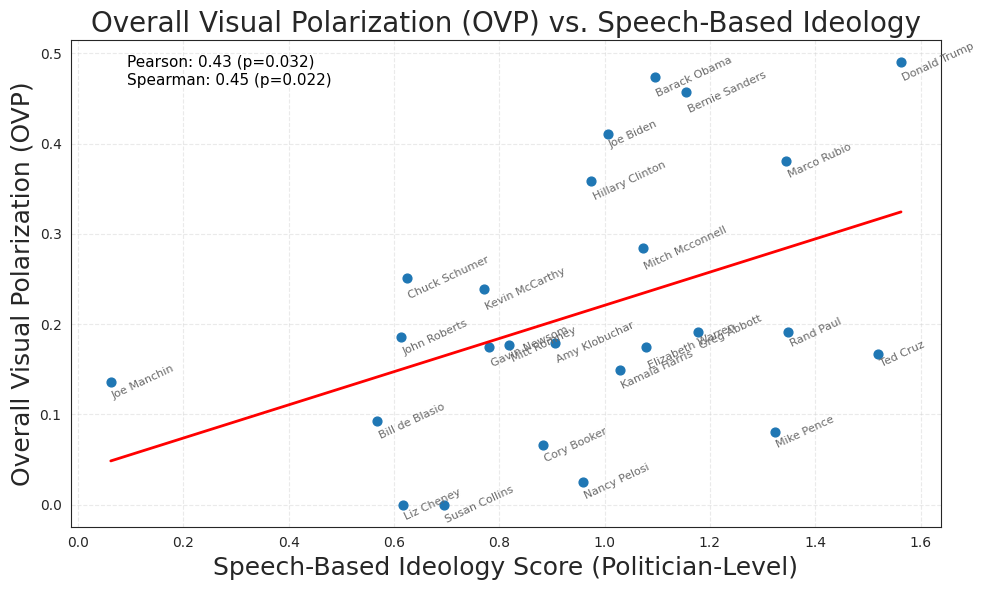

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)


CSV_MODEL1 = "Final_CSV_For_Analysis_Model_1.csv"
CSV_MODEL2 = "Final_CSV_For_Analysis_Model_2.csv"

df1 = pd.read_csv(CSV_MODEL1).copy()
df2 = pd.read_csv(CSV_MODEL2).copy()

if len(df1) != len(df2):
    raise ValueError(
        f"Row count mismatch: df1={len(df1)} vs df2={len(df2)}. "
        "If you have an ID column, align by merge instead of index."
    )

news_center_affiliations = {
    "www.bbc.com": "Democratic", "www.nytimes.com": "Democratic", "www.huffpost.com": "Democratic",
    "www.washingtonpost.com": "Democratic", "www.wsj.com": "Republican", "www.cnn.com": "Democratic",
    "www.cbsnews.com": "Democratic", "www.latimes.com": "Neutral", "www.dailymail.co.uk": "Republican",
    "abcnews.go.com": "Democratic", "www.nbcnews.com": "Democratic", "www.foxnews.com": "Republican",
    "www.newsmax.com": "Republican", "www.usnews.com": "Neutral", "time.com": "Democratic",
    "www.reuters.com": "Neutral", "news.yahoo.com": "Neutral", "www.usatoday.com": "Neutral",
    "www.cnbc.com": "Democratic", "www.csmonitor.com": "Neutral"
}

politician_affiliations = {
    "Joe Biden": "Democratic", "Donald Trump": "Republican", "Kamala Harris": "Democratic",
    "Mitch Mcconnell": "Republican", "Nancy Pelosi": "Democratic", "Mike Pence": "Republican",
    "Barack Obama": "Democratic", "Hillary Clinton": "Democratic", "Kevin McCarthy": "Republican",
    "Liz Cheney": "Republican", "Chuck Schumer": "Democratic", "Mitt Romney": "Republican",
    "Elizabeth Warren": "Democratic", "John Roberts": "Republican", "Bernie Sanders": "Democratic",
    "Joe Manchin": "Democratic", "Cory Booker": "Democratic", "Ted Cruz": "Republican",
    "Gavin Newsom": "Democratic", "Rand Paul": "Republican", "Marco Rubio": "Republican",
    "Amy Klobuchar": "Democratic", "Susan Collins": "Republican", "Bill de Blasio": "Democratic",
    "Janet Yellen": "Democratic", "Steny Hoyer": "Democratic", "Greg Abbott": "Republican"
}

selected_news_centers = list(news_center_affiliations.keys())

df1 = df1[df1["Top1_Person"].isin(politician_affiliations.keys())].copy()
df2 = df2.loc[df1.index].copy()

ratio_cols_all_m1 = [c for c in df1.columns if c.startswith("Ratio_")]
ratio_cols_all_m2 = [c for c in df2.columns if c.startswith("Ratio_")]

def extract_image_index(col_name: str) -> str:
    parts = col_name.split("_", 2)
    if len(parts) < 3:
        return None
    return parts[1]

image_indices = sorted(
    {idx for idx in (extract_image_index(c) for c in ratio_cols_all_m1) if idx is not None},
    key=lambda x: int(x)
)

print("Detected image indices:", image_indices)

ratio_outlet_cols_m1 = {k: {} for k in image_indices}
ratio_outlet_cols_m2 = {k: {} for k in image_indices}

for k in image_indices:
    for outlet in selected_news_centers:
        prefix = f"Ratio_{k}_{outlet}"
        cand1 = [c for c in ratio_cols_all_m1 if c.startswith(prefix)]
        cand2 = [c for c in ratio_cols_all_m2 if c.startswith(prefix)]
        if cand1 and cand2:
            ratio_outlet_cols_m1[k][outlet] = sorted(cand1)[0]
            ratio_outlet_cols_m2[k][outlet] = sorted(cand2)[0]

def gs_outlet_var_for_row_image(idx: int, k: str) -> float:
    vals1, vals2 = [], []
    for outlet in selected_news_centers:
        col1 = ratio_outlet_cols_m1[k].get(outlet)
        col2 = ratio_outlet_cols_m2[k].get(outlet)
        if col1 is None or col2 is None:
            continue
        v1 = df1.at[idx, col1]
        v2 = df2.at[idx, col2]
        if pd.isna(v1) or pd.isna(v2):
            continue
        vals1.append(float(v1))
        vals2.append(float(v2))
    if len(vals1) <= 1:
        return np.nan
    vals1 = np.asarray(vals1, dtype=float)
    vals2 = np.asarray(vals2, dtype=float)
    mu1 = vals1.mean()
    mu2 = vals2.mean()
    cross_mean = ((vals1 - mu1) * (vals2 - mu2)).mean()
    return np.sqrt(max(cross_mean, 0.0))

for k in image_indices:
    df1[f"image_{k}_outlet_var"] = [gs_outlet_var_for_row_image(idx, k) for idx in df1.index]

def article_var_from_images(row) -> float:
    vals = []
    for k in image_indices:
        v = row[f"image_{k}_outlet_var"]
        if pd.notna(v):
            vals.append(float(v))
    if not vals:
        return np.nan
    return float(np.mean(vals))

df1["article_outlet_var_from_images"] = df1.apply(article_var_from_images, axis=1)

pol_by_person = (
    df1.groupby("Top1_Person", as_index=False)
       .agg(
           Overall_Polarization=("article_outlet_var_from_images", "mean"),
           n_articles=("article_outlet_var_from_images", "count"),
       )
)

pol_by_person = pol_by_person.dropna(subset=["Overall_Polarization"])
pol_by_person = pol_by_person.sort_values("Overall_Polarization", ascending=False)

print("\n==============================================")
print("POLARIZATION BY POLITICIAN (BASED ON IMAGES, THEN AVERAGED)")
print("==============================================\n")
print(pol_by_person)

politician_vote_percentage = {
    "Amy Klobuchar": abs(-0.906),
    "Barack Obama": abs(-1.095),
    "Bernie Sanders": abs(-1.155),
    "Bill de Blasio": abs(-0.568),
    "Chuck Schumer": abs(-0.624),
    "Cory Booker": abs(-0.883),
    "Donald Trump": abs(1.563),
    "Elizabeth Warren": abs(-1.079),
    "Gavin Newsom": abs(-0.781),
    "Greg Abbott": abs(1.177),
    "Hillary Clinton": abs(-0.975),
    "Joe Biden": abs(-1.006),
    "Joe Manchin": abs(0.062),
    "John Roberts": abs(0.614),
    "Kamala Harris": abs(-1.029),
    "Kevin McCarthy": abs(0.770),
    "Liz Cheney": abs(0.617),
    "Marco Rubio": abs(1.345),
    "Mike Pence": abs(1.323),
    "Mitch Mcconnell": abs(1.072),
    "Mitt Romney": abs(0.819),
    "Nancy Pelosi": abs(-0.959),
    "Rand Paul": abs(1.349),
    "Steny Hoyer": abs(-0.480),
    "Susan Collins": abs(0.695),
    "Ted Cruz": abs(1.520),
    "Janet Yellen": np.nan
}

vote_df = pd.DataFrame(
    [(name, val) for name, val in politician_vote_percentage.items()],
    columns=["Top1_Person", "party_advantage"]
)

merged = pol_by_person.merge(vote_df, on="Top1_Person", how="inner")
merged = merged.dropna(subset=["Overall_Polarization", "party_advantage"])

print("\n==============================================")
print("MERGED DATA FOR CORRELATION (OVP + PARTY ADVANTAGE)")
print("==============================================\n")
print(merged[["Top1_Person", "Overall_Polarization", "party_advantage"]])

x = merged["party_advantage"].values
y = merged["Overall_Polarization"].values

pear_r, pear_p = pearsonr(x, y)
spear_r, spear_p = spearmanr(x, y)

print("\n==============================================")
print("CORRELATIONS BETWEEN OVP AND PARTY ADVANTAGE")
print("==============================================")
print(f"Pearson r = {pear_r:.3f}, p-value = {pear_p:.4f}")
print(f"Spearman ρ = {spear_r:.3f}, p-value = {spear_p:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x, y, s=40, color="tab:blue")

for _, row in merged.iterrows():
    ax.text(
        row["party_advantage"],
        row["Overall_Polarization"],
        row["Top1_Person"],
        fontsize=8,
        rotation=25,
        ha="left",
        va="center",
        color="dimgray"
    )

coef = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 200)
y_line = np.polyval(coef, x_line)
ax.plot(x_line, y_line, color="red", linewidth=2)

x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
text_x = x_min + 0.02 * (x_max - x_min)
text_y = y_max - 0.05 * (y_max - y_min)

text_str = (
    f"Pearson: {pear_r:.2f} (p={pear_p:.3f})\n"
    f"Spearman: {spear_r:.2f} (p={spear_p:.3f})"
)
ax.text(text_x, text_y, text_str, fontsize=11, color="black")

ax.set_xlabel("Speech-Based Ideology Score (Politician-Level)", fontsize=18)
ax.set_ylabel("Overall Visual Polarization (OVP)", fontsize=18)
ax.set_title("Overall Visual Polarization (OVP) vs. Speech-Based Ideology", fontsize=20)
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("Fig_OVP_vs_PartyAdvantage_like_example.png", dpi=150)
plt.show()

## Trend Analysis of Visual Polarization (Figure 16)

We examine **time trends in visual polarization** by computing annual average visual slant separately for Republican and Democratic politicians over 2011–2021. For each year, we aggregate outlet-level visual effects and construct party-specific means, with uncertainty quantified via bootstrap confidence intervals. We further assess robustness by re-estimating trends excluding Donald Trump, allowing us to distinguish broad temporal shifts in visual polarization from politician-specific effects.

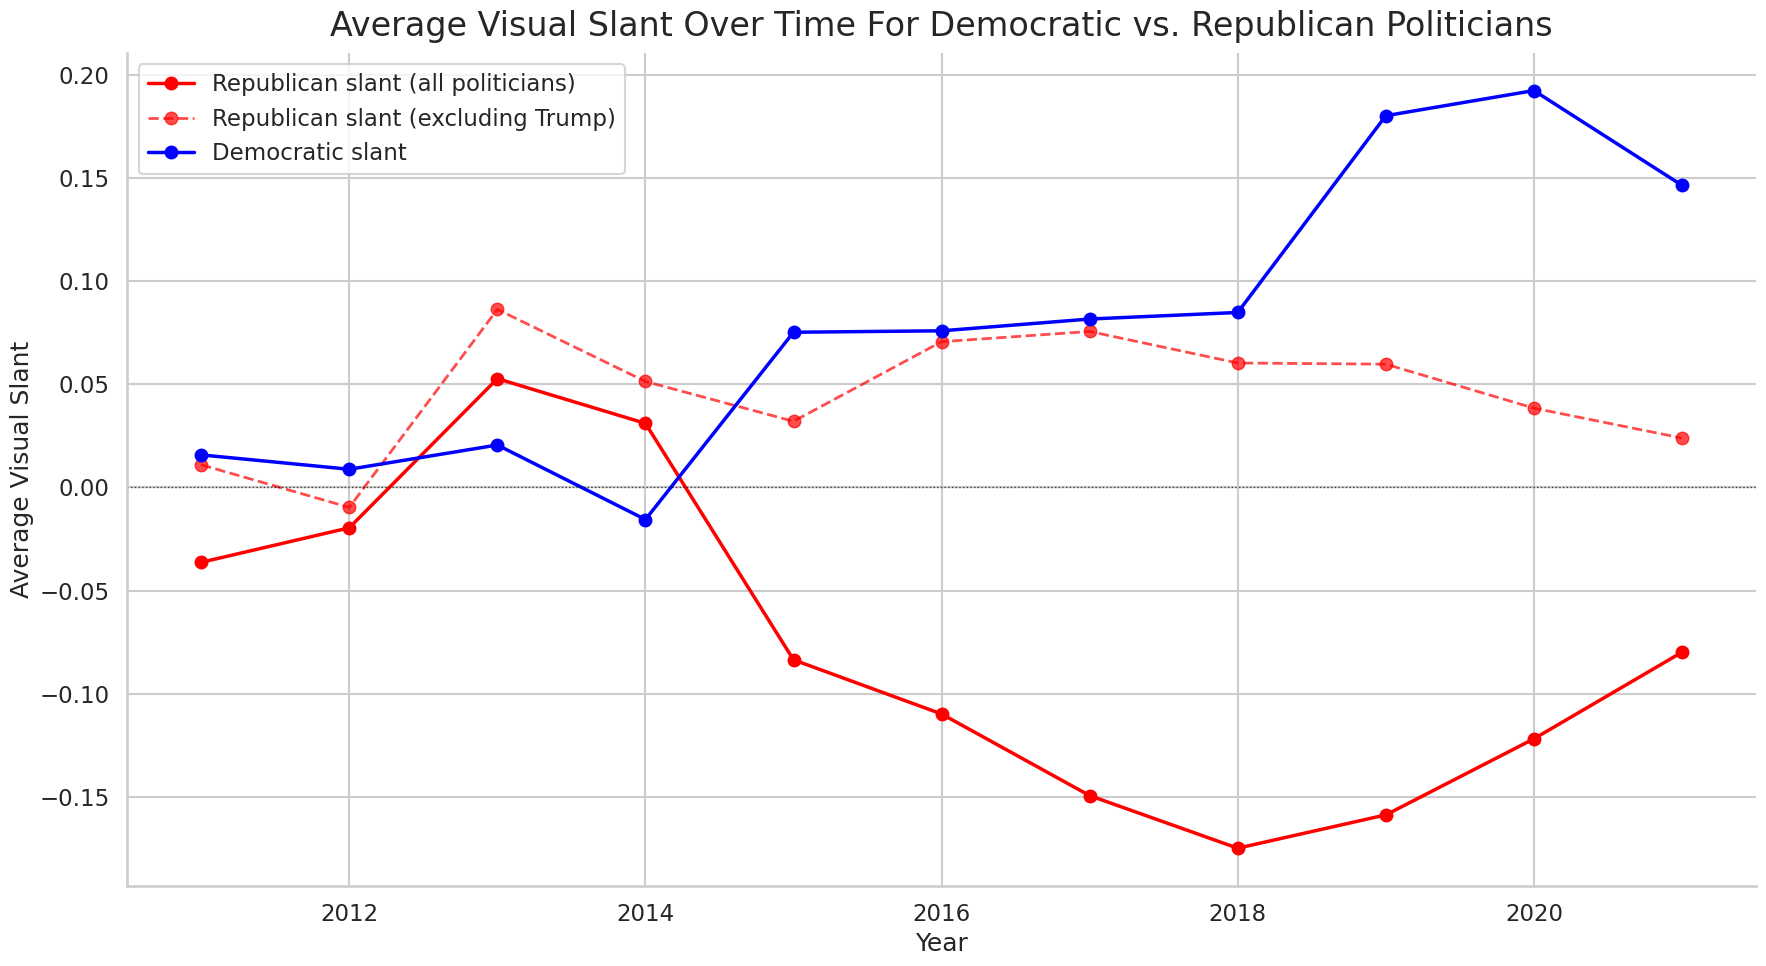

Mean Republican Slant (Pre-Trump): 0.0069
Mean Republican Slant (Trump Era): -0.1330
Difference (Trump - Pre) RED: -0.1399
Mean Democratic Slant (Pre-Trump): 0.0074
Mean Democratic Slant (Trump Era): 0.1149
Difference (Trump - Pre) BLUE: 0.1076


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import spearmanr, pearsonr

def bootstrap_mean_ci(vals, n_boot=1000, alpha=0.05, seed=42):
    vals = np.asarray(vals)
    if len(vals) < 2:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    boots = []
    for _ in range(n_boot):
        sample = rng.choice(vals, size=len(vals), replace=True)
        boots.append(sample.mean())
    boots = np.sort(boots)
    lower = np.percentile(boots, 100 * (alpha / 2))
    upper = np.percentile(boots, 100 * (1 - alpha / 2))
    mean_b = boots.mean()
    return float(mean_b), float(lower), float(upper)

df = pd.read_csv('Final_CSV_For_Analysis.csv').copy()

df = df[df["Real Person Side"].isin(["Republican", "Democratic"])].copy()

YEAR_MIN, YEAR_MAX = 2011, 2021

df["pub_date_parsed"] = pd.to_datetime(df["Date_Pub"], errors="coerce")
df["Year"] = df["pub_date_parsed"].dt.year
df = df[(df["Year"].notna()) & (df["Year"].between(YEAR_MIN, YEAR_MAX))].copy()
df["Year"] = df["Year"].astype(int)

years = sorted(df["Year"].unique())

news_center_affiliations = {
    'www.bbc.com': 'Democratic', 'www.nytimes.com': 'Democratic', 'www.huffpost.com': 'Democratic',
    'www.washingtonpost.com': 'Democratic', 'www.wsj.com': 'Republican', 'www.cnn.com': 'Democratic',
    'www.cbsnews.com': 'Democratic', 'www.latimes.com': 'Neutral', 'www.dailymail.co.uk': 'Republican',
    'abcnews.go.com': 'Democratic', 'www.nbcnews.com': 'Democratic', 'www.foxnews.com': 'Republican',
    'www.newsmax.com': 'Republican', 'www.usnews.com': 'Neutral', 'time.com': 'Democratic',
    'www.reuters.com': 'Neutral', 'news.yahoo.com': 'Neutral', 'www.usatoday.com': 'Neutral',
    'www.cnbc.com': 'Democratic', 'www.csmonitor.com': 'Neutral'
}

selected_news_centers = list(news_center_affiliations.keys())

rows = []

smile_cols = [c for c in df.columns if c.startswith("Final_Ratio_")]

for outlet in selected_news_centers:
    prefix = f"Final_Ratio_{outlet}_"
    candidates = [c for c in smile_cols if c.startswith(prefix)]
    if not candidates:
        continue
    col = candidates[0]
    for year in years:
        sub_year = df[df["Year"] == year]
        sub_r = sub_year[sub_year["Real Person Side"] == 'Republican']
        r_vals = sub_r[col].dropna()
        r_mean = r_vals.mean() if len(r_vals) >= 1 else np.nan
        sub_d = sub_year[sub_year["Real Person Side"] == 'Democratic']
        d_vals = sub_d[col].dropna()
        d_mean = d_vals.mean() if len(d_vals) >= 1 else np.nan
        if len(r_vals) >= 1 and len(d_vals) >= 1:
            rows.append({
                "Year": year,
                "news_center": outlet,
                "Mean_R": r_mean,
                "Mean_D": d_mean,
            })

outlet_year_slants = pd.DataFrame(rows)

rows_no_trump = []

df_no_trump = df[df["Top1_Person"] != "Donald Trump"].copy()

for outlet in selected_news_centers:
    prefix = f"Final_Ratio_{outlet}_"
    candidates = [c for c in smile_cols if c.startswith(prefix)]
    if not candidates:
        continue
    col = candidates[0]
    for year in years:
        sub_year = df_no_trump[df_no_trump["Year"] == year]
        sub_r = sub_year[sub_year["Real Person Side"] == 'Republican']
        r_vals = sub_r[col].dropna()
        if len(r_vals) >= 1:
            rows_no_trump.append({
                "Year": year,
                "news_center": outlet,
                "Mean_R_noTrump": r_vals.mean(),
            })

outlet_year_slants_no_trump = pd.DataFrame(rows_no_trump)

ci_rows = []

for year, sub in outlet_year_slants.groupby("Year"):
    r_vals = sub["Mean_R"].dropna().values
    d_vals = sub["Mean_D"].dropna().values
    r_mean, r_low, r_high = bootstrap_mean_ci(r_vals)
    d_mean, d_low, d_high = bootstrap_mean_ci(d_vals)
    ci_rows.append({
        "Year": year,
        "Mean_R_Slant": r_mean,
        "R_CI_Lower": r_low,
        "R_CI_Upper": r_high,
        "Mean_D_Slant": d_mean,
        "D_CI_Lower": d_low,
        "D_CI_Upper": d_high,
    })

mean_party_slant_trend = pd.DataFrame(ci_rows)

ci_rows_no_trump = []

for year, sub in outlet_year_slants_no_trump.groupby("Year"):
    r_vals = sub["Mean_R_noTrump"].dropna().values
    r_mean_nt, r_low_nt, r_high_nt = bootstrap_mean_ci(r_vals)
    ci_rows_no_trump.append({
        "Year": year,
        "Mean_R_Slant_noTrump": r_mean_nt
    })

no_trump_trend = pd.DataFrame(ci_rows_no_trump)

mean_party_slant_trend = mean_party_slant_trend.merge(
    no_trump_trend, on="Year", how="left"
)

sns.set(style="whitegrid", context="talk")
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

fig, ax1 = plt.subplots(1, 1, figsize=(18, 10))

x = mean_party_slant_trend["Year"].values
y_r = mean_party_slant_trend["Mean_R_Slant"].values
ax1.plot(x, y_r, marker="o", linestyle="-", linewidth=2.5, color="red", label="Republican slant (all politicians)")

if "Mean_R_Slant_noTrump" in mean_party_slant_trend.columns:
    y_r_nt = mean_party_slant_trend["Mean_R_Slant_noTrump"].values
    ax1.plot(x, y_r_nt, marker="o", linestyle="--", linewidth=2, color="red", alpha=0.7,
             label="Republican slant (excluding Trump)")

y_d = mean_party_slant_trend["Mean_D_Slant"].values
ax1.plot(x, y_d, marker="o", linestyle="-", linewidth=2.5, color="blue", label="Democratic slant")

ax1.axhline(0, color="black", linewidth=1, linestyle=":", alpha=0.7)

ax1.set_title("Average Visual Slant Over Time For Democratic vs. Republican Politicians", pad=12, fontsize=24)
ax1.set_xlabel("Year", fontsize=18)
ax1.set_ylabel("Average Visual Slant", fontsize=18)

ax1.legend(frameon=True)
plt.tight_layout()
plt.show()

pre_years = [2011, 2012, 2013, 2014]
trump_years = [2015, 2016, 2017, 2018, 2019, 2020]

pre_data = mean_party_slant_trend[mean_party_slant_trend["Year"].isin(pre_years)]
trump_data = mean_party_slant_trend[mean_party_slant_trend["Year"].isin(trump_years)]

mean_pre_r = pre_data["Mean_R_Slant"].mean()
mean_trump_r = trump_data["Mean_R_Slant"].mean()
mean_pre_d = pre_data["Mean_D_Slant"].mean()
mean_trump_d = trump_data["Mean_D_Slant"].mean()

print(f"Mean Republican Slant (Pre-Trump): {mean_pre_r:.4f}")
print(f"Mean Republican Slant (Trump Era): {mean_trump_r:.4f}")
print(f"Difference (Trump - Pre) RED: {mean_trump_r - mean_pre_r:.4f}")
print(f"Mean Democratic Slant (Pre-Trump): {mean_pre_d:.4f}")
print(f"Mean Democratic Slant (Trump Era): {mean_trump_d:.4f}")
print(f"Difference (Trump - Pre) BLUE: {mean_trump_d - mean_pre_d:.4f}")

## Outlet-Level Visual Slant by Politician (Figures A13, A14, A15)

We examine how **visual slant varies across news outlets for individual politicians**. For each politician, we compute the average outlet-specific visual effect (e.g., the smile-induced change in outlet likelihood) across all associated articles and visualize the resulting outlet-by-politician profiles. This analysis reveals which outlets systematically portray a given politician more favorably or unfavorably, and highlights heterogeneity in visual slant across outlets conditional on the same political figure.

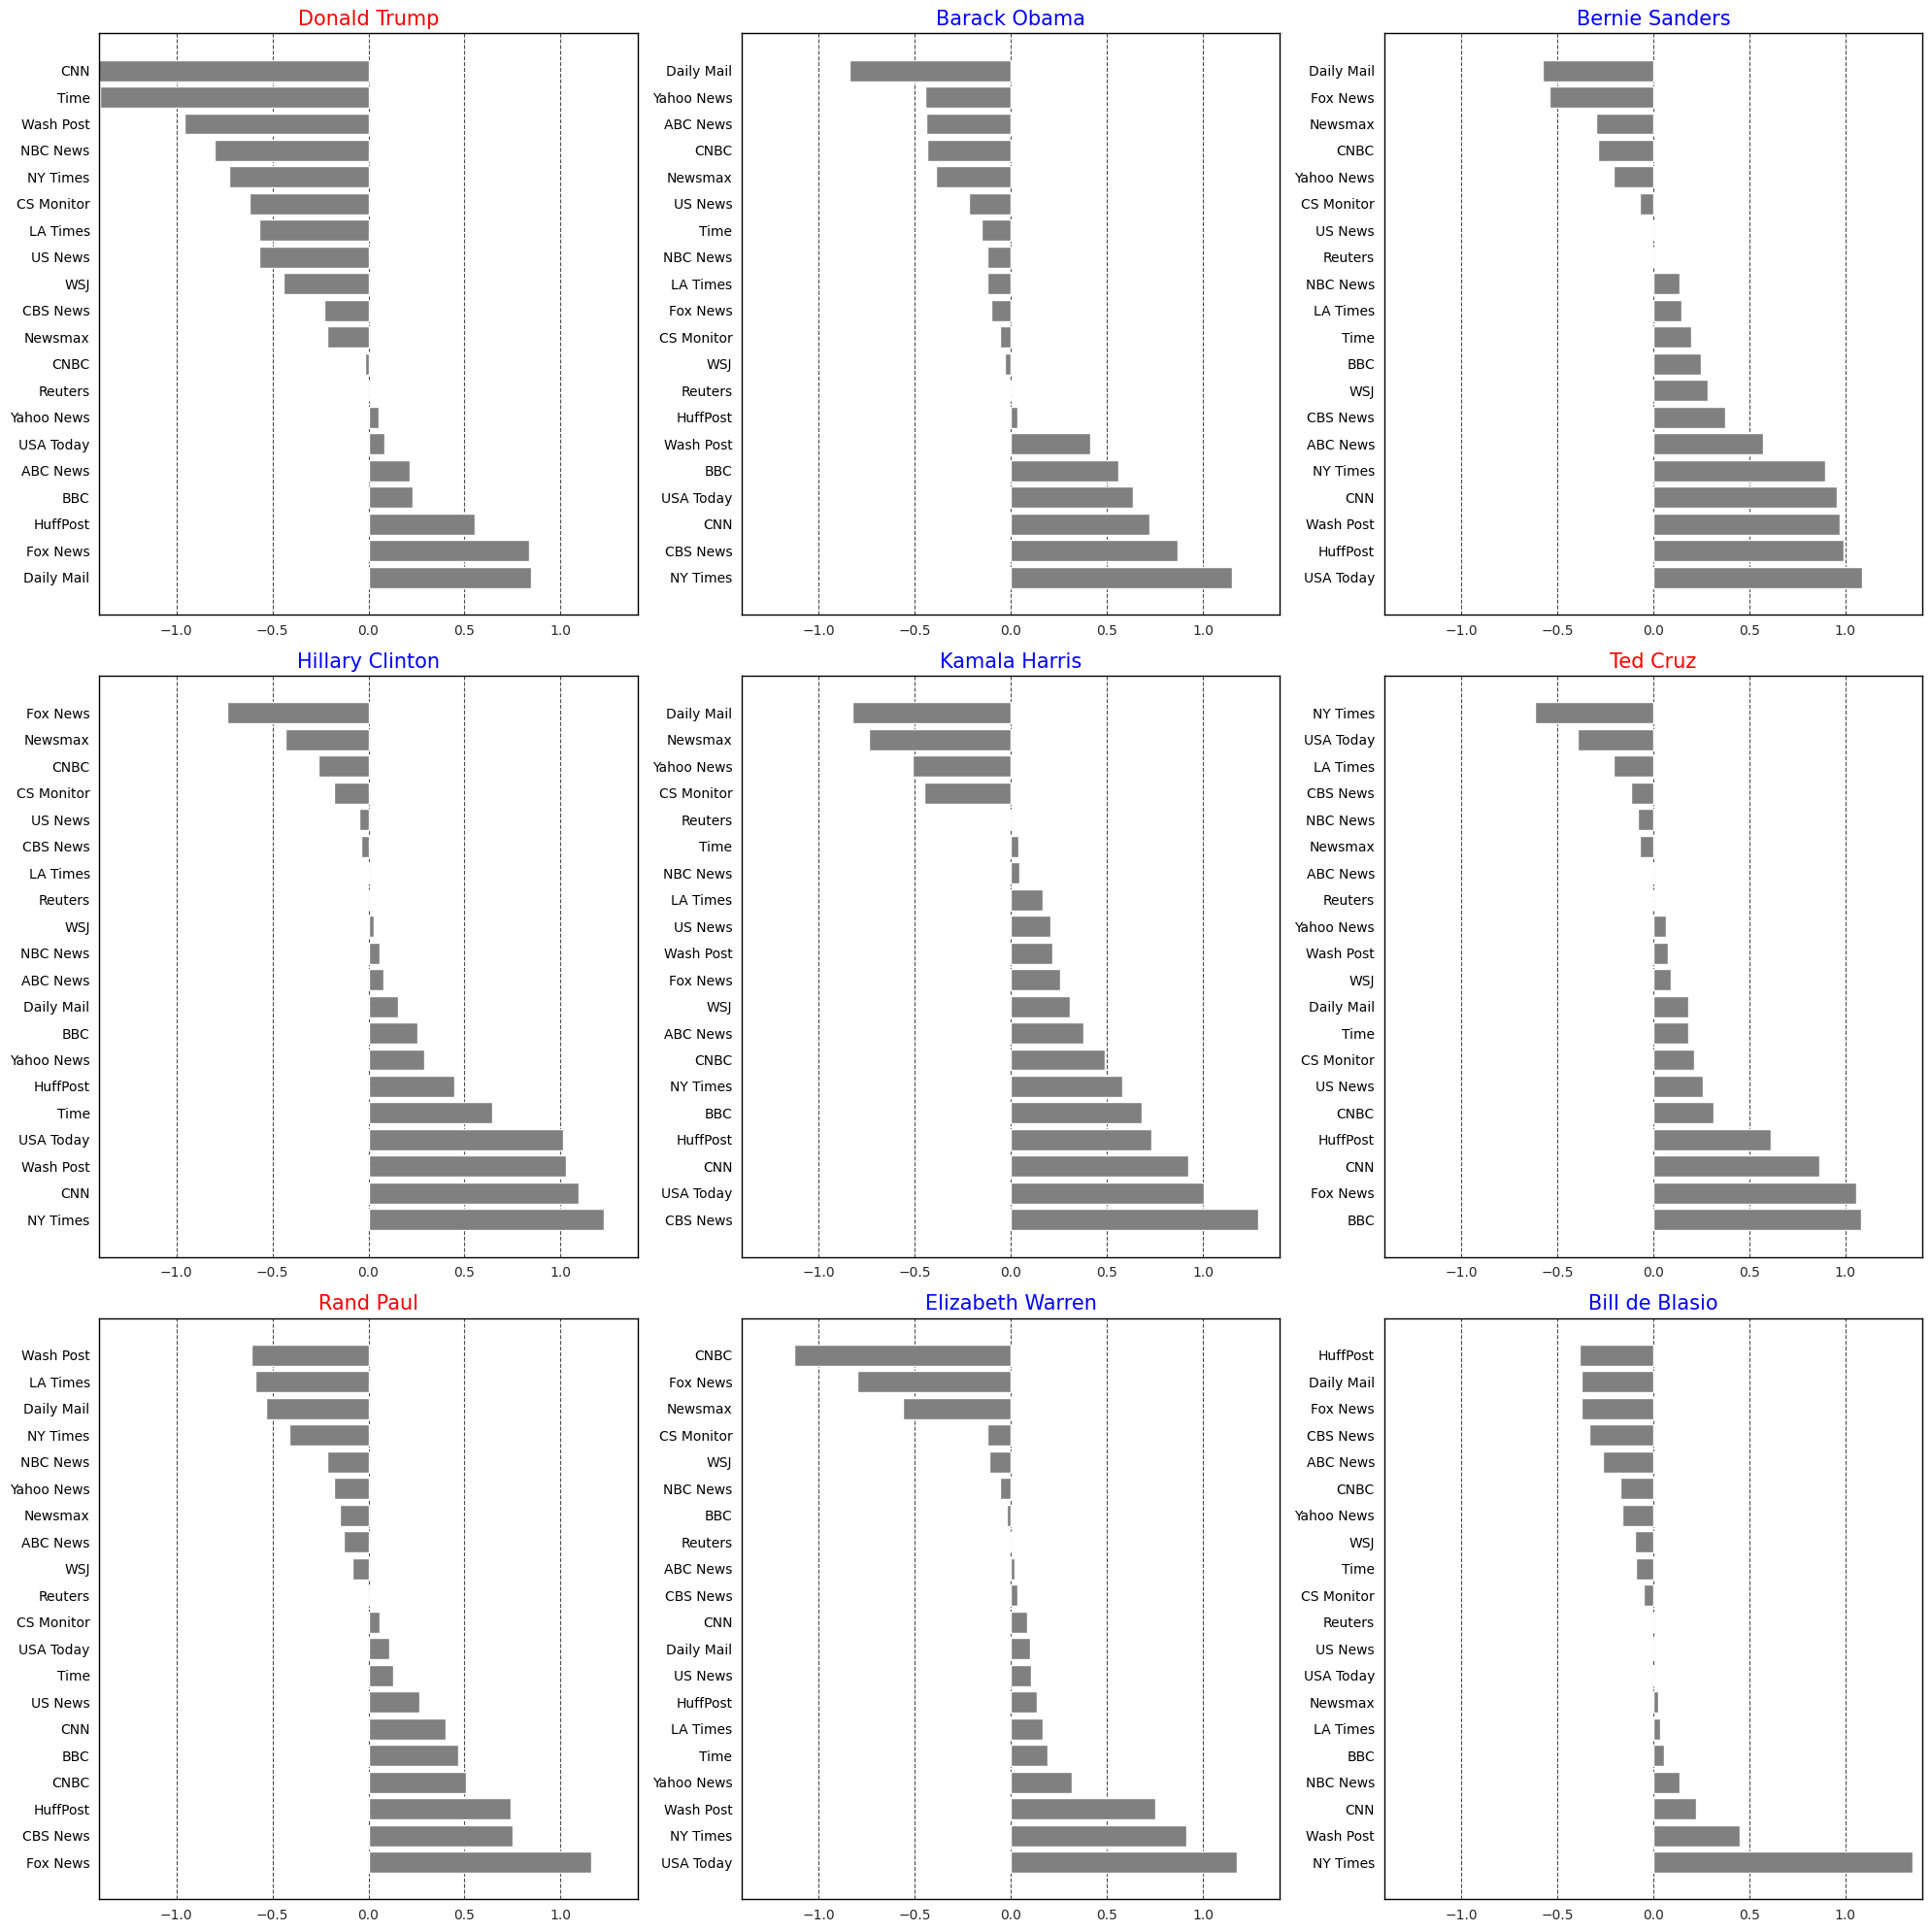

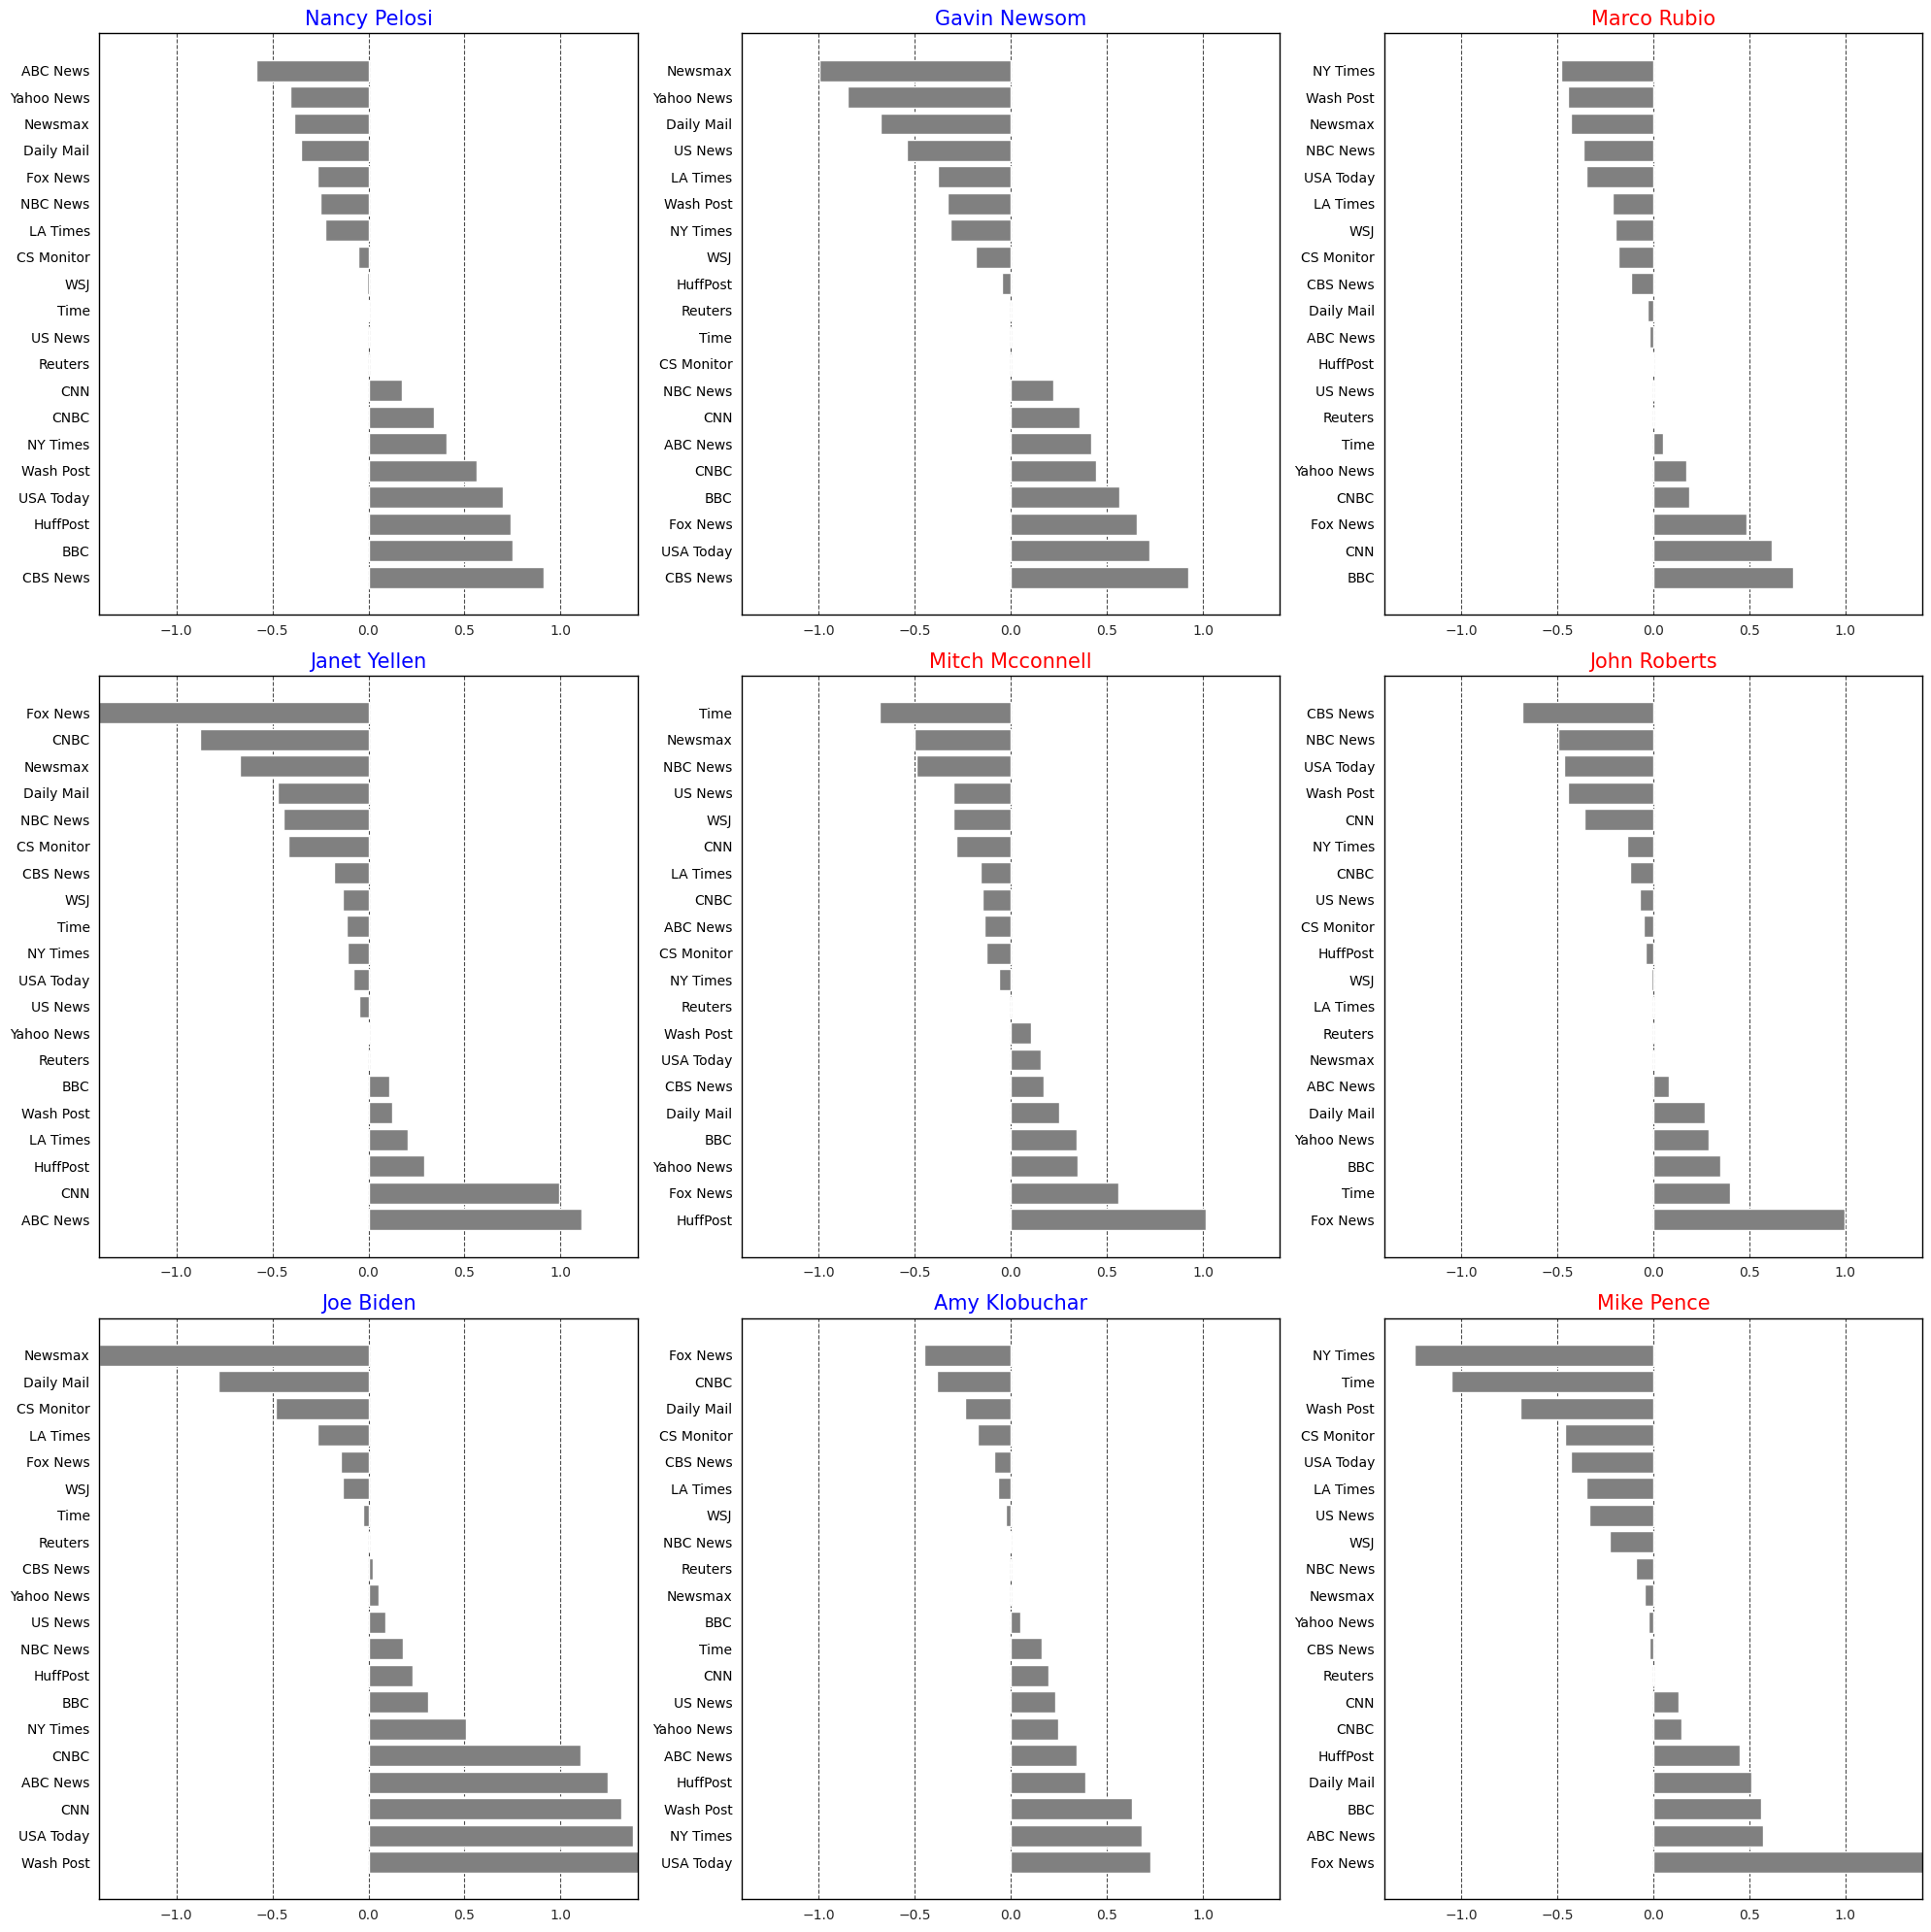

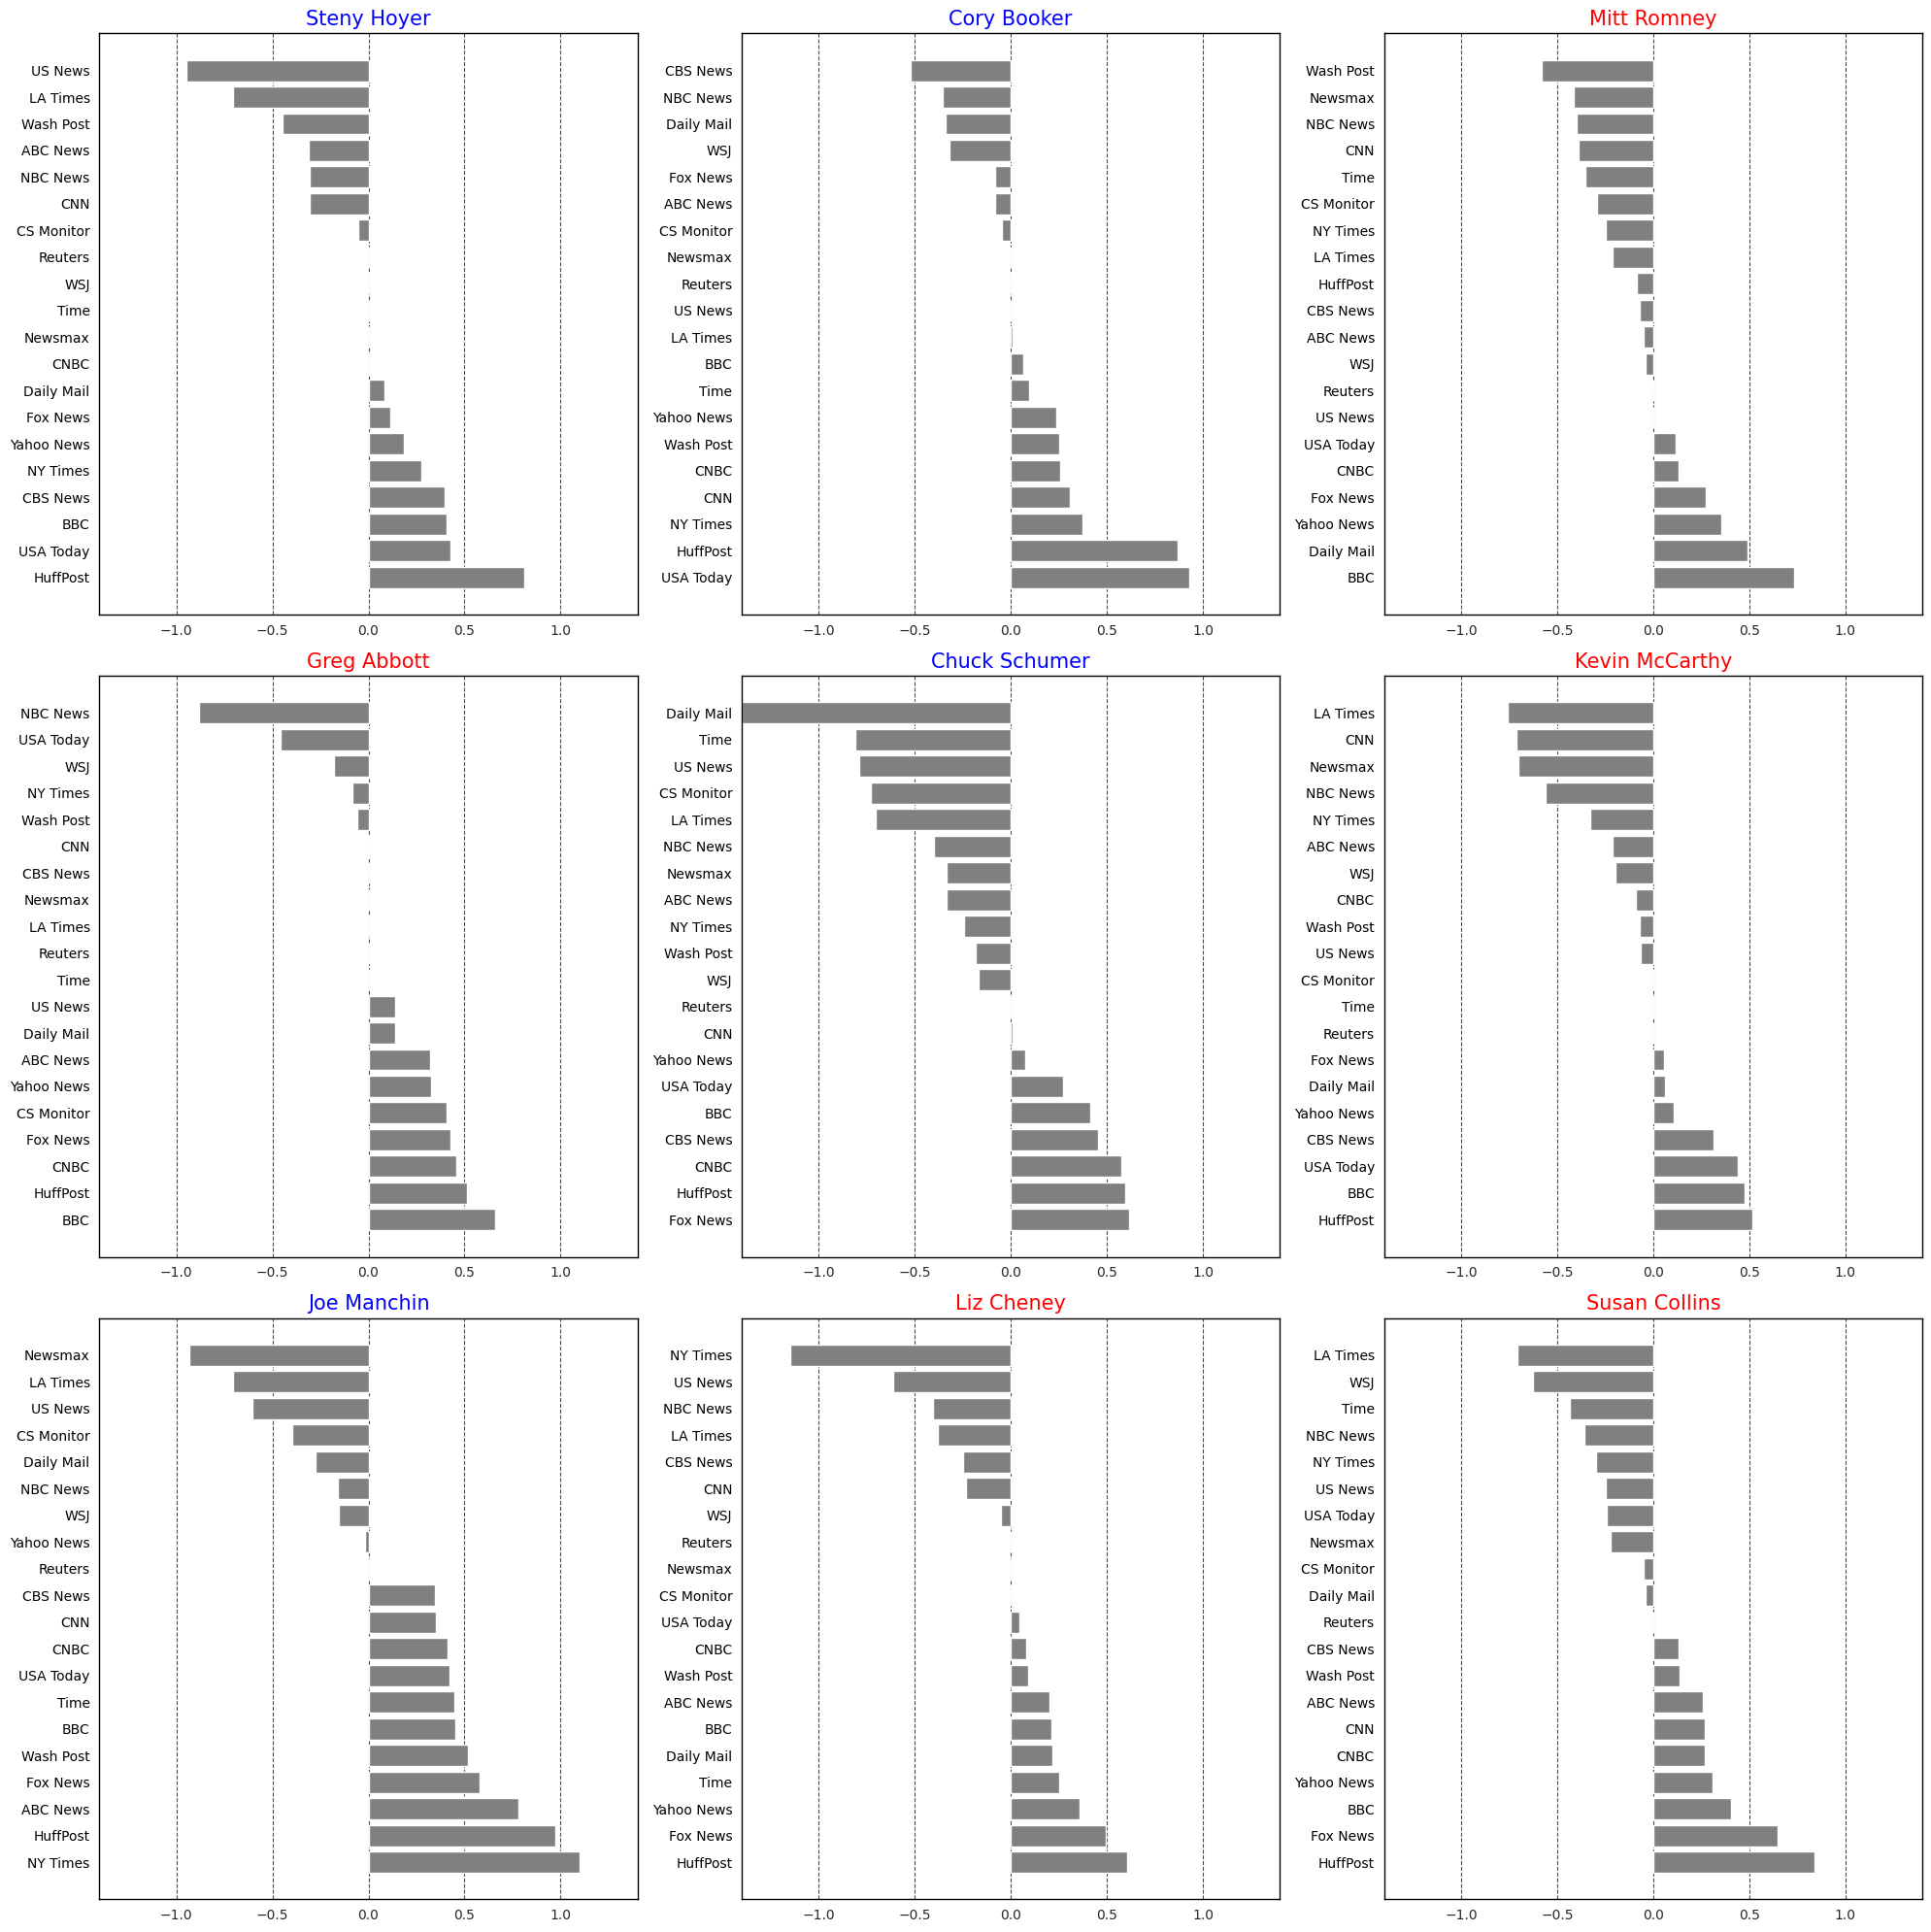

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('Final_CSV_For_Analysis.csv').copy()

news_center_affiliations = {
    'www.bbc.com': 'Democratic', 'www.nytimes.com': 'Democratic', 'www.huffpost.com': 'Democratic',
    'www.washingtonpost.com': 'Democratic', 'www.wsj.com': 'Republican', 'www.cnn.com': 'Democratic',
    'www.cbsnews.com': 'Democratic', 'www.latimes.com': 'Democratic', 'www.dailymail.co.uk': 'Republican',
    'abcnews.go.com': 'Democratic', 'www.nbcnews.com': 'Democratic', 'www.foxnews.com': 'Republican',
    'www.newsmax.com': 'Republican', 'www.usnews.com': 'Neutral', 'time.com': 'Democratic',
    'www.reuters.com': 'Neutral', 'news.yahoo.com': 'Neutral', 'www.usatoday.com': 'Neutral',
    'www.cnbc.com': 'Democratic', 'www.csmonitor.com': 'Neutral'
}

short_names = {
    'www.bbc.com': 'BBC', 'www.nytimes.com': 'NY Times', 'www.huffpost.com': 'HuffPost',
    'www.washingtonpost.com': 'Wash Post', 'www.wsj.com': 'WSJ', 'www.cnn.com': 'CNN',
    'www.cbsnews.com': 'CBS News', 'www.latimes.com': 'LA Times', 'www.dailymail.co.uk': 'Daily Mail',
    'abcnews.go.com': 'ABC News', 'www.nbcnews.com': 'NBC News', 'www.foxnews.com': 'Fox News',
    'www.newsmax.com': 'Newsmax', 'www.usnews.com': 'US News', 'time.com': 'Time',
    'www.reuters.com': 'Reuters', 'news.yahoo.com': 'Yahoo News', 'www.usatoday.com': 'USA Today',
    'www.cnbc.com': 'CNBC', 'www.csmonitor.com': 'CS Monitor'
}

politician_affiliations = {
    'Donald Trump': 'Republican', 'Barack Obama': 'Democratic', 'Bernie Sanders': 'Democratic',
    'Hillary Clinton': 'Democratic', 'Kamala Harris': 'Democratic', 'Ted Cruz': 'Republican',
    'Rand Paul': 'Republican', 'Elizabeth Warren': 'Democratic', 'Bill de Blasio': 'Democratic',
    'Nancy Pelosi': 'Democratic', 'Gavin Newsom': 'Democratic', 'Marco Rubio': 'Republican',
    'Janet Yellen': 'Democratic', 'Mitch Mcconnell': 'Republican', 'John Roberts': 'Republican',
    'Joe Biden': 'Democratic', 'Amy Klobuchar': 'Democratic', 'Mike Pence': 'Republican',
    'Steny Hoyer': 'Democratic', 'Cory Booker': 'Democratic', 'Mitt Romney': 'Republican',
    'Greg Abbott': 'Republican', 'Chuck Schumer': 'Democratic', 'Kevin McCarthy': 'Republican',
    'Joe Manchin': 'Democratic', 'Liz Cheney': 'Republican', 'Susan Collins': 'Republican'
}

selected_news_centers = list(news_center_affiliations.keys())
df = df[df['News Center'].isin(selected_news_centers)]
politicians = list(politician_affiliations.keys())
df = df[df['Top1_Person'].isin(politicians)]

batch_size = 9
num_batches = len(politicians) // batch_size + (1 if len(politicians) % batch_size != 0 else 0)

for batch_num in range(num_batches):
    fig, axs = plt.subplots(3, 3, figsize=(20, 20))
    plt.subplots_adjust(hspace=0.5, wspace=0.3)
    for idx in range(batch_size):
        politician_idx = batch_num * batch_size + idx
        if politician_idx >= len(politicians):
            break
        politician = politicians[politician_idx]
        row = idx // 3
        col = idx % 3
        ax = axs[row, col]
        mean_smile_effect = {'News Center': [], 'Smile Effect': []}
        ax.set_facecolor('white')
        for spine in ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(1)
        person_column = 'Political Person'
        for news_center in selected_news_centers:
            smile_column = f"Final_Ratio_{news_center}"
            if smile_column in df.columns:
                mean_effect = df[(df['News Center'] == news_center) & (df[person_column] == politician)][smile_column].mean()
                mean_smile_effect['News Center'].append(news_center)
                mean_smile_effect['Smile Effect'].append(mean_effect if not np.isnan(mean_effect) else 0)
        politician_mean = np.mean(mean_smile_effect['Smile Effect'])
        mean_smile_effect_df = pd.DataFrame(mean_smile_effect)
        mean_smile_effect_df.sort_values(by='Smile Effect', ascending=False, inplace=True)
        colors = ['gray' if val > 0 else 'gray' for val in mean_smile_effect_df['Smile Effect']]
        labels = [short_names[nc] for nc in mean_smile_effect_df['News Center']]
        ax.barh(labels, mean_smile_effect_df['Smile Effect'], color=colors)
        for tick_label in ax.get_yticklabels():
            news_center = tick_label.get_text()
            affiliation = news_center_affiliations.get(news_center, 'Neutral')
            color = 'blue' if affiliation == 'Democratic' else 'red' if affiliation == 'Republican' else 'black'
            tick_label.set_color(color)
        ax.grid(True, axis='x', linestyle='--', color='black', alpha=0.7)
        ax.set_xlim(-1.4, 1.4)
        title_color = 'red' if politician_affiliations[politician] == 'Republican' else 'blue'
        ax.set_title(f'{politician}', size=15, color=title_color)
    plt.tight_layout()
    #plt.savefig(f'politician_smile_effect_bar_plots_batch_{batch_num + 1}.png', dpi=50)
    plt.show()


### Table A5:

In [17]:
import pandas as pd
import seaborn as sns
from scipy.stats import ks_2samp, ttest_1samp

df = pd.read_csv('Final_CSV_For_Analysis.csv').copy()

news_center_affiliations = {
    'www.bbc.com': 'Neutral', 'www.nytimes.com': 'Democratic', 'www.huffpost.com': 'Democratic',
    'www.washingtonpost.com': 'Democratic', 'www.wsj.com': 'Republican', 'www.cnn.com': 'Democratic',
    'www.cbsnews.com': 'Democratic', 'www.latimes.com': 'Democratic', 'www.dailymail.co.uk': 'Republican',
    'abcnews.go.com': 'Democratic', 'www.nbcnews.com': 'Democratic', 'www.foxnews.com': 'Republican',
    'www.newsmax.com': 'Republican', 'www.usnews.com': 'Neutral', 'time.com': 'Democratic',
    'www.reuters.com': 'Neutral', 'news.yahoo.com': 'Neutral', 'www.usatoday.com': 'Neutral',
    'www.cnbc.com': 'Democratic', 'www.csmonitor.com': 'Neutral'
}

person_affiliations = {
    'Joe Biden': 'Democratic', 'Donald Trump': 'Republican', 'Kamala Harris': 'Democratic', 
    'Mitch Mcconnell': 'Republican', 'Nancy Pelosi': 'Democratic', 'Mike Pence': 'Republican', 
    'Barack Obama': 'Democratic', 'Hillary Clinton': 'Democratic', 'Kevin McCarthy': 'Republican', 
    'Liz Cheney': 'Republican', 'Chuck Schumer': 'Democratic', 'Hal Rogers': 'Republican', 
    'Mitt Romney': 'Republican', 'Elizabeth Warren': 'Democratic', 'John Roberts': 'Republican', 
    'Bernie Sanders': 'Democratic', 'Joe Manchin': 'Democratic', 'Cory Booker': 'Democratic', 
    'Ted Cruz': 'Republican', 'Gavin Newsom': 'Democratic', 'Rand Paul': 'Republican', 
    'Marco Rubio': 'Republican', 'Amy Klobuchar': 'Democratic', 'Susan Collins': 'Republican', 
    'Bill de Blasio': 'Democratic', 'Janet Yellen': 'Democratic', 'Steny Hoyer': 'Democratic', 
    'James Clyburn': 'Democratic', 'Randy Biggs': 'Republican', 'Greg Abbott': 'Republican'
}

selected_news_centers = [news for news, affiliation in news_center_affiliations.items() if affiliation in ['Democratic', 'Republican', 'Neutral']]
df = df[df['News Center'].isin(selected_news_centers)]

results = pd.DataFrame(columns=['News Center', 'Politician Side', 'Mean', 'Q1', 'Q3', 'K-S Statistic', 'K-S P-Value', 'T-Test Statistic', 'T-Test P-Value', 'Significant Difference', 'Support (n)'])

for news_center in selected_news_centers:
    smile_column = f"Final_Ratio_{news_center}"
    
    if smile_column not in df.columns:
        continue
    
    df_news_center = df[df['News Center'] == news_center]
    df_news_center = df

    democratic_politicians = df_news_center[df_news_center['Real Person Side'] == 'Democratic'][smile_column]
    republican_politicians = df_news_center[df_news_center['Real Person Side'] == 'Republican'][smile_column]
    
    if democratic_politicians.empty and republican_politicians.empty:
        continue  

    if not democratic_politicians.empty:
        democratic_mean = democratic_politicians.mean()
        democratic_q1 = democratic_politicians.quantile(0.1)
        democratic_q3 = democratic_politicians.quantile(0.9)
        n_democratic = len(democratic_politicians)
        t_stat, t_p_value = ttest_1samp(democratic_politicians, 0)
        significant_difference = t_p_value < 0.05
        results = pd.concat([results, pd.DataFrame({
            'News Center': [news_center],
            'Politician Side': ['Democratic'],
            'Mean': [democratic_mean],
            'Q1': [democratic_q1],
            'Q3': [democratic_q3],
            'K-S Statistic': [None],
            'K-S P-Value': [None],
            'T-Test Statistic': [t_stat],
            'T-Test P-Value': [t_p_value],
            'Significant Difference': [significant_difference],
            'Support (n)': [n_democratic]
        })], ignore_index=True)
        
    if not republican_politicians.empty:
        republican_mean = republican_politicians.mean()
        republican_q1 = republican_politicians.quantile(0.1)
        republican_q3 = republican_politicians.quantile(0.9)
        n_republican = len(republican_politicians)
        t_stat, t_p_value = ttest_1samp(republican_politicians, 0)
        significant_difference = t_p_value < 0.05
        results = pd.concat([results, pd.DataFrame({
            'News Center': [news_center],
            'Politician Side': ['Republican'],
            'Mean': [republican_mean],
            'Q1': [republican_q1],
            'Q3': [republican_q3],
            'K-S Statistic': [None],
            'K-S P-Value': [None],
            'T-Test Statistic': [t_stat],
            'T-Test P-Value': [t_p_value],
            'Significant Difference': [significant_difference],
            'Support (n)': [n_republican]
        })], ignore_index=True)
        
    if not democratic_politicians.empty and not republican_politicians.empty:
        ks_stat, ks_p_value = ks_2samp(democratic_politicians, republican_politicians)
        results.loc[(results['News Center'] == news_center) & (results['Politician Side'] == 'Democratic'), ['K-S Statistic', 'K-S P-Value']] = [ks_stat, ks_p_value]
        results.loc[(results['News Center'] == news_center) & (results['Politician Side'] == 'Republican'), ['K-S Statistic', 'K-S P-Value']] = [ks_stat, ks_p_value]

results


/tmp/ipykernel_616296/3098620882.py:59: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, pd.DataFrame({


,News Center,Politician Side,Mean,Q1,Q3,K-S Statistic,K-S P-Value,T-Test Statistic,T-Test P-Value,Significant Difference,Support (n)
0,www.bbc.com,Democratic,0.434267,-0.621419,1.457762,0.387738,0.0,56.642501,0.000000e+00,True,5288
1,www.bbc.com,Republican,0.468155,0.207194,1.382746,0.387738,0.0,65.388424,0.000000e+00,True,4163
2,www.nytimes.com,Democratic,0.770167,0.027344,1.312500,0.912254,0.0,93.599491,0.000000e+00,True,5288
3,www.nytimes.com,Republican,-0.766602,-0.998372,-0.183350,0.912254,0.0,-116.809586,0.000000e+00,True,4163
4,www.huffpost.com,Democratic,0.407558,-0.013997,1.565674,0.479995,0.0,54.101553,0.000000e+00,True,5288
5,www.huffpost.com,Republican,0.554629,-0.086829,0.882975,0.479995,0.0,96.849756,0.000000e+00,True,4163
6,www.washingtonpost.com,Democratic,0.929181,0.363220,1.955303,0.900402,0.0,109.627671,0.000000e+00,True,5288
7,www.washingtonpost.com,Republican,-0.726396,-1.080729,0.186523,0.900402,0.0,-102.140176,0.000000e+00,True,4163
8,www.wsj.com,Democratic,0.066387,-0.361979,0.542806,0.557218,0.0,14.517680,7.388369e-47,True,5288
9,www.wsj.com,Republican,-0.354185,-0.625651,0.246745,0.557218,0.0,-70.404723,0.000000e+00,True,4163


### Figure A6:

/home/jupyter-hoc_project/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-hoc_project/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-hoc_project/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-hoc_project/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be

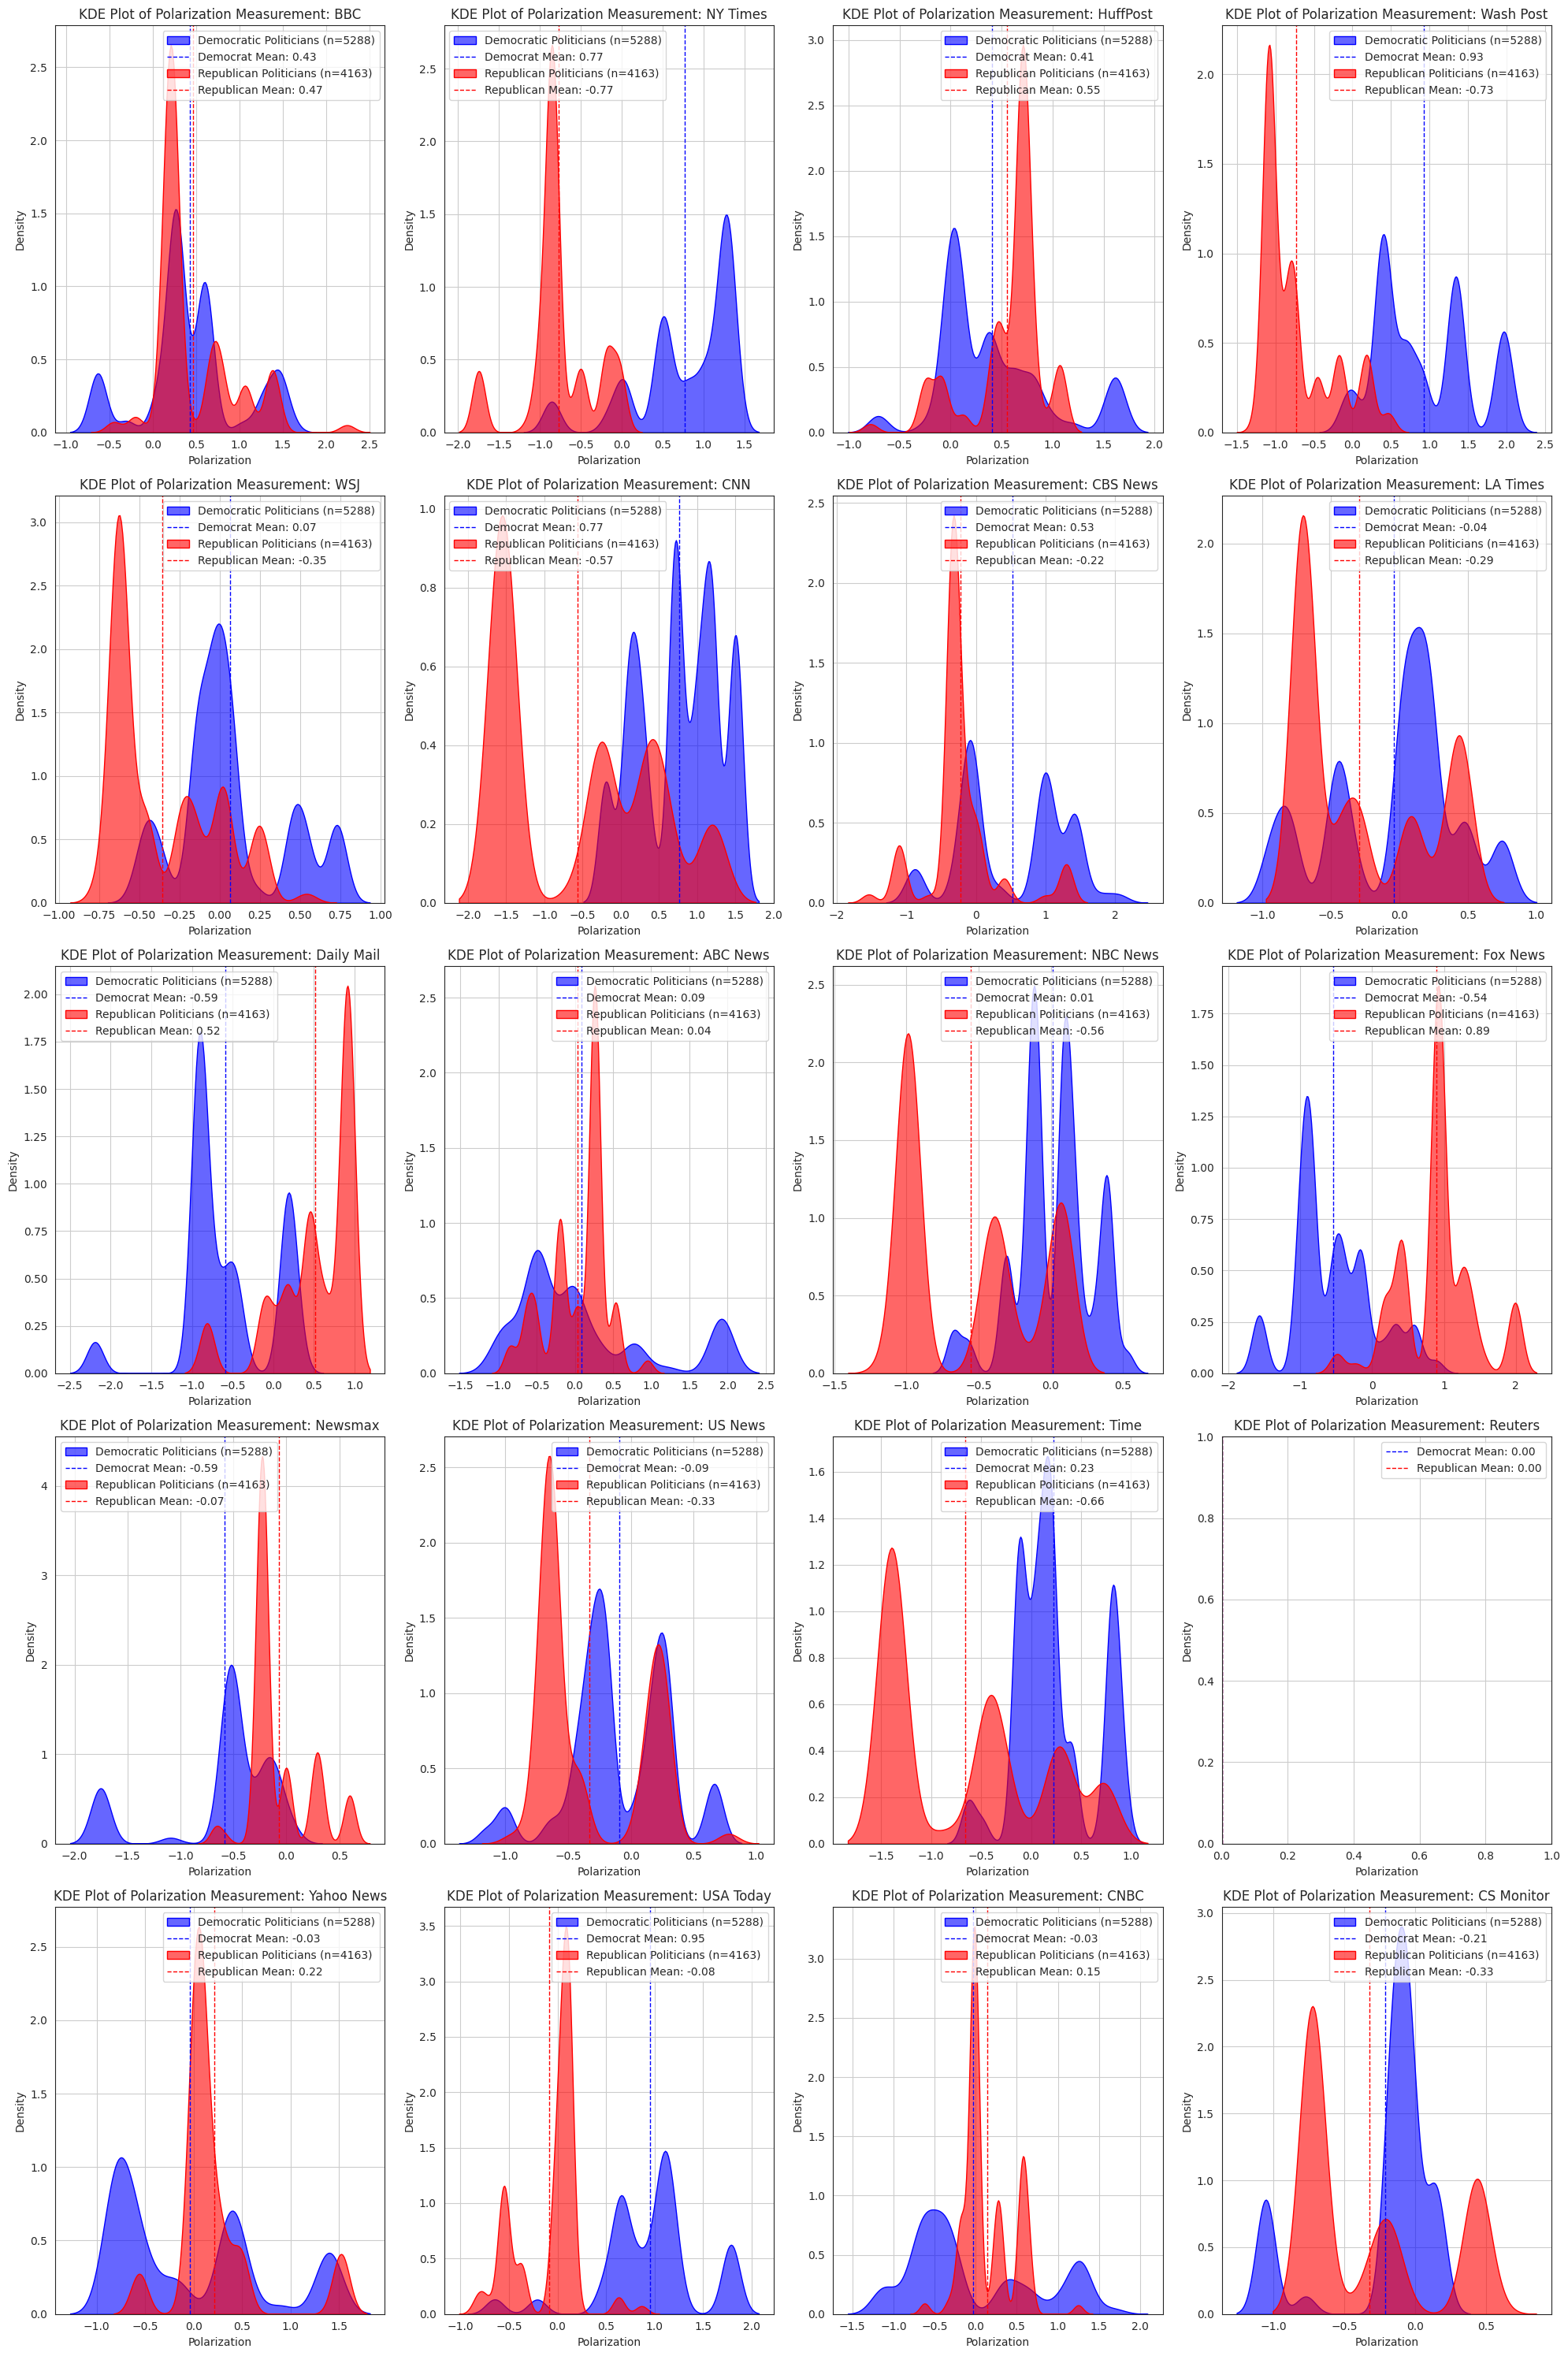

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Final_CSV_For_Analysis.csv').copy()

news_center_affiliations = {
    'www.bbc.com': 'Neutral', 'www.nytimes.com': 'Democratic', 'www.huffpost.com': 'Democratic', 
    'www.washingtonpost.com': 'Democratic', 'www.wsj.com': 'Republican', 'www.cnn.com': 'Democratic', 
    'www.cbsnews.com': 'Democratic', 'www.latimes.com': 'Democratic', 'www.dailymail.co.uk': 'Republican', 
    'abcnews.go.com': 'Democratic', 'www.nbcnews.com': 'Democratic', 'www.foxnews.com': 'Republican', 
    'www.newsmax.com': 'Republican', 'www.usnews.com': 'Neutral', 'time.com': 'Democratic', 
    'www.reuters.com': 'Neutral', 'news.yahoo.com': 'Neutral', 'www.usatoday.com': 'Neutral', 
    'www.cnbc.com': 'Democratic', 'www.csmonitor.com': 'Neutral'
}

short_names = {
    'www.bbc.com': 'BBC', 'www.nytimes.com': 'NY Times', 'www.huffpost.com': 'HuffPost', 
    'www.washingtonpost.com': 'Wash Post', 'www.wsj.com': 'WSJ', 'www.cnn.com': 'CNN', 
    'www.cbsnews.com': 'CBS News', 'www.latimes.com': 'LA Times', 'www.dailymail.co.uk': 'Daily Mail', 
    'abcnews.go.com': 'ABC News', 'www.nbcnews.com': 'NBC News', 'www.foxnews.com': 'Fox News', 
    'www.newsmax.com': 'Newsmax', 'www.usnews.com': 'US News', 'time.com': 'Time', 
    'www.reuters.com': 'Reuters', 'news.yahoo.com': 'Yahoo News', 'www.usatoday.com': 'USA Today', 
    'www.cnbc.com': 'CNBC', 'www.csmonitor.com': 'CS Monitor'
}

person_affiliations = {
    'Joe Biden': 'Democratic', 'Donald Trump': 'Republican', 'Kamala Harris': 'Democratic', 
    'Mitch Mcconnell': 'Republican', 'Nancy Pelosi': 'Democratic', 'Mike Pence': 'Republican', 
    'Barack Obama': 'Democratic', 'Hillary Clinton': 'Democratic', 'Kevin McCarthy': 'Republican', 
    'Liz Cheney': 'Republican', 'Chuck Schumer': 'Democratic', 'Hal Rogers': 'Republican', 
    'Mitt Romney': 'Republican', 'Elizabeth Warren': 'Democratic', 'John Roberts': 'Republican', 
    'Bernie Sanders': 'Democratic', 'Joe Manchin': 'Democratic', 'Cory Booker': 'Democratic', 
    'Ted Cruz': 'Republican', 'Gavin Newsom': 'Democratic', 'Rand Paul': 'Republican', 
    'Marco Rubio': 'Republican', 'Amy Klobuchar': 'Democratic', 'Susan Collins': 'Republican', 
    'Bill de Blasio': 'Democratic', 'Janet Yellen': 'Democratic', 'Steny Hoyer': 'Democratic', 
    'James Clyburn': 'Democratic', 'Randy Biggs': 'Republican', 'Greg Abbott': 'Republican'
}

selected_news_centers = [news for news, affiliation in news_center_affiliations.items() if affiliation in ['Democratic', 'Republican', 'Neutral']]
df = df[df['News Center'].isin(selected_news_centers)]

num_news_centers = len(selected_news_centers)
num_cols = 4
num_rows = (num_news_centers + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, num_rows * 6))
axes = axes.flatten()

for i, news_center in enumerate(selected_news_centers):
    smile_column = f"Final_Ratio_{news_center}"
    if smile_column not in df.columns:
        continue
    
    df_news_center = df[df['News Center'] == news_center]
    df_news_center = df
    
    democratic_politicians = df_news_center[df_news_center['Real Person Side'] == 'Democratic'][smile_column]
    republican_politicians = df_news_center[df_news_center['Real Person Side'] == 'Republican'][smile_column]
    
    if democratic_politicians.empty and republican_politicians.empty:
        continue

    ax = axes[i]
    sns.kdeplot(democratic_politicians, color='blue', label=f'Democratic Politicians (n={len(democratic_politicians)})', fill=True, alpha=0.6, ax=ax)
    
    if not democratic_politicians.empty:
        democratic_mean = democratic_politicians.mean()
        ax.axvline(democratic_mean, color='blue', linestyle='dashed', linewidth=1, label=f'Democrat Mean: {democratic_mean:.2f}')
    
    sns.kdeplot(republican_politicians, color='red', label=f'Republican Politicians (n={len(republican_politicians)})', fill=True, alpha=0.6, ax=ax)
    
    if not republican_politicians.empty:
        republican_mean = republican_politicians.mean()
        ax.axvline(republican_mean, color='red', linestyle='dashed', linewidth=1, label=f'Republican Mean: {republican_mean:.2f}')
    
    ax.set_title(f'KDE Plot of Polarization Measurement: {short_names[news_center]}')
    ax.set_xlabel('Polarization')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
#plt.savefig('histograms_3xN_layout.png', dpi=70)
plt.show()
